In [130]:
import numpy as np
import cmath
import math
import sympy as sp
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import statistics as stat
import scipy.stats as spstat
import statsmodels.distributions.empirical_distribution as empir
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.factorplots import interaction_plot
import statsmodels.api as sma
import matplotlib.lines as mlines

### **1.1 Oefening 1**
Bereken $\frac{\pi}{4}+\frac{\pi}{3}-\frac{\pi}{11}$ in kommagetal (6 cijfers na de komma).
* **Oplossing:** 1.546996

In [131]:
res = math.pi/4 + math.pi/3 - math.pi/11
print(f"oplossing: {res:.4f}")

oplossing: 1.5470


### **1.2 Oefening 2**
Bereken op een efficiënte manier: $1^{2}+2^{2}+\cdot\cdot\cdot+100^{2}$
* **Oplossing:** 338350

In [132]:
res = 0
for i in range (1,101):
    res += i**2
print(res)

338350


### **1.3 Oefening 3**
Bereken som, product en quotiënt van de complexe getallen $z_{1}=3+2j$ en $z_{2}=1-j.$
* **Oplossing:** som: $4+j,$ product: $5-j$ quotiënt: $\frac{1}{2}+\frac{5}{2}j$

In [133]:
z1 = 3 + 2j
z2 = 1-1j
som = z1+z2
product = z1*z2
quotient=z1/z2
print(f"som = {som}, product = {product}, quotiënt = {quotient}")

som = (4+1j), product = (5-1j), quotiënt = (0.5+2.5j)


### **1.4 Oefening 4**
Stel $z=\sqrt{2}e^{3\pi~j/5}$. Bepaal het reëel en imaginair deel. Bepaal (in graden) het argument (=poolhoek) van het complex toegevoegde van $(z+1)$.
* **Oplossing:** 
  * Reëel deel: -0.437016024448821, 
  * imaginair deel: 1.3449970239279148
  * De poolhoek: 67.28696631637692

In [134]:
z= math.sqrt(2)*cmath.exp(3j*math.pi/5)
z1 = (z+1).conjugate()
print(f"reëel deel: {z.real}, imaginair deel: {z.imag}, poolhoek: {math.degrees(cmath.phase(z1))}")

reëel deel: -0.437016024448821, imaginair deel: 1.3449970239279148, poolhoek: -67.28696631637692


### **1.5 Oefening 5**
Voer op de meest handige manier de matrix A in die 18 rijen bevat.
$$A=\begin{pmatrix}1&3&5&7&...&45&47\\ 1&3&5&7&..&45&47\\ 1&3&5&7&...&45&47\\ 1&3&5&7&...&45&47\\ 1&3&5&7&...&45&47\end{pmatrix}.$$

In [135]:
v = np.arange(1,48,2)
A = np.tile(v,(18,1))

print(A)

[[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15

### **1.6 Oefening 6**
Voer op de meest handige manier de matrix B in.
$$B=\begin{pmatrix}1&2&3&4&...&9\\ 1&4&9&16&...&9^{2}\\ 1&8&27&...&...&9^{4}\\ 1&32&...&...&9^{5}\end{pmatrix}$$

In [136]:
v = np.arange(1,10)
machten = np.array([[1],[2],[3],[5]])
print(v**machten)

[[    1     2     3     4     5     6     7     8     9]
 [    1     4     9    16    25    36    49    64    81]
 [    1     8    27    64   125   216   343   512   729]
 [    1    32   243  1024  3125  7776 16807 32768 59049]]


### **1.7 Oefening 7**
Maak een schatting van $\pi$ via een Monte Carlo simulatie, d.w.z. $\frac{\pi}{4}$ waarbij 4 de oppervlakte is van het vierkant $[-1,1]\times[-1,1]$ en p de kans voorstelt dat een willekeurig punt in dit vierkant gelegen is binnen de cirkel met straal 1 en middelpunt (0,0). p is het quotiënt van de oppervlaktes van cirkel en rechthoek en is gelijk aan $\frac{\pi}{4}$
* **Oplossing:** Genereer bijvoorbeeld 1000 willekeurige punten binnen het vierkant. Gebruik een for-lus waarin je telt hoeveel punten binnen de cirkel gelegen zijn. Dan kan $\pi$ geschat worden als dit aantal/1000 maal 4.

In [137]:
aantal_punten = 1000

x=np.random.uniform(-1,1,aantal_punten)
y=np.random.uniform(-1,1,aantal_punten)

punten_binnen_cirkel =np.sum((x**2+y**2) <=1)

pi_schatting = (punten_binnen_cirkel / aantal_punten) *4
print(pi_schatting)

3.156


### **1.8 Oefening 8**
Bereken de oppervlakte van de driehoek met hoekpunten $a(1,2,0),$ $b(3,0,-3)$ en $c(5,2,6)$.
* **Oplossing:** 14

In [138]:
a = np.array([1,2,0])
b= np.array([3,0,-3])
c = np.array([5,2,6])

ab = b-a
ac = c-a

print(1/2*np.linalg.norm(np.cross(ab,ac)))

14.0


### **1.9 Oefening 9**
Bereken het gemiddelde van de elementen uit de verzameling $\{f(0),f(0.1),...,f(1)\}$ met $f(t)=\frac{t}{1+\sqrt{t}}.$ (Werk zonder lussen!)
* **Oplossing:** 0.277209136544736

In [139]:
t = np.linspace(0,1,11)
print(np.mean(t/(1+np.sqrt(t))))


0.277209136544736


### **1.10 Oefening 10**
Een rechthoekige driehoek heeft een omtrek van 5 cm en de lengte van de schuine zijde is $2/3$ van de som van de lengtes van de rechthoekszijden. Wat is de waarde van de zijden van deze driehoek?
* **Oplossing:** geen reële oplossing

In [140]:
a, b ,c = sp.symbols('a b c', real=True, positive=True)

vgl1 = sp.Eq(a+b+c,5)
vgl2=sp.Eq(c,2/3*(a+b))
vgl3=sp.Eq(c**2,a**2+b**2)

opl = sp.solve((vgl1,vgl2,vgl3), (a,b,c))
if not opl:
    print("Er zijn geen reële oplossingen voor deze driehoek.")
else:
    for sol in opl:
        print(f"Oplossing gevonden: a={sol[0]}, b={sol[1]}, c={sol[2]}")

Er zijn geen reële oplossingen voor deze driehoek.


### **1.11 Oefening 11**
Hoeveel van de volgende getallen zijn groter dan 0.5? sin(1), sin(2), sin(3),..., sin (1000)
* **Oplossing:** 332

In [141]:
aantal = 0
for i in range(1,1001):
    if(math.sin(i)>0.5):
        aantal +=1
print(aantal)

332


### **1.12 Oefening 12**
Bouw de faculteitfunctie na met een for-lus (controleer voor 10!) $10!=362880$

In [142]:
faculteit = 1
for i in range(1,11):
    faculteit *=i
print(faculteit)

3628800


### **1.13 Oefening 13**
Bereken $\Sigma_{n=0}^{10}n$! met een beknopt commando op één regel.
* **Oplossing:** 4037914

In [143]:
print(sum(math.factorial(n) for n in range(11)))

4037914


### **1.14 Oefening 14**
Bereken $\tan(2~Bg~\cos(-\frac{1}{5}))$
* **Oplossing:** 0.425998216136205

In [144]:
print(math.tan(2*math.acos(-1/5)))

0.425998216136205


### **1.15 Oefening 15**
Een rechthoekige driehoek heeft een omtrek van 5 cm. Wat is de waarde van de zijden wanneer de driehoek maximale oppervlakte heeft.
* **Oplossing:** $b=1.4645$, oppervlakte $=1.0723$

In [145]:
a, b, c = sp.symbols('a b c', real=True, positive=True)

vgl1 = sp.Eq(c,5-a-b)
vgl2 = sp.Eq(c**2,a**2+b**2)

opl = sp.solve((vgl1,vgl2), (b,c))

b_formule = opl[0][0]
c_formule = opl[0][1]

opp_formule = 0.5 * a * b_formule
opp_func = sp.lambdify(a, -opp_formule, 'numpy')
resultaat = minimize(opp_func, x0=1.0, bounds=[(0.1, 2.4)])

a_opt = resultaat.x[0]
b_opt = float(b_formule.subs(a, a_opt))
c_opt = float(c_formule.subs(a, a_opt))
max_opp = -resultaat.fun

print(f"Zijde b: {b_opt:.4f} cm")
print(f"Maximale oppervlakte: {max_opp:.4f} cm²")

Zijde b: 1.4645 cm
Maximale oppervlakte: 1.0723 cm²


### **1.16 Oefening 16**
Bepaal de snijpunten met de X-as van $\frac{x^{3}-5x^{2}+2x+8}{1+Bgtg(\frac{x}{2})}.$
* **Oplossing:** -1, 2, 4

In [146]:
x = sp.symbols('x')

teller = x**3-5*x**2+2*x+8
noemer = 1 + sp.atan(x/2) # type: ignore

nulpunten = sp.solve(teller, x)

geldige_snijpunten = [punt for punt in nulpunten if noemer.subs(x,punt).evalf() != 0]
print(geldige_snijpunten)


[-1, 2, 4]


### **1.17 Oefening 17**
Los op over IR: $2x^{3}-x^{2}-15x+18>0$
* **Oplossing:** $x\in]-3,\frac{3}{2}[\cup]2,\infty[$

In [147]:
x = sp.symbols('x')
veelterm = 2*x**3 - x**2 - 15*x + 18

oplossing = sp.solve(veelterm > 0, x, domain=sp.S.Reals)

print(f"De ongelijkheid: {veelterm} > 0")
print(f"Oplossingsverzameling in intervalnotatie: {oplossing}")

De ongelijkheid: 2*x**3 - x**2 - 15*x + 18 > 0
Oplossingsverzameling in intervalnotatie: ((-3 < x) & (x < 3/2)) | ((2 < x) & (x < oo))


### **1.18 Oefening 18**
Los op over IR: $x^{5}-5x=-2$.
* **Oplossing:** $x=0.402$ of $x=1.37$ of $x=-1.5820$

In [148]:
x = sp.symbols('x')
f = x**5 - 5*x + 2

roots = sp.solve(sp.Eq(f, 0), x)

reele_nulpunten = [float(r.evalf()) for r in roots if r.is_real]
reele_nulpunten.sort()

print("De reële nulpunten zijn:")
for nulpunt in reele_nulpunten:
    print(f"x = {nulpunt:.4f}")

De reële nulpunten zijn:
x = -1.5820
x = 0.4021
x = 1.3719


### **1.19 Oefening 19**
Bepaal de asymptoten van de kromme met vergelijking $y=\frac{x^{4}+3x^{3}}{8x^{3}+1}$
Maak daarbij gebruik van het commando 'limit' voor symbolische functies.
* **Oplossing:** y $=\frac{1}{8}x+\frac{3}{8}$ is een SA voor $x\rightarrow+\infty,$ $y=\frac{1}{8}x+\frac{3}{8}$ is een SA voor $x\rightarrow-\infty$. Er is een VA bij $x=-\frac{1}{2}.$

In [149]:
x=sp.symbols('x', real=True)
f=(x**4+3*x**3)/(8*x**3+1)

noemer = 8*x**3+1
nulp_noemer = sp.solve(noemer,x)

for nulpunt in nulp_noemer:
    lim_links = sp.limit(f,x,nulpunt,dir='-')
    lim_rechts = sp.limit(f,x,nulpunt,dir='+')

    if abs(lim_links) == sp.oo or abs(lim_rechts) == sp.oo:
        print(f"er is een VA op x = {nulpunt}")

voor_limieten = [(sp.oo, "+oneindig"),(-sp.oo,"-oneindig")]

for limiet_waarde, label in voor_limieten:
    a = sp.limit(f/x,x,limiet_waarde)
    b=sp.limit(f-a*x,x,limiet_waarde)

    if a.is_finite and a !=0 and b.is_finite:
        print(f"voor x -> {label} is de SA: y = {a}*x + {b}")

er is een VA op x = -1/2
voor x -> +oneindig is de SA: y = 1/8*x + 3/8
voor x -> -oneindig is de SA: y = 1/8*x + 3/8


### **1.20 Oefening 20**
Schets de kromme $y=Bgtg(\frac{x-1}{2}-\frac{1}{2x-2})$
Bepaal de limiet in 1 en $in+\infty$.
Bepaal $y^{\prime}$. Zoek punten waarin $y^{\prime}=2$. Verklaar de resultaten op de grafiek
* **Oplossing:** 
  * De linker- en rechterlimiet in $x=1$ streven respectievelijk naar $\frac{\pi}{2}$ en $-\frac{\pi}{2}.$
  * Als x naar + $\infty$ nadert, nadert f(x) naar $\frac{\pi}{2}.$
  * Als x naar - $\infty$ nadert, nadert f(x) naar $-\frac{\pi}{2}.$ 
  * Geen punten waarin $y^{\prime}=2$

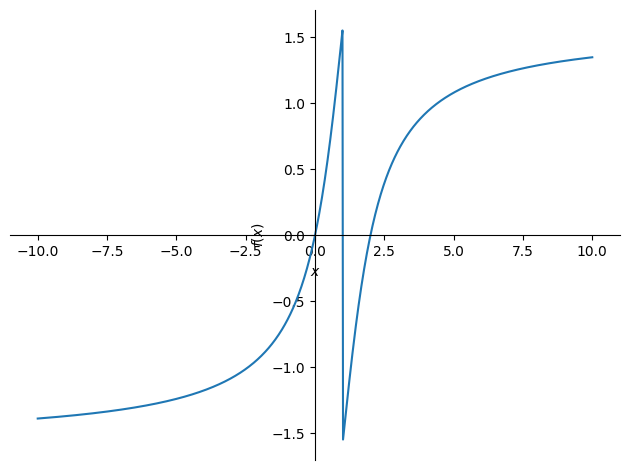

In [150]:
x = sp.symbols('x')
f = sp.atan((x-1)/2-1/(2*x-2))
sp.plotting.plot(f,(x,-10,10))

In [151]:
lim_links = sp.limit(f, x, 1, dir='-')
lim_rechts = sp.limit(f, x, 1, dir='+')

lim_plus_inf = sp.limit(f, x, sp.oo)
lim_min_inf = sp.limit(f, x, -sp.oo)

print(f"Limiet voor x -> +oo: {lim_plus_inf}")
print(f"Limiet voor x -> -oo: {lim_min_inf}")

y_prime = sp.diff(f, x).simplify()
print(f"De afgeleide y' is: {y_prime}")

mogelijke_punten = sp.solve(sp.Eq(y_prime, 2), x)

geldige_punten = []
for punt in mogelijke_punten:
    if (punt - 1) != 0:
        geldige_punten.append(punt)

if not geldige_punten:
    print("Geen geldige punten waarin y' = 2.")
    print(f"(Het enige theoretische punt was x = {mogelijke_punten[0]}, maar dat valt buiten het domein van de functie).")
else:
    print(f"Punten waar y' = 2: {geldige_punten}")

Limiet voor x -> +oo: pi/2
Limiet voor x -> -oo: -pi/2
De afgeleide y' is: 2/(x**2 - 2*x + 2)
Geen geldige punten waarin y' = 2.
(Het enige theoretische punt was x = 1, maar dat valt buiten het domein van de functie).


### **1.21 Oefening 21**
a) Definieer de functie $f(x)=\frac{x^{2}}{3}-4$

b) Bepaal de snijpunten van de kromme $y=f(x)$ met $y=2$

c) Bepaal het punt (x, y) waarin de raaklijn evenwijdig is met de eerste bissectrice

d) Bepaal de oppervlakte van het vlak gebied ingesloten door de X-as, $x=4$ $x=8$ en $y=f(x)$
* **Oplossing:**
  * b) $(-3\sqrt{2},2)$ & $(3\sqrt{2},2)$
  * c) (1.5, -3.25)
  * d) 33.8

In [152]:
# a
x=sp.symbols('x')
f=x**2/3-4

# b
snijp_x = sp.solve(sp.Eq(f,2),x)
snijp = [(val,2) for val in snijp_x]
print(f"De snijpunten zijn: {snijp}")

#c
f_prime = sp.diff(f,x)
x_raakpunt = sp.solve(sp.Eq(f_prime,1),x)[0]
y_raakpunt=f.subs(x,x_raakpunt)
print(f"Het punt is: ({x_raakpunt.evalf()}, {y_raakpunt.evalf()})")

# d
opp = sp.integrate(f,(x,4,8))
print(f"De exacte oppervlakte is: {opp}")
print(f"Numerieke waarde: {opp.evalf():.1f}"

_IncompleteInputError: incomplete input (3135328913.py, line 19)

### **1.22 Oefening 22**
Bereken de oppervlakte van het gebied begrensd door $y=6~x-x^{2}$ en $y=x^{2}-2x$. Maak een tekening.
* **Oplossing:** $64/3$

In [ ]:
x = sp.Symbol('x', real=True)

f = 6*x - x**2
g = x**2 - 2*x

snijpunten = sp.solve(sp.Eq(f, g), x)
snijpunten.sort()
x_links = snijpunten[0]
x_rechts = snijpunten[1]

print(f"De curven snijden elkaar in x = {x_links} en x = {x_rechts}")

oppervlakte = sp.integrate(f - g, (x, x_links, x_rechts))

print(f"De exacte oppervlakte is: {oppervlakte}")

De curven snijden elkaar in x = 0 en x = 4
De exacte oppervlakte is: 64/3


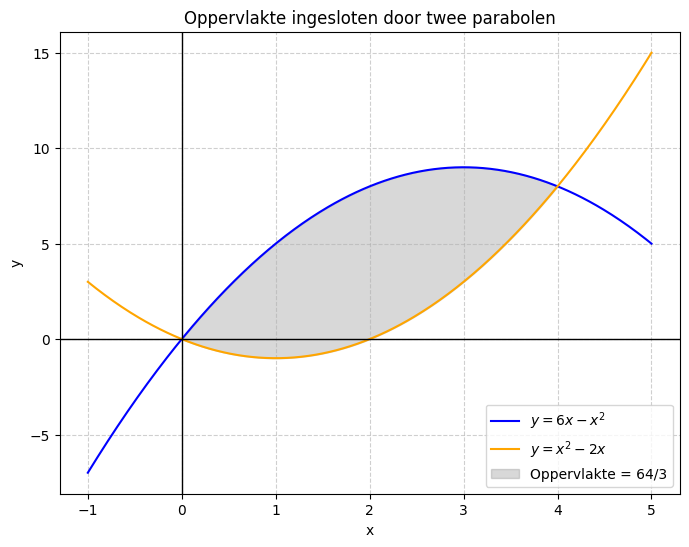

In [ ]:
f_numeriek = sp.lambdify(x, f, 'numpy')
g_numeriek = sp.lambdify(x, g, 'numpy')

x_waarden = np.linspace(float(x_links) - 1, float(x_rechts) + 1, 400)

y_f = f_numeriek(x_waarden)
y_g = g_numeriek(x_waarden)

plt.figure(figsize=(8, 6))
plt.plot(x_waarden, y_f, label='$y = 6x - x^2$', color='blue')
plt.plot(x_waarden, y_g, label='$y = x^2 - 2x$', color='orange')

x_arceer = np.linspace(float(x_links), float(x_rechts), 100)
plt.fill_between(x_arceer, f_numeriek(x_arceer), g_numeriek(x_arceer), 
                 color='grey', alpha=0.3, label='Oppervlakte = 64/3')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.title('Oppervlakte ingesloten door twee parabolen')
plt.xlabel('x')
plt.ylabel('y')

# Toon de plot
plt.show()

### **1.23 Oefening 23**
Schets de krommen $y=\frac{1}{1+x^{2}}$ en $y=\frac{x^{2}}{2}$. Gebruik verschillende kleuren voor de krommen.
Bepaal de snijpunten en bereken de oppervlakte van het gebied ingesloten door beide krommen. Geef daarvoor een analytische en een numerieke waarde. Gebruik daarnaast ook een numerieke integratiemethode en vergelijk de resultaten.
* **Oplossing:** $\pi/2-1/3$. De numerieke waarde 1.237462993462 wordt quasi ook bekomen met de numerieke methode.

[-1, 1, -sqrt(2)*I, sqrt(2)*I]
x1 =  -1
x2 =  1
y1 =  1/2
y2 =  1/2


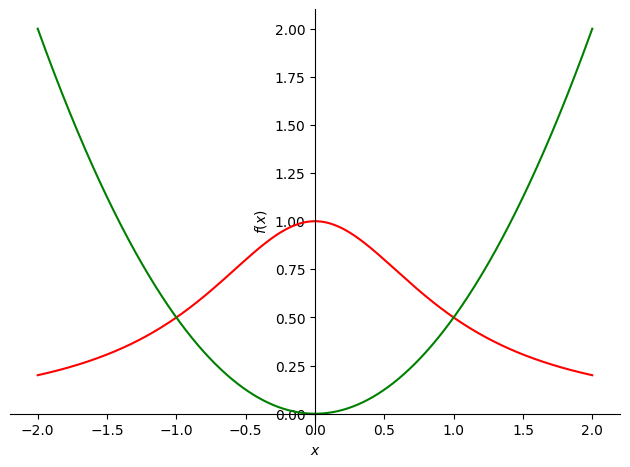

In [ ]:
from sympy.plotting import plot
x = sp.symbols("x")
f1 = 1/(1+x**2)
f2 = (x**2)/2
vgl = sp.Eq(f1-f2,0)
xsnijpunt = sp.solve(vgl,x)
print(xsnijpunt)

x1=xsnijpunt[0]
print("x1 = ",x1)
x2=xsnijpunt[1]
print("x2 = ",x2)
y1=f1.subs(x,x1)
print("y1 = ",y1)
y2=f1.subs(x,x2)
print("y2 = ",y2)

plotf=plot(f1,(x,-2,2), show=False,line_color="r")
plotg=plot(f2,(x,-2,2), show=False,line_color="g")
plotf.extend(plotg)
plotf.show()

### **1.24 Oefening 24**
Bereken het volume van het deel van het cilinderoppervlak $x^{2}+y^{2}=2x$ tussen $z=0$ en $z=4$.
Vergelijk CaCo met CiCo voor dit probleem.
* **Oplossing:** 4 $\pi$

In [ ]:
x, y, z = sp.symbols('x y z', real=True)
r, theta = sp.symbols('r theta', real=True)

int_z = sp.integrate(1, (z, 0, 4))
int_y = sp.integrate(int_z, (y, -sp.sqrt(2*x - x**2), sp.sqrt(2*x - x**2)))
vol_caco = sp.integrate(int_y, (x, 0, 2))

print(f"Volume (CaCo) = {vol_caco}")

int_z_cico = sp.integrate(r, (z, 0, 4))
int_r_cico = sp.integrate(int_z_cico, (r, 0, 2*sp.cos(theta)))
vol_cico = sp.integrate(int_r_cico, (theta, -sp.pi/2, sp.pi/2))

print(f"Volume (CiCo) = {vol_cico}")

Volume (CaCo) = 4*pi
Volume (CiCo) = 4*pi


### **1.25 Oefening 25**
Schets de kromme met parametervoorstelling 

$\begin{cases}x=\frac{1}{t-1}\\ y=1+t^{2}\end{cases}$ 
(gebruik een rode stippellijn voor de asymptoten). 

Bepaal het/de punt(en) met horizontale raaklijn.
* **Oplossing:** (-1, 1)

In [ ]:
t = sp.Symbol('t', real=True)

x_t = 1 / (t - 1)
y_t = 1 + t**2

dy_dt = sp.diff(y_t, t)
dx_dt = sp.diff(x_t, t)

t_horizontaal = sp.solve(sp.Eq(dy_dt, 0), t)

for t_val in t_horizontaal:
    if dx_dt.subs(t, t_val) != 0:
        x_val = x_t.subs(t, t_val)
        y_val = y_t.subs(t, t_val)
        print(f"Horizontale raaklijn in punt: ({x_val}, {y_val}) bij parameter t = {t_val}")

Horizontale raaklijn in punt: (-1, 1) bij parameter t = 0


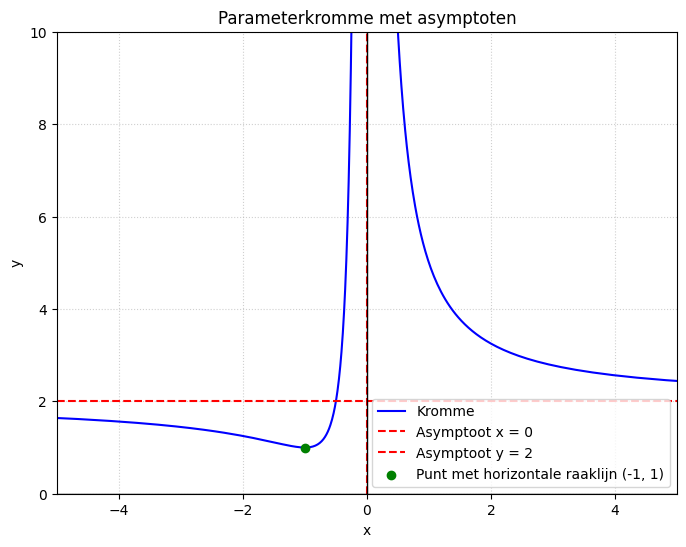

In [ ]:
t_waarden_links = np.linspace(-10, 0.95, 400)
t_waarden_rechts = np.linspace(1.05, 10, 400)

x_num = sp.lambdify(t, x_t, 'numpy')
y_num = sp.lambdify(t, y_t, 'numpy')

plt.figure(figsize=(8, 6))

plt.plot(x_num(t_waarden_links), y_num(t_waarden_links), color='blue', label='Kromme')
plt.plot(x_num(t_waarden_rechts), y_num(t_waarden_rechts), color='blue') 

plt.axvline(0, color='red', linestyle='--', label='Asymptoot x = 0')
plt.axhline(2, color='red', linestyle='--', label='Asymptoot y = 2')

plt.scatter([-1], [1], color='green', zorder=5, label='Punt met horizontale raaklijn (-1, 1)')

plt.xlim(-5, 5)
plt.ylim(0, 10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.legend()
plt.title('Parameterkromme met asymptoten')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

### **1.26 Oefening 26**
Maak een 3D plot en een contourplot van $z=\frac{sin\sqrt{x^{2}+y^{2}}}{\sqrt{x^{2}+y^{2}}},-10\le x\le10,-10\le y\le10.$ 

met de asymptoten $x=0$ en $y=2$.

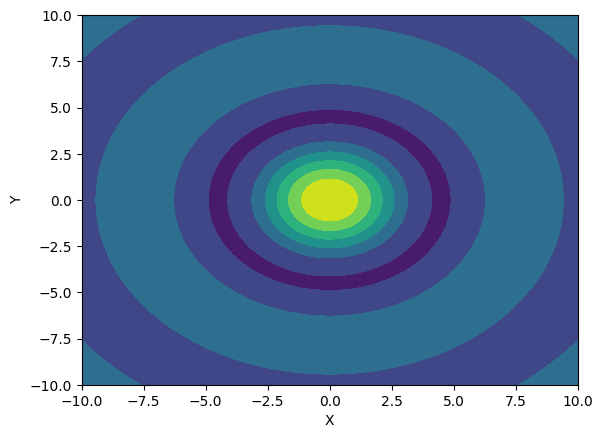

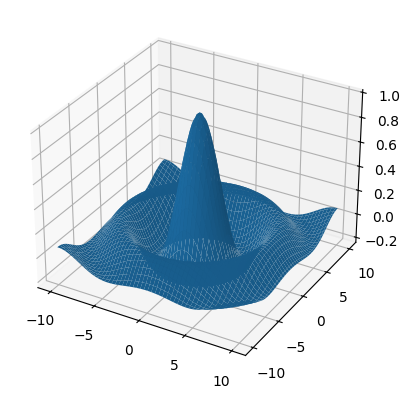

In [ ]:
xwaarden = np.linspace(-10,10,100)
ywaarden = np.linspace(-10,10,100)
[X,Y] = np.meshgrid(xwaarden,ywaarden)
Z = np.sin(np.sqrt(X**2+Y**2))/np.sqrt(X**2+Y**2)

fig1,ax1=plt.subplots()
ax1.contourf(X,Y,Z)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

fig2 = plt.figure()
ax2 = plt.axes(projection = "3d")
ax2.plot_surface(X,Y,Z) # type: ignore

### **1.27 Oefening 27**
Maak een 3D plot en een contourplot van $z=sin(x)+sin(y)$, $-10\le x\le10,$ $-10\le y\le10$.

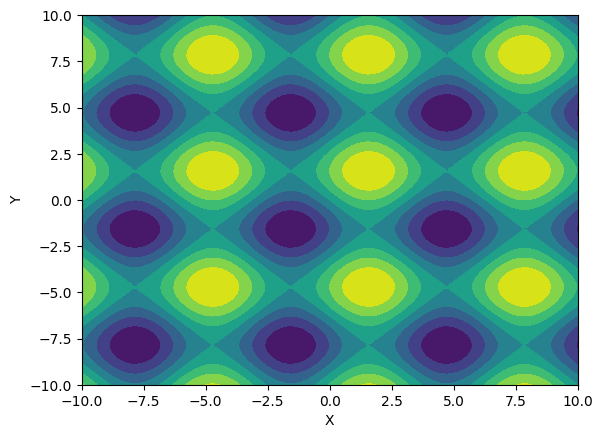

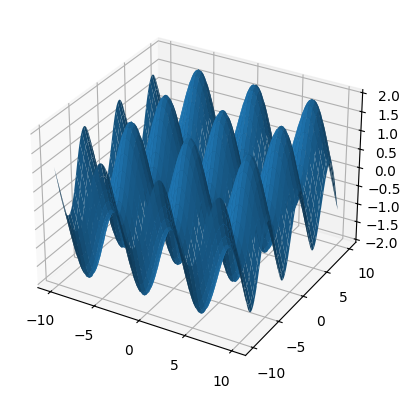

In [ ]:
xwaarden = np.linspace(-10,10,100)
ywaarden = np.linspace(-10,10,100)
[X,Y] = np.meshgrid(xwaarden,ywaarden)
Z = np.sin(X) + np.sin(Y)

fig1,ax1=plt.subplots()
ax1.contourf(X,Y,Z)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

fig2 = plt.figure()
ax2 = plt.axes(projection = "3d")
ax2.plot_surface(X,Y,Z) # type: ignore

### **1.28 Oefening 28**
Teken de parameterkromme bepaald door
$x = \cos(2t)$
$y = \sin(5t)$

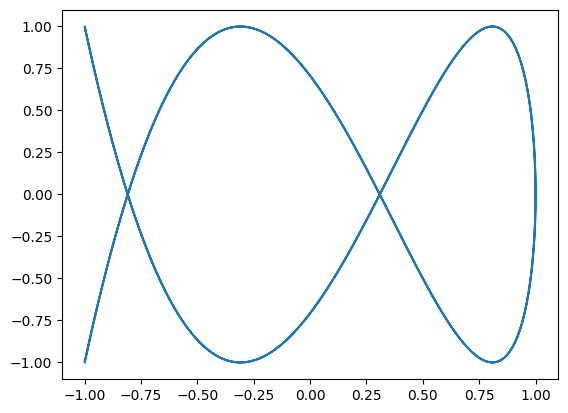

In [ ]:
t=np.linspace(0,2*np.pi,500)
plt.plot(np.cos(2*t),np.sin(5*t))

### **1.29 Oefening 29**
Teken de parameterkromme bepaald door
$x = \cos(5t+\pi/4)$
$y = \sin(4t)$

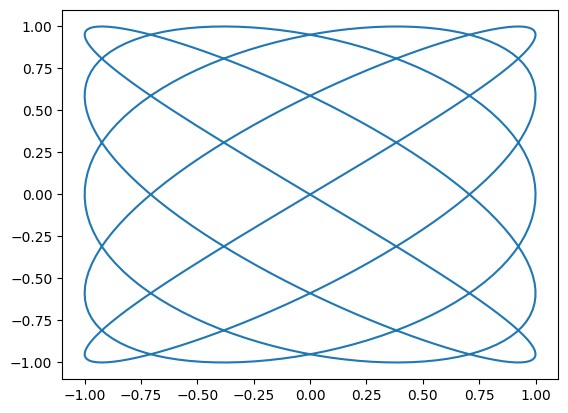

In [ ]:
t=np.linspace(0,2*np.pi,500)
plt.plot(np.cos(5*t+np.pi/4),np.sin(4*t))

### **1.30 Oefening 30**
Teken een kromme in het complexe vlak waarbij $z=t~e^{i~t}$, $0\le t\le4\pi.$

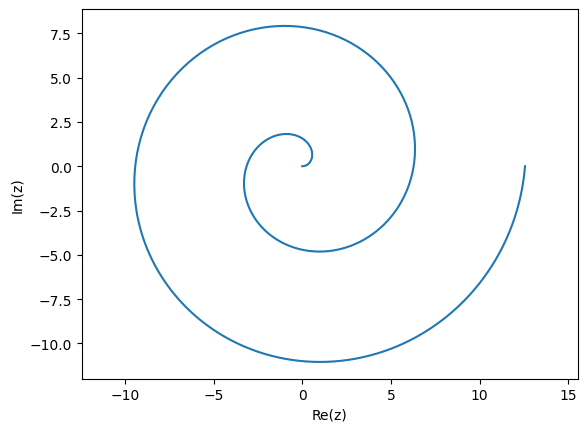

In [ ]:
t=np.linspace(0,4*np.pi,500)
z=t*np.exp(1j*t)

plt.plot(z.real,z.imag)
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.axis("equal")
plt.show()

### **1.31 Oefening 31**
Schets de kromme met vergelijking $(y+1-x).(x^{2}+xy+y^{2}-x)=0.$ Bepaal de snijpunten van de verschillende onderdelen.
* **Oplossing:** $(1/3,-2/3)$ en (1, 0)

De snijpunten van de twee onderdelen zijn: [(1/3, -2/3), (1, 0)]


C:\Users\Talia\AppData\Local\Temp\ipykernel_10616\3293598447.py:19: UserWarning: The following kwargs were not used by contour: 'style'
  plt.contour(X, Y, Z1, levels=[0], colors='blue', style='dashed', linewidths=2)


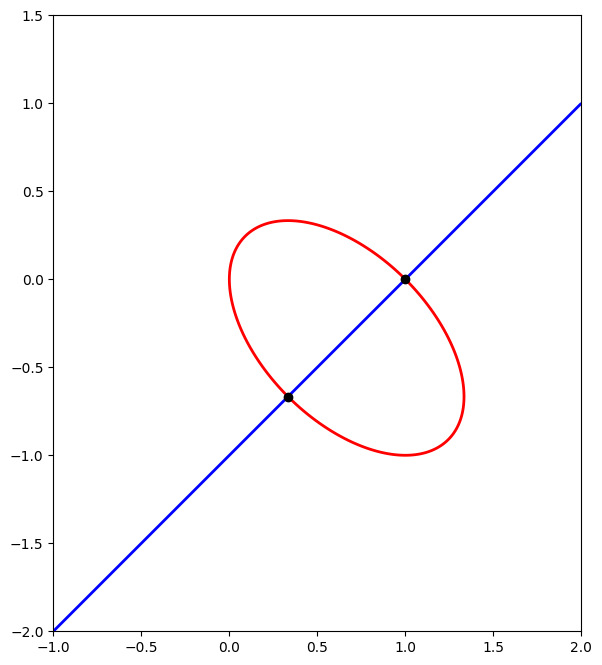

In [ ]:
x, y = sp.symbols('x y', real=True)

factor1 = y + 1 - x
factor2 = x**2 + x*y + y**2 - x

snijpunten = sp.solve([factor1, factor2], (x, y))

print(f"De snijpunten van de twee onderdelen zijn: {snijpunten}")

x_vals = np.linspace(-1, 2, 400)
y_vals = np.linspace(-2, 1.5, 400)
X, Y = np.meshgrid(x_vals, y_vals)

Z1 = Y + 1 - X
Z2 = X**2 + X*Y + Y**2 - X

plt.figure(figsize=(8, 8))

plt.contour(X, Y, Z1, levels=[0], colors='blue', linewidths=2)
plt.contour(X, Y, Z2, levels=[0], colors='red', linewidths=2)

for punt in snijpunten:
    plt.plot(float(punt[0]), float(punt[1]), 'ko', markersize=6, zorder=5)


plt.gca().set_aspect('equal')

plt.show()

### **1.32 Oefening 32**
Bepaal de oplossingen van het stelsel $\begin{cases}x^{2}+5y^{2}=25\\ x+y=2\end{cases}$


Schets de kromme en de rechte op één grafiek. Hoeveel snijpunten zijn er?
* **Oplossing:** twee snijpunten $(-0.234,2.234)=(\frac{5}{3}-\frac{\sqrt{130}}{6},\frac{1}{3}+\frac{\sqrt{130}}{6})$ en $(3.567,-1.567)=(\frac{5}{3}+\frac{\sqrt{130}}{6},\frac{1}{3}-\frac{\sqrt{130}}{6})$

Aantal snijpunten: 2

Snijpunt 1:
  Exact   : (5/3 - sqrt(130)/6, 1/3 + sqrt(130)/6)
  Numeriek: (-0.234, 2.234)

Snijpunt 2:
  Exact   : (5/3 + sqrt(130)/6, 1/3 - sqrt(130)/6)
  Numeriek: (3.567, -1.567)



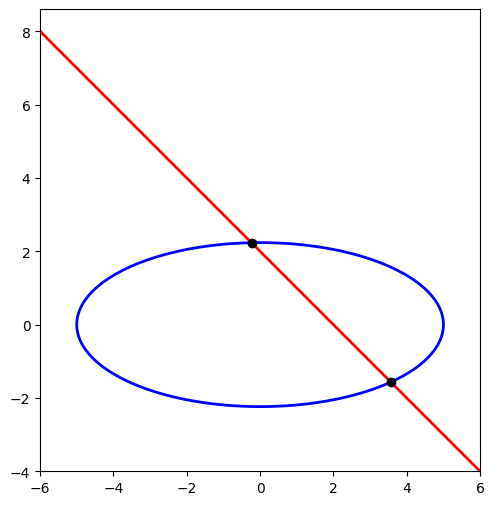

In [ ]:
x, y = sp.symbols('x y', real=True)

eq1 = sp.Eq(x**2 + 5*y**2, 25)
eq2 = sp.Eq(x + y, 2)

snijpunten = sp.solve([eq1, eq2], (x, y))

print(f"Aantal snijpunten: {len(snijpunten)}\n")
for i, punt in enumerate(snijpunten):
    x_exact, y_exact = punt[0], punt[1]
    x_num, y_num = x_exact.evalf(), y_exact.evalf()
    print(f"Snijpunt {i+1}:")
    print(f"  Exact   : ({x_exact}, {y_exact})")
    print(f"  Numeriek: ({x_num:.3f}, {y_num:.3f})\n")

x_vals = np.linspace(-6, 6, 400)
y_vals = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x_vals, y_vals)

Z = X**2 + 5*Y**2 - 25

plt.figure(figsize=(8, 6))

plt.contour(X, Y, Z, levels=[0], colors='blue', linewidths=2)

plt.plot(x_vals, 2 - x_vals, color='red', linewidth=2)

for punt in snijpunten:
    plt.plot(float(punt[0]), float(punt[1]), 'ko', markersize=6, zorder=5)


plt.gca().set_aspect('equal')

plt.show()

### **1.33 Oefening 33**
Bepaal de reële oplossingen van $\begin{cases}x^{2}-2x+y^{2}=0\\ 9x^{2}-18x+4y^{2}=27\end{cases}$

Verklaar grafisch het resultaat.
* **Oplossing:** geen

oplossing: geen.


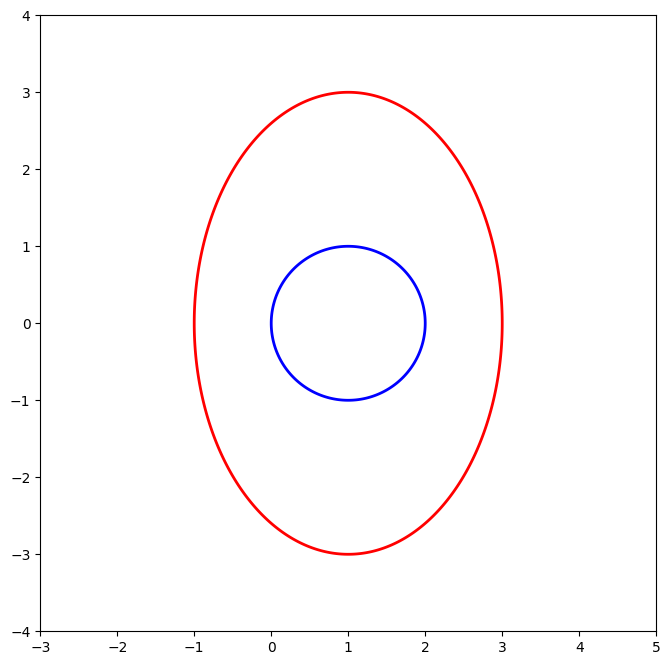

In [ ]:
x, y = sp.symbols('x y', real=True)

eq1 = sp.Eq(x**2 - 2*x + y**2, 0)
eq2 = sp.Eq(9*x**2 - 18*x + 4*y**2, 27)

snijpunten = sp.solve([eq1, eq2], (x, y))

if len(snijpunten) == 0:
    print("oplossing: geen.")
else:
    print(f"De gevonden snijpunten zijn: {snijpunten}")

x_vals = np.linspace(-3, 5, 400)
y_vals = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x_vals, y_vals)

Z1 = X**2 - 2*X + Y**2
Z2 = 9*X**2 - 18*X + 4*Y**2 - 27

plt.figure(figsize=(8, 8))

plt.contour(X, Y, Z1, levels=[0], colors='blue', linewidths=2)
plt.contour(X, Y, Z2, levels=[0], colors='red', linewidths=2)

plt.gca().set_aspect('equal')

plt.show()

### **1.34 Oefening 34**
Teken de astroïde met vergelijking $\begin{cases}x=cos^{3}t\\ y=sin^{3}t\end{cases}$

Bepaal omtrek en oppervlakte.
*(omtrek $=\int_{t_{1}}^{t_{2}}\sqrt{(\frac{dx}{dt})^{2}+(\frac{dy}{dt})^{2}}dt;$ oppervlakte $=\int_{x_{1}}^{x_{2}}|y|dx)$*
* **Oplossing:** omtrek = 6, $opp=\frac{3\pi}{8}$

omtrek:  6.00000000000000
oppervlakte =  3*pi/8


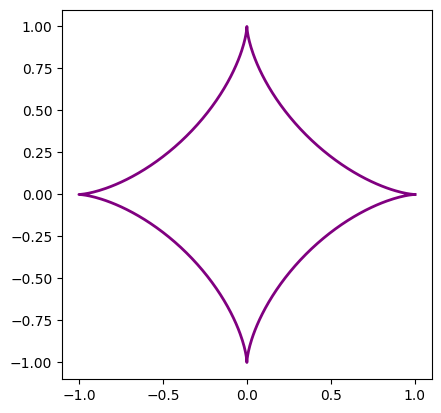

In [ ]:
t = sp.Symbol('t')

x=sp.cos(t)**3
y=sp.sin(t)**3

dx_dt = sp.diff(x,t)
dy_dt = sp.diff(y,t)

integrand_omtrek = sp.sqrt(dx_dt**2+dy_dt**2).simplify()
integrand_kwadrant = 3 * sp.cos(t) * sp.sin(t)
omtrek = 4 * sp.integrate(integrand_omtrek, (t,0,sp.pi/2))
print("omtrek: ", omtrek.evalf())

opp_kwadrant = sp.integrate(y * (-dx_dt), (t,0,sp.pi/2))
opp = 4* opp_kwadrant
print("oppervlakte = ", opp)

t_vals = np.linspace(0,2*np.pi,400)
x_vals = np.cos(t_vals)**3
y_vals = np.sin(t_vals)**3

plt.plot(x_vals, y_vals, color='purple', linewidth=2, label='Astroïde: $\\begin{cases}x=\\cos^3(t)\\\\ y=\\sin^3(t)\\end{cases}$')
plt.gca().set_aspect('equal')
plt.show()

### **1.35 Oefening 35**
Teken de kromme $\begin{cases}x=2~sin(t)+cos(2~t)\\ y=-2~cos(t)-sin(2~t)\end{cases}.$

Bepaal via berekeningen voor welke waarden van de voerstraal van de punten maximaal zal zijn. Bepaal bovendien de cartesische coördinaten van deze punten.
* **Oplossing:** De drie t-waarden waarvoor de voerstraal maximaal is: $-\frac{\pi}{2},\frac{\pi}{6}$ en $\frac{5~\pi}{6}$. Dit leidt tot de punten $(\frac{3}{2},-\frac{3\sqrt{3}}{2})$ , $(\frac{3}{2},\frac{3\sqrt{3}}{2})$, (-3,0).

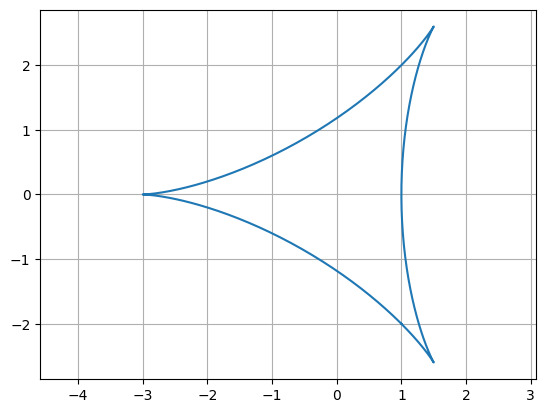

In [ ]:
t = np.linspace(0,2*np.pi,400)
plt.plot(2*np.sin(t)+np.cos(2*t),-2*np.cos(t)-np.sin(2*t))
plt.axis('equal')
plt.grid()

In [ ]:
t = sp.Symbol('t')
x = 2*sp.sin(t) + sp.cos(2*t)
y = -2*sp.cos(t) - sp.sin(2*t)
r = sp.sqrt(x**2+y**2)
afg = sp.diff(r,t)
vgl = sp.Eq(afg,0)
t_opl=sp.solveset(vgl,t,domain=sp.Interval(0,2*sp.pi))
print('t_opl = ',t_opl)

r_waarden = [r.subs(t,waarde) for waarde in t_opl]
print("De bijhorende r-waarden zijn: ", r_waarden)
x_waarden = [x.subs(t,waarde) for waarde in t_opl]
print("de daarbijhorende x-waarden zijn: ",x_waarden)
y_waarden = [y.subs(t,waarde) for waarde in t_opl]
print("de bijhorende y-waarden zijn: ",y_waarden)

t_opl =  {pi/6, pi/2, 5*pi/6, 7*pi/6, 3*pi/2, 11*pi/6}
De bijhorende r-waarden zijn:  [3, 1, 3, 1, 3, 1]
de daarbijhorende x-waarden zijn:  [3/2, 1, 3/2, -1/2, -3, -1/2]
de bijhorende y-waarden zijn:  [-3*sqrt(3)/2, 0, 3*sqrt(3)/2, sqrt(3)/2, 0, -sqrt(3)/2]


### **1.36 Oefening 36**
a) Teken de cardioide $r=1+cos~\theta$

b) Bereken de oppervlakte.

c) Bereken de omtrek.

* **TIP:** Oppervlakte in poolcoördinaten $S=\frac{1}{2}\int_{S_{t}}^{S_{2}}r^{2}d\mathcal{\theta}$, Booglengte in poolcoördinaten $s=\int_{\vec{Q}_{2}}\sqrt{r^{2}+{r^{\prime2}}^{2}}d\mathcal{\Theta}.$
* **Oplossing:** $opp=\frac{3\pi}{2}$, omtrek = 8

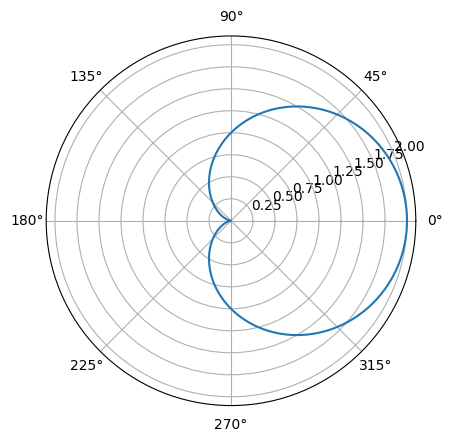

In [ ]:
theta = np.linspace(0,2*np.pi,400)
r = 1 + np.cos(theta)
plt.polar(theta, r)
plt.show()

In [ ]:
theta = sp.Symbol('theta')
r = 1+sp.cos(theta)
r_prime = sp.diff(r,theta)

# b
integrand_opp = (1/2) * r**2
opp = sp.integrate(integrand_opp, (theta,0,2*sp.pi))
print("oppervlakte = ",opp)

# c
integrand_omtrek = sp.sqrt(r**2 + r_prime**2).simplify()
omtrek = 2* sp.integrate(integrand_omtrek, (theta,0,sp.pi))
print("omtrek = ", omtrek.evalf())

oppervlakte =  1.5*pi
omtrek =  8.00000000000000


### **1.37 Oefening 37**
Teken een cirkel met middelpunt (1,2) en straal 2 via de parametervoorstelling en de expliciete voorstelling.

1. Parametervoorstelling: Een cirkel met middelpunt $(x_c, y_c)$ en straal $r$ wordt beschreven door:

    $\begin{cases}x = x_c + r\cos(t) \\ y = y_c + r\sin(t)\end{cases}$ met $t \in [0, 2\pi]$.

    Voor deze oefening is dat $x = 1 + 2\cos(t)$ en $y = 2 + 2\sin(t)$.

2. Expliciete voorstelling: Dit vertrekt van de cartesische vergelijking $(x - x_c)^2 + (y - y_c)^2 = r^2$.

    Voor deze cirkel: $(x - 1)^2 + (y - 2)^2 = 4$.
    
    Om dit expliciet te maken (als $y = f(x)$), moeten we de vergelijking omvormen naar $y$. 
    
    Omdat het een cirkel is, krijgen we een positieve en een negatieve wortel (de bovenste en de onderste helft van de cirkel):
    
    $y = 2 \pm \sqrt{4 - (x - 1)^2}$
    
    Het domein voor $x$ loopt hierbij van $x_c - r$ tot $x_c + r$, dus van $-1$ tot $3$.

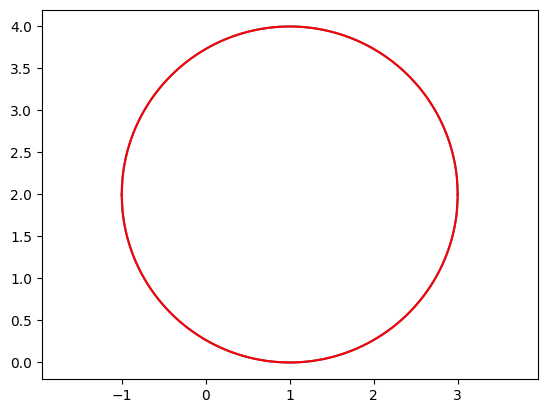

In [ ]:
t = np.linspace(0,2*np.pi,400)
x_p = 1 + 2 * np.cos(t)
y_p = 2 + 2 * np.sin(t)

x_ex = np.linspace(-1,3,400)
y_ex_boven = 2 + np.sqrt(4-(x_ex-1)**2)
y_ex_onder = 2 - np.sqrt(4-(x_ex-1)**2)

plt.plot(x_p, y_p) # parametervoorstelling

plt.plot(x_ex, y_ex_boven, 'r') # boven
plt.plot(x_ex, y_ex_onder, 'r') # onder

plt.axis('equal')
plt.show()

### **1.38 Oefening 38**
Onderzoek wat er gebeurt met de helling van de kromme $y=\frac{|x+2|}{(x+1)^{2}}$ rond $x=-2.$ Werk met limieten en controleer via een tekening.
* **Oplossing:** $LL=-1$, $RL=1$

LL = -1   RL = 1


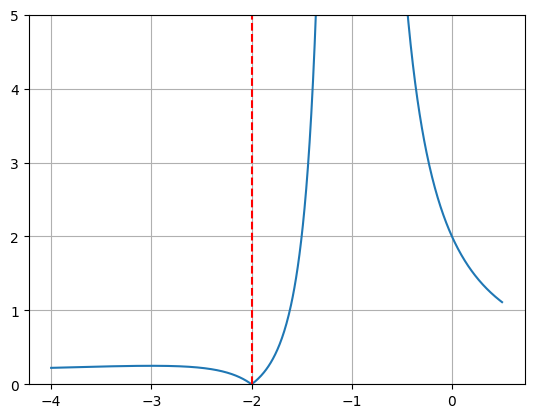

In [ ]:
x = sp.symbols('x')
y_rechts = (x + 2)/(x + 1)**2
y_links  = -(x + 2)/(x + 1)**2

RL = sp.limit(sp.diff(y_rechts, x), x, -2)   # rechterlimiet
LL = sp.limit(sp.diff(y_links,  x), x, -2)   # linkerlimiet
print("LL =", LL, "  RL =", RL)

xv = np.linspace(-4, 0.5, 800)
xv = xv[np.abs(xv + 1) > 1e-2] # x = -1 niet in domein
plt.plot(xv, np.abs(xv+2)/(xv+1)**2)
plt.axvline(-2, color='r', ls='--')
plt.ylim(0, 5)
plt.grid(True)
plt.show()

### **1.39 Oefening 39**
a) Teken op één grafiek de krommen met vergelijking $r=1$ en $r=2~cos(3\theta)$.

b) Bereken de oppervlakte van het gemeenschappelijk deel binnen $r=1$ en $r=2~cos(3\theta)$.
* **Oplossing:** $\frac{2\pi}{3}-\frac{\sqrt{3}}{2}$

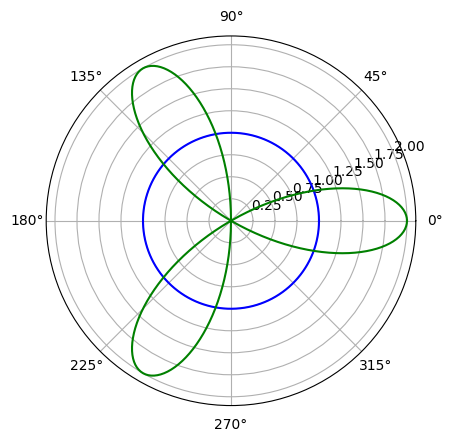

In [ ]:
theta=np.linspace(0,2*np.pi,400)
r1=np.ones(400)
plt.polar(theta,r1,'b')
r2=np.maximum(0,2*np.cos(3*theta))
plt.polar(theta,r2,'g')

In [ ]:
t=sp.symbols('t')
vgl1=sp.Eq(2*sp.cos(3*t),1)
opl1=sp.solve(vgl1,t)
print("opl1 = ",opl1)
vgl2=sp.Eq(2*sp.cos(3*t),0)
opl2=sp.solve(vgl2,t)
print("opl2 = ",opl2)

theta1=opl1[0]
theta2=opl2[0]

A1=sp.integrate(1**2,(t,0,theta1))/2
A2=sp.integrate((2*sp.cos(3*t))**2,(t,theta1,theta2))/2
A0=A1+A2
A=6*A0
print("de oppervlakte van gebied G: ",A)

opl1 =  [pi/9, 5*pi/9]
opl2 =  [pi/6, pi/2]
de oppervlakte van gebied G:  -sqrt(3)/2 + 2*pi/3


### **1.40 Oefening 40**
Teken de kromme met poolcoördinatenvergelijking $r=Bg~cos(\theta+1)$

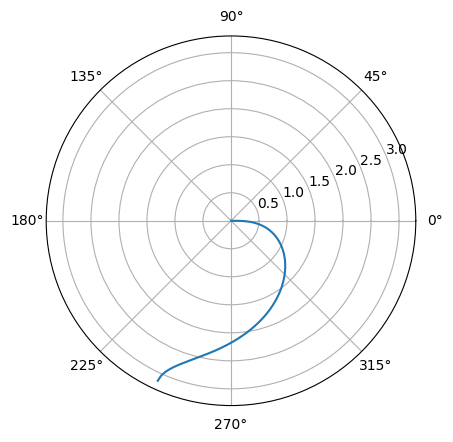

In [ ]:
theta = np.linspace(-2,0,400)
r= np.arccos(theta+1)
plt.polar(theta,r)

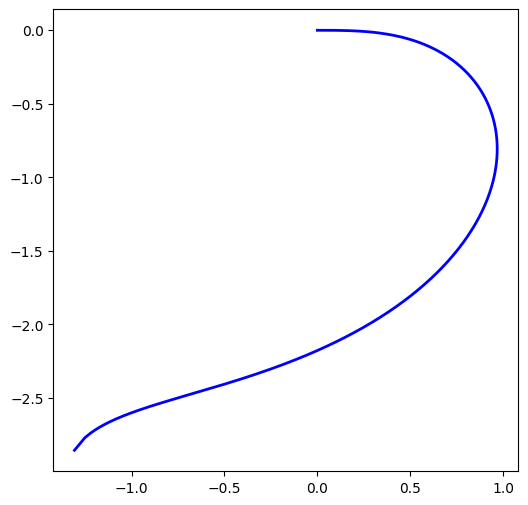

In [ ]:
theta = np.linspace(-2, 0, 400)
r = np.arccos(theta + 1)

x = r * np.cos(theta)
y = r * np.sin(theta)

plt.figure(figsize=(6, 6))
plt.plot(x, y, color='blue', linewidth=2)
plt.show()

### **1.41 Oefening 41**
Teken de lus van de poolkromme $r=\frac{1}{4~sin(\frac{\theta}{2})+cos(2\theta)}.$

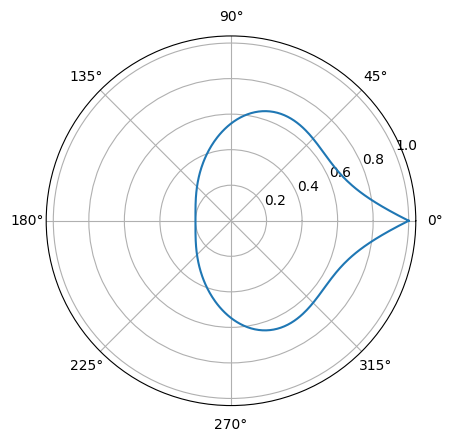

In [ ]:
theta = np.linspace(0,2*np.pi,400)
r = 1 / (4*np.sin(theta/2)+np.cos(2*theta))

plt.polar(theta,r)

### **1.42 Oefening 42**
Ga na in welke punten de cirkel met middelpunt (1,1) en straal 2 en de kromme $r=2-cos(2t)$ elkaar snijden in het vlak.
* **Oplossing:** (1.3619, -0.9670) en (0.4442, 2.9212)

Snijpunt 1: (0.4442, 2.9212)
Snijpunt 2: (1.3619, -0.9670)


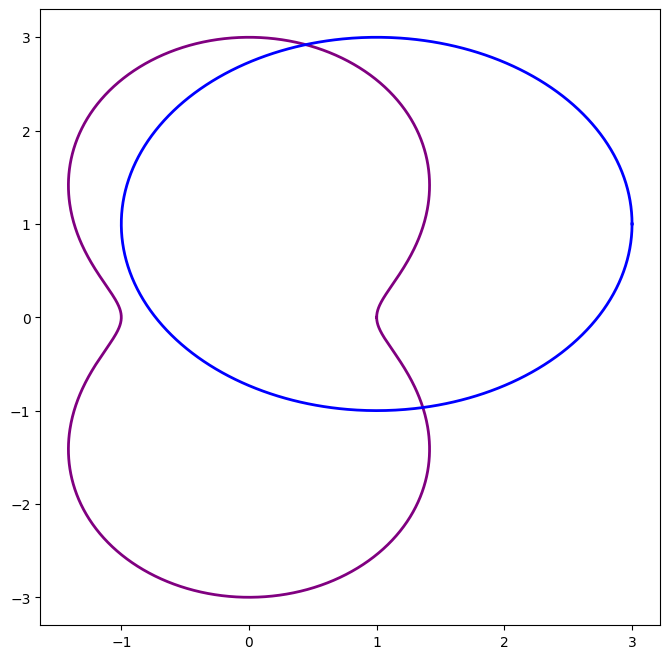

In [ ]:
t = sp.Symbol('t', real=True)
r = 2 - sp.cos(2*t)
x_kromme = r * sp.cos(t)
y_kromme = r * sp.sin(t)

vergelijking = sp.Eq((x_kromme - 1)**2 + (y_kromme - 1)**2, 4)

t1 = sp.nsolve(vergelijking, t, 1.4)
t2 = sp.nsolve(vergelijking, t, -0.6)

x1, y1 = x_kromme.subs(t, t1), y_kromme.subs(t, t1)
x2, y2 = x_kromme.subs(t, t2), y_kromme.subs(t, t2)

print(f"Snijpunt 1: ({x1:.4f}, {y1:.4f})")
print(f"Snijpunt 2: ({x2:.4f}, {y2:.4f})")

t_vals = np.linspace(0, 2*np.pi, 1000)

r_vals = 2 - np.cos(2*t_vals)
X_krom = r_vals * np.cos(t_vals)
Y_krom = r_vals * np.sin(t_vals)

X_cirk = 1 + 2 * np.cos(t_vals)
Y_cirk = 1 + 2 * np.sin(t_vals)

plt.figure(figsize=(8, 8))

plt.plot(X_krom, Y_krom, color='purple', linewidth=2)
plt.plot(X_cirk, Y_cirk, color='blue', linewidth=2)

plt.show()

### **1.43 Oefening 43**
Teken de poolkromme $r=sin(4t).$

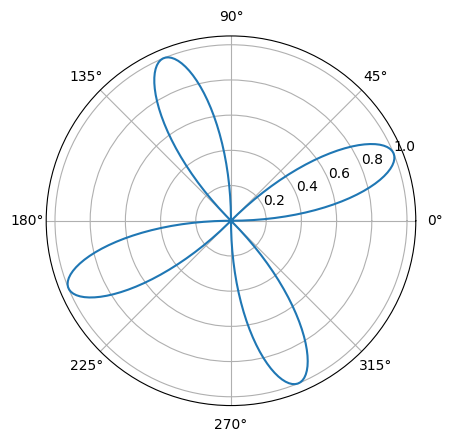

In [ ]:
theta=np.linspace(0,2*np.pi,400)
r=np.sin(4*theta)
rmax=np.maximum(0,r)
plt.polar(theta,rmax)

### **1.44 Oefening 44**
Bereken de booglengte van de kromme $r=1-cos(t)$ gelegen buiten de kromme $r+\sqrt{3}sin(t)=0$
* **Oplossing:** 6

opl =  [0, -2*pi/3]
L =  Integral(sqrt((1 - cos(t))**2 + sin(t)**2), (t, 0, 4*pi/3))
de booglengte vd blauwe kromme gelegen buiten de rode kromme is L =  6.00000000000000


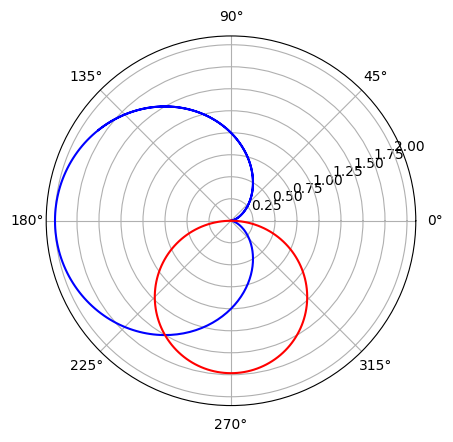

In [ ]:
theta=np.linspace(0,2**np.pi,400)
r1=1-np.cos(theta)
plt.polar(theta,r1,'b')
r2=np.maximum(0,-np.sqrt(3)*np.sin(theta))
plt.polar(theta,r2,'r')

t=sp.symbols('t')
vgl=sp.Eq(1-sp.cos(t)+sp.sqrt(3)*sp.sin(t),0)
opl=sp.solve(vgl,t)
print("opl = ",opl)

t1=opl[0]
t2=opl[1]+2*sp.pi

r1=1-sp.cos(t)
r1afg=sp.diff(r1,t)
L=sp.integrate(sp.sqrt(r1**2+r1afg**2),(t,t1,t2))
print("L = ",L)
print("de booglengte vd blauwe kromme gelegen buiten de rode kromme is L = ", L.evalf())

### **1.45 Oefening 45**
a) Teken $f(x)=e^{2~x+1}$ samen met zijn 2 afgekapte Taylorontwikkelingen rond x=1, resp. na de term in x en na de term in $x^{2}$.

b) Herhaal deze tekening voor $f(x)=x^{2}-x.$ Leg het resultaat uit.

Taylorontwikkeling rond x=1 na de term in x (met 'restterm):  exp(3) + 2*(x - 1)*exp(3) + O((x - 1)**2, (x, 1))
Taylorontwikkeling rond x=1 na de term in x:  2*(x - 1)*exp(3) + exp(3)
Taylorontwikkeling rond x=1 na de term in x²:  2*(x - 1)**2*exp(3) + 2*(x - 1)*exp(3) + exp(3)


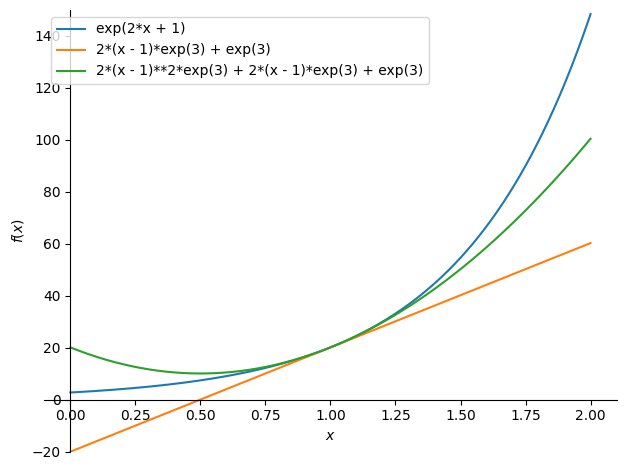

In [ ]:
x= sp.symbols('x')
f = sp.exp(2*x+1)

taylor1 = f.series(x,1,2) # graad 1
print("Taylorontwikkeling rond x=1 na de term in x (met 'restterm): ", taylor1)
print("Taylorontwikkeling rond x=1 na de term in x: ", taylor1.removeO())
taylor2=f.series(x,1,3) #graad 2
print("Taylorontwikkeling rond x=1 na de term in x²: ", taylor2.removeO())

sp.plot(f,taylor1.removeO(),taylor2.removeO(), (x,0,2), legend = True, ylim=(-20,150))

Taylorontwikkeling rond x=1 na de term in x (met 'restterm):  -1 + x + O((x - 1)**2, (x, 1))
Taylorontwikkeling rond x=1 na de term in x:  x - 1
Taylorontwikkeling rond x=1 na de term in x²:  x + (x - 1)**2 - 1


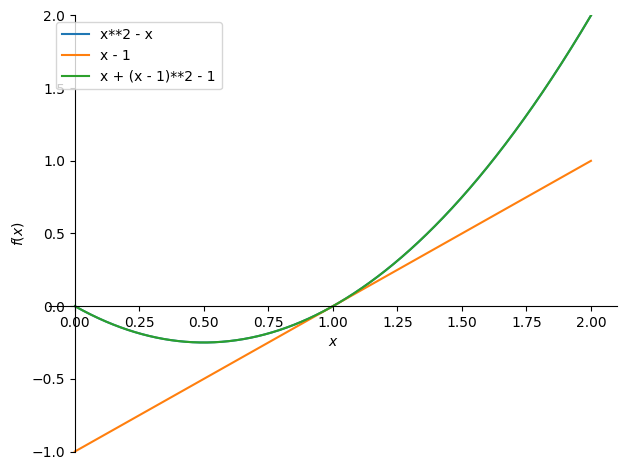

In [ ]:
x = sp.symbols('x')
f = x**2 - x

taylor1 = f.series(x,1,2) # graad 1
print("Taylorontwikkeling rond x=1 na de term in x (met 'restterm): ", taylor1)
print("Taylorontwikkeling rond x=1 na de term in x: ", taylor1.removeO())
taylor2=f.series(x,1,3) #graad 2
print("Taylorontwikkeling rond x=1 na de term in x²: ", taylor2.removeO())

sp.plot(f,taylor1.removeO(),taylor2.removeO(), (x,0,2), legend = True, ylim=(-1,2))

### **1.46 Oefening 46**
Bepaal het inverse Laplacebeeld van $F(s)=\frac{2s^{3}+8s^{2}+12s+32}{s^{4}+4s^{3}+8s^{2}+16s+16}$
* **Oplossing:** $H(t)^{*}[2^{*}exp(-2^{*}t)+sin(2^{*}t)/2+3^{*}t^{*}exp(-2^{*}t)]$

In [ ]:
t,s=sp.symbols('t s')
F=(2*s**3+8*s**2+12*s+32)/(s**4+4*s**3+8*s**2+16*s+16)
f=sp.inverse_laplace_transform(F,s,t)
print("Het invers laplacebeeld: f = ",f)

Het invers laplacebeeld: f =  3*t*exp(-2*t)*Heaviside(t) + sin(2*t)*Heaviside(t)/2 + 2*exp(-2*t)*Heaviside(t)


### **1.47 Oefening 47**
Bepaal het Laplacebeeld van $\begin{cases}\sigma(t-1),&t<2\\ e^{t-2},t>2\end{cases}$
* **Oplossing:** $exp(-s)+exp(-2^{*}s)/(s-1)$

In [ ]:
t = sp.Symbol('t')
s = sp.Symbol('s')

deel_1 = sp.DiracDelta(t-1)
deel_2 = sp.exp(t-2)*sp.Heaviside(t-2)

f = deel_1+deel_2

F_s = sp.laplace_transform(f,t,s, noconds=True)
print(F_s)

exp(-s) + exp(-2*s)/(s - 1)


### **1.48 Oefening 48**
Bereken het Laplacebeeld van de functie die niet nul is tussen 1 en 2 en daar als functiewaarde 2-x aanneemt. Bereken van het resultaat het inverse Laplacebeeld en maak een tekening van de functie.
* **Oplossing:** $exp(-2^{*}s)/s^{\wedge}2+(exp(-s)^{*}(s-1))/s^{\wedge}2$

--- Analytische Oplossing via SymPy ---
Laplacebeeld F(s): exp(-s)/s - exp(-s)/s**2 + exp(-2*s)/s**2
Inverse Laplacebeeld f(t): (t - 2)*Heaviside(t - 2) - (t - 1)*Heaviside(t - 1) + Heaviside(t - 1)



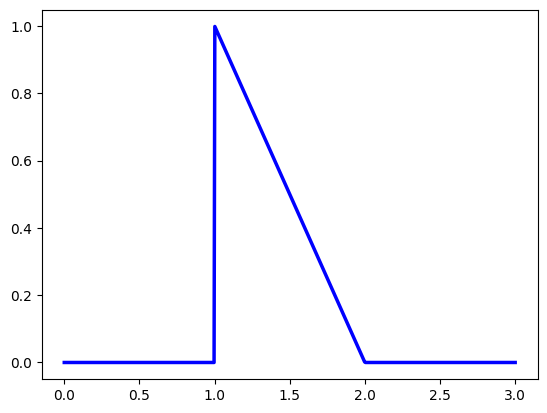

In [ ]:
t, s = sp.symbols('t s')

f = (2 - t) * (sp.Heaviside(t - 1) - sp.Heaviside(t - 2))

F_s = sp.laplace_transform(f, t, s, noconds=True)

f_inverse = sp.inverse_laplace_transform(F_s, s, t)

print("--- Analytische Oplossing via SymPy ---")
print(f"Laplacebeeld F(s): {F_s}")
print(f"Inverse Laplacebeeld f(t): {f_inverse}\n")

t_vals = np.linspace(0, 3, 600)

y_vals = np.where((t_vals >= 1) & (t_vals <= 2), 2 - t_vals, 0)

plt.plot(t_vals, y_vals, color='blue', linewidth=2.5, label='$f(t)$')
plt.show()

### **1.49 Oefening 49**
Bereken de Laplacegetransformeerde van g, waarbij je g definieert via de functie f (gedefinieerd over [0,1]) als $g(x)=f(x)+2^{*}f(x-1)+3^{*}f(x-2)$ en f samenvalt met de eerste bissectrice over [0,1] (anders functiewaarde 0).
* **Oplossing:** $g=1/s^{\wedge}2-(exp(-s)^{*}(s-1))/s^{\wedge}2-(3^{*}exp(-3^{*}s)^{*}(s+1))/s^{\wedge}2-(exp(-2^{*}s)^{*}(2^{*}s-1))/s^{\wedge}Z$

In [ ]:
t,s=sp.symbols('t s')

# f(t)
f0 = t * (sp.Heaviside(t) - sp.Heaviside(t - 1))
# f(t-1)
f1 = (t - 1) * (sp.Heaviside(t - 1) - sp.Heaviside(t - 2))
# f(t-2)
f2 = (t - 2) * (sp.Heaviside(t - 2) - sp.Heaviside(t - 3))

g = f0 + 2*f1 + 3*f2

G_s = sp.laplace_transform(g, t, s, noconds=True)
G_s_gegroepeerd = sp.collect(sp.expand(G_s), [sp.exp(-s), sp.exp(-2*s), sp.exp(-3*s)])
print(f"G(s) = {G_s_gegroepeerd}\n")

G(s) = (-3/s - 3/s**2)*exp(-3*s) + (-2/s + s**(-2))*exp(-2*s) + (-1/s + s**(-2))*exp(-s) + s**(-2)



### **1.50 Oefening 50**
Bepaal eigenwaarden en eigenvectoren van de lineaire transformatie met transformatiematrix $A=\begin{pmatrix}2&0&1\\ 0&1&0\\ 1&0&2\end{pmatrix}.$

Controleer volgende eigenschappen:

(1) het spoor van de matrix is de som van de eigenwaarden (rekening houdend met multipliciteit)

(2) de determinant van de matrix is het product van de eigenwaarden (rekening houdend met multipliciteit)

In [ ]:
A = sp.Matrix([
    [2, 0, 1],
    [0, 1, 0],
    [1, 0, 2]
])

eigen_data = A.eigenvects()

for data in eigen_data:
    waarde = data[0]
    multipliciteit = data[1]
    vectoren = data[2]
    
    print(f"\nEigenwaarde: {waarde} (Multipliciteit: {multipliciteit})")
    for i, vec in enumerate(vectoren):
        print(f"  Eigenvector {i+1}:")
        sp.pprint(vec)

print("\n--- 2. Controle van de Eigenschappen ---")

# (1) Controleer het spoor
spoor_A = A.trace()
alle_eigenwaarden = A.eigenvals(multiple=True) 
som_eigenwaarden = sum(alle_eigenwaarden)

print(f"Spoor van A      : {spoor_A}")
print(f"Som eigenwaarden : {som_eigenwaarden}")
print(f"-> Spoor == Som eigenwaarden? {spoor_A == som_eigenwaarden}\n")

# (2) Controleer de determinant
det_A = A.det()
product_eigenwaarden = 1
for val in alle_eigenwaarden:
    product_eigenwaarden *= val

print(f"Determinant van A    : {det_A}")
print(f"Product eigenwaarden : {product_eigenwaarden}")
print(f"-> Det == Product eigenwaarden? {det_A == product_eigenwaarden}")


Eigenwaarde: 1 (Multipliciteit: 2)
  Eigenvector 1:
⎡0⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣0⎦
  Eigenvector 2:
⎡-1⎤
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣1 ⎦

Eigenwaarde: 3 (Multipliciteit: 1)
  Eigenvector 1:
⎡1⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

--- 2. Controle van de Eigenschappen ---
Spoor van A      : 5
Som eigenwaarden : 5
-> Spoor == Som eigenwaarden? True

Determinant van A    : 3
Product eigenwaarden : 3
-> Det == Product eigenwaarden? True


### **1.51 Oefening 51**
Bepaal alle waarden van a zodat $|A|=-1$ met $A=\begin{pmatrix}1&a&0&6\\ 4&0&1&2\\ 1&3&-1&6\\ 1&10&3&11\end{pmatrix}.$
* **Oplossing:** 3.8230

In [ ]:
a = sp.symbols('a')
A=sp.Matrix([[1,a,0,6],
             [4,0,1,2],
             [1,3,-1,6],
             [1,10,3,11]])
detA=A.det()
vgl=sp.Eq(detA,-1)
opl = sp.solve(vgl,a)
print('a = ',opl[0].evalf())

a =  3.82300884955752


### **1.52 Oefening 52**
Een oefening uit de cursus elektriciteit geeft aanleiding tot volgend stelsel:
$$\begin{cases}l_{2}-l_{1}-l_{2}=0\\ l_{2}-l_{1}-l_{2}-l_{2}=0\\ 30l_{4}+30l_{4}=-60\\ 30l+18l_{4}+30l=60\\ -30l_{4}+10l_{4}=200\end{cases}$$
Bepaal de stroomsterkten.
* **Oplossing:** $i_{1}=-4.2A$ $i_{2}=2.2~A,$ $i_{3}=6.4A,$ $i_{4}=9.8~A$ en $i_{5}=-3.4A$

In [ ]:
A=np.array(([[-1,1,-1,0,0],
             [0,0,1,-1,-1],
             [30,30,0,0,0],
             [0,30,15,0,30],
             [0,0,0,10,-30]]))
b=np.array(([0,0,-60,60,200]))
I=np.linalg.solve(A,b)
print("I = ", I)

I =  [-4.2  2.2  6.4  9.8 -3.4]


### **1.53 Oefening 53**
Zoek een oplossing van het stelsel $\begin{cases}x+y-2z=3\\ 2x+3y+z=0.\\ y-z=1\end{cases}$
* **Oplossing:** $x=\frac{5}{6},$ $y=-\frac{1}{6}$ en $z=-\frac{7}{6}$

In [ ]:
x, y, z = sp.symbols('x y z')

eq1 = sp.Eq(x + y - 2*z, 3)
eq2 = sp.Eq(2*x + 3*y + z, 0)
eq3 = sp.Eq(y - z, 1)

oplossing = sp.solve([eq1, eq2, eq3], [x, y, z])

print("De oplossing is:")
print(f"x = {oplossing[x]}")
print(f"y = {oplossing[y]}")
print(f"z = {oplossing[z]}")

De oplossing is:
x = 5/6
y = -1/6
z = -7/6


### **1.54 Oefening 54**
Bepaal een stel eigenvectoren van de lineaire transformatie $f:(x,y,z)\rightarrow(y+z,x+z,x+y)$.
* **Oplossing:** De eigenvectoren zijn: $k \begin{bmatrix}1\\ 1\\ 1\end{bmatrix}$ met $k\in IR$ en $k_{1}\begin{bmatrix}-1\\ 0\\ 1\end{bmatrix}+k_{2}\begin{bmatrix}-1\\ 1\\ 0\end{bmatrix}$ met $k_{1},k_{2}\in IR$

In [ ]:
A = sp.Matrix([
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
])

eigen_data = A.eigenvects()

for data in eigen_data:
    waarde = data[0]
    multipliciteit = data[1]
    vectoren = data[2]
    
    print(f"\nEigenwaarde: {waarde} (Multipliciteit: {multipliciteit})")
    for i, vec in enumerate(vectoren):
        print(f"  Basis-eigenvector {i+1}:")
        sp.pprint(vec)


Eigenwaarde: -1 (Multipliciteit: 2)
  Basis-eigenvector 1:
⎡-1⎤
⎢  ⎥
⎢1 ⎥
⎢  ⎥
⎣0 ⎦
  Basis-eigenvector 2:
⎡-1⎤
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣1 ⎦

Eigenwaarde: 2 (Multipliciteit: 1)
  Basis-eigenvector 1:
⎡1⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣1⎦


### **1.55 Oefening 55**
Bepaal een orthonormaal stel eigenvectoren van de lineaire transformatie $g:(x,y,z)\rightarrow(-x,-y,-z)$ Wat is de fysische interpretatie hiervan? Verklaar het resultaat.
* **Oplossing:** $IR^{3}$.

In [ ]:
A=np.array([[-1,0,0],
            [0,-1,0],
            [0,0,-1]])
eigenwaarden,eigenvectoren=np.linalg.eig(A)
print("Eigenwaarden van A",eigenwaarden)
print("Eigenvectoren van A",eigenvectoren)

Eigenwaarden van A [-1. -1. -1.]
Eigenvectoren van A [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### **1.56 Oefening 56**
a) Bereken de eigenwaarden en eigenvectoren van $A=\begin{pmatrix}1&0&0\\ 1&1&0\\ 0&1&1\end{pmatrix}.$

b) Controleer de definitie van eigenwaarden en eigenvectoren.

c) Controleer dat de determinant van een matrix gelijk is aan het product van de eigenwaarden.

d) Controleer dat het spoor van een matrix gelijk is aan de som van de eigenwaarden.
* **Oplossing:** Er is één eigenwaarde $\lambda=1$ (met algebraïsche multipliciteit $=3$) Eigenvectoren: $k\begin{bmatrix}0\\ 0\\ 1\end{bmatrix}$ met k $\in$ IR

In [ ]:
A = sp.Matrix([
    [1, 0, 0],
    [1, 1, 0],
    [0, 1, 1]
])

# a
eigen_data = A.eigenvects()
lambda_1 = eigen_data[0][0]
multipliciteit = eigen_data[0][1]
eigenvector = eigen_data[0][2][0]

print(f"Eigenwaarde: {lambda_1} (Multipliciteit: {multipliciteit})")
print("Eigenvector:")
sp.pprint(eigenvector)

# b
Av = A * eigenvector
lv = lambda_1 * eigenvector
print("A * v =")
sp.pprint(Av)
print("lambda * v =")
sp.pprint(lv)
print(f"-> Gelijk? {Av == lv}")

# c
det_A = A.det()
prod_lambda = lambda_1 ** multipliciteit 
print(f"Determinant A : {det_A}")
print(f"Product lambda: {prod_lambda}")
print(f"-> Gelijk? {det_A == prod_lambda}")

# d
spoor_A = A.trace()
som_lambda = lambda_1 * multipliciteit
print(f"Spoor A       : {spoor_A}")
print(f"Som lambda    : {som_lambda}")
print(f"-> Gelijk? {spoor_A == som_lambda}")

Eigenwaarde: 1 (Multipliciteit: 3)
Eigenvector:
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦
A * v =
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦
lambda * v =
⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦
-> Gelijk? True
Determinant A : 1
Product lambda: 1
-> Gelijk? True
Spoor A       : 3
Som lambda    : 3
-> Gelijk? True


### **1.57 Oefening 57**
Zoek a zodat $f:(x,y,z)\rightarrow(oy+z,x+z,x+y)$ een eigenwaarde 1 heeft.
* **Oplossing:** $a=-1$

In [ ]:
a = sp.Symbol('a')

A = sp.Matrix([
    [0, a, 1],
    [1, 0, 1],
    [1, 1, 0]
])

I = sp.eye(3) # Eenheidsmatrix van 3x3
matrix_vergelijking = A - 1 * I

determinant = matrix_vergelijking.det()

print(f"De determinant van (A - I) is: {determinant}")

oplossing = sp.solve(sp.Eq(determinant, 0), a)

print(f"\nDe oplossing voor a is: {oplossing[0]}")

De determinant van (A - I) is: 2*a + 2

De oplossing voor a is: -1


### **1.58 Oefening 58**
Bij een fabriek die klinkers maakt, wil men de maatvastheid onderzoeken van de geproduceerde klinkers. Daarvoor werd een steekproef gedaan en de lengte gemeten: 12, 13, 14, 16, 15, 18, 19, 10, 11, 12, 13, 14, 15, 13, 14, 12.

(a) Presenteer een histogram van deze gegevens.

(b) Vind de mediaan, de interkwartielafstand, de modus, het gemiddelde, variantie en het 10% percentiel.
* **Oplossing:** mediaan $=13.5000$, $iqr=3$, modus = 12, gemiddelde = 13.8125, variantie = 5.7625, 10% percentiel $=11.5$

(array([1., 1., 3., 3., 3., 2., 1., 0., 1., 1.]),
 array([10. , 10.9, 11.8, 12.7, 13.6, 14.5, 15.4, 16.3, 17.2, 18.1, 19. ]),
 <BarContainer object of 10 artists>)

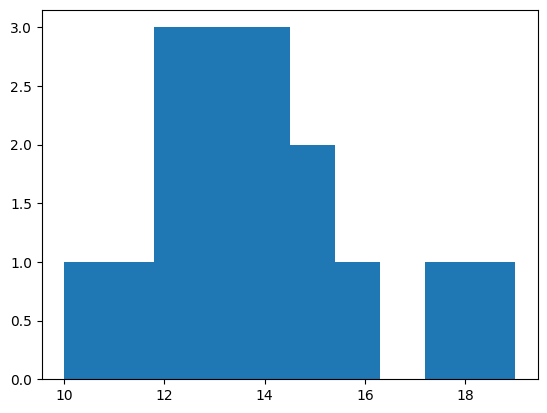

In [ ]:
lengtes = np.array([12, 13, 14, 16, 15, 18, 19, 10, 11, 12, 13, 14, 15, 13, 14, 12])
plt.hist(lengtes)

In [ ]:
print("mediaan = ", np.median(lengtes))
print("iqr = ",spstat.iqr(lengtes))
print("modus = ", stat.mode(lengtes))
print("gemiddelde = ", np.mean(lengtes))
print("variantie = ", np.var(lengtes,ddof=1))
print("10% percentiel = ", np.percentile(lengtes,10))

mediaan =  13.5
iqr =  3.0
modus =  12
gemiddelde =  13.8125
variantie =  5.7625
10% percentiel =  11.5


### **1.59 Oefening 59**
Beschouw volgende meetwaarden voor x: 24, 19, 14, 10, 7, 5, 6, 8, 12, 16, 21, 27.

(a) Maak een boxplot.

(b) Ga na met 95% betrouwbaarheid of (op basis van deze gegevens) x een normale verdeling heeft.

(c) Ga na met 95% betrouwbaarheid of (op basis van deze gegevens) x een normale verdeling heeft met gemiddelde 7.
* **Oplossing:** De data zijn afkomstig van een normale verdeling (95% betrouwbaarheid). De data zijn niet afkomstig is van een normale verdeling met gemiddelde 7 (95% betrouwbaarheid).

{'whiskers': [<matplotlib.lines.Line2D at 0x1b488764050>,
 'caps': [<matplotlib.lines.Line2D at 0x1b4887642f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b488657e00>],
 'medians': [<matplotlib.lines.Line2D at 0x1b488764590>],
 'fliers': [<matplotlib.lines.Line2D at 0x1b4887646e0>],
 'means': []}

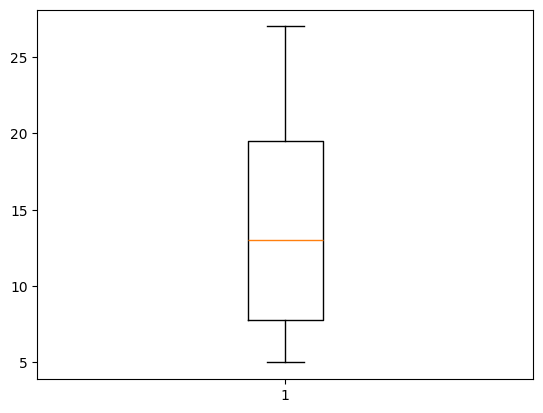

In [ ]:
data = np.array([24, 19, 14, 10, 7, 5, 6, 8, 12, 16, 21, 27])
plt.boxplot(data)

In [ ]:
gem = np.mean(data)
print('gemiddelde = ', gem)
s=np.std(data,ddof=1)
print('standaardafwijking = ',s)
D, p = spstat.kstest(data,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D} als teststatistiek, met bijhorende p-waarde {p}.")

gemiddelde =  14.083333333333334
standaardafwijking =  7.366488411390566
De KS-test heeft 0.12887791440863472 als teststatistiek, met bijhorende p-waarde 0.9735582929248066.


* Jouw p-waarde is 0.9736 (oftewel 97,36%)
* Omdat $0.9736$ veel groter is dan het 
kritieke significantieniveau $\alpha = 0.05$ (95% betrouwbaarheid), mag je $H_0$ absoluut niet verwerpen.

In [ ]:
D,p=spstat.kstest(data,spstat.norm(7,s).cdf)
print(f"De KS-test heeft {D} als teststatistiek, met bijhorende p-waarde {p}.")

De KS-test heeft 0.3930033335593103 als teststatistiek, met bijhorende p-waarde 0.035085631056209876.


* Jouw p-waarde: 0.0351 (ofwel 3,51%)Significantieniveau ($\alpha$): 0.05 (omdat je test met 95% betrouwbaarheid)
* Omdat de p-waarde kleiner is dan 0.05 ($0.0351 < 0.05$), is het resultaat statistisch significant. Dit betekent dat je de nulhypothese ($H_0$) moet verwerpen.

### **1.60 Oefening 60**
Maak een simulatie met 100 steekproefwaarden van een variabele met een $F(7,5~df)$ -verdeling. Herhaal dit 400 keer. Maak passende tekeningen om hierin de centrale limietstelling te herkennen.

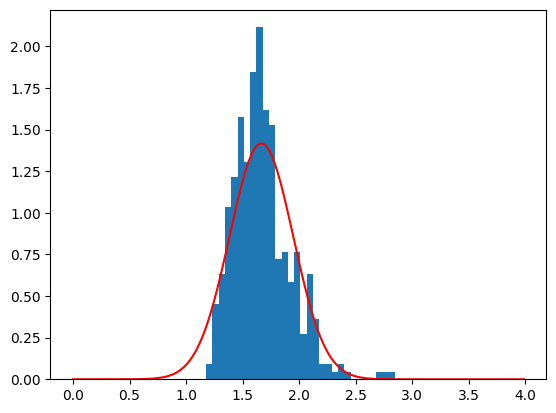

In [ ]:
data = np.random.f(7,5,(100,400))
gemiddeldes = np.mean(data,axis=0)
plt.hist(gemiddeldes, bins=30,density=True)
v1=7
v2=5
gemF=v2/(v2-2)
stdafwF=np.sqrt(2*v2**2*(v1+v2-2)/(v1*(v2-4)*(v2-2)**2))
x=np.arange(0,4,0.01)
y_norm=spstat.norm.pdf(x,gemF,stdafwF/10)
plt.plot(x,y_norm,'r')

### **1.61 Oefening 61**
(a) Geef de boxplot voor volgende data: 25, 50, 22, 10, 28, 95, 20, 14, 25, 30. Bepaal de uitschieter(s).

(b) Test of de gegevens normaalverdeeld zijn op 80%-niveau.

(c) Verwijder de uitschieter en test opnieuw.
* **Oplossing:** 
  * (b) Het normaal verdeeld zijn wordt niet aanvaard met 80% betrouwbaarheid.
  * De waarden 50 en 95 zijn blijkbaar uitschieters.
  * (c) Als we die weglaten, dan wordt het normaal verdeeld zijn aanvaard met 80% betrouwbaarheid.

De grenzen voor uitschieters zijn:  7.0  en  43.0


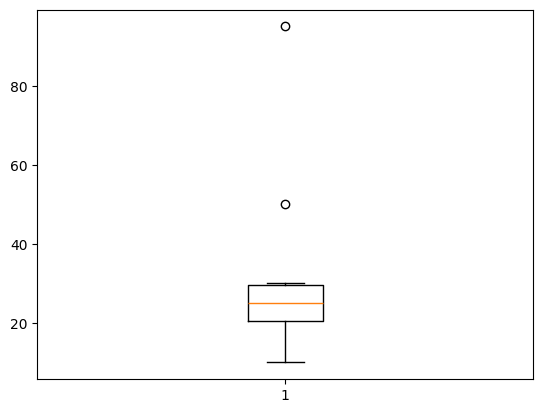

In [ ]:
data = np.array([25, 50, 22, 10, 28, 95, 20, 14, 25, 30])
plt.boxplot(data)

q1 = np.percentile(data,25)
q3 = np.percentile(data,75)
IQR = q3-q1
ondergrens = q1-1.5*IQR
bovengrens = q3 + 1.5*IQR
print("De grenzen voor uitschieters zijn: ",ondergrens, " en ", bovengrens)

In [ ]:
# b
gem = np.mean(data)
s=np.std(data,ddof=1)
D, p = spstat.kstest(data,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D} als teststatistiek, met bijhorende p-waarde {p}.")

De KS-test heeft 0.33073569092453625 als teststatistiek, met bijhorende p-waarde 0.1781652322048074.


Normaal verdeeld zijn niet aanvaard want 0.33>0.20

In [ ]:
# c
data2 = [25, 22, 10, 28, 20, 14, 25, 30]
gem = np.mean(data2)
s=np.std(data2,ddof=1)
D, p = spstat.kstest(data2,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D} als teststatistiek, met bijhorende p-waarde {p}.")

De KS-test heeft 0.1821435738368704 als teststatistiek, met bijhorende p-waarde 0.9129427123205641.


deze wordt aanvaard want 0.18<0.20

### **1.62 Oefening 62**
In onderstaande tabel staan de maandelijkse nettolonen van een KMO in de bouwsector.

| Maandloon | Aantal werknemers |
| :--- | :--- |
| [1050, 1200[ | 4 |
| [1200, 1350[ | 7 |
| [1350, 1500[ | 10 |
| [1500, 1650[ | 12 |
| [1650, 1800[ | 7 |
| [1800, 1950[ | 3 |
| [1950, 2100[ | 0 |
| [2100, 2250[ | 2 |

(a) Schat het gemiddelde loon binnen deze KMO. Wat is de standaardafwijking?

(b) Bereken zelf het 95% betrouwbaarheidsinterval voor het gemiddelde loon voor een KMO in de bouwsector op basis van deze gegevens.
* **Oplossing:** Steekproefgemiddelde $=1525$, $s=247.7168,$ 95% Bl voor $\mu=[1450.6,1599.4]$

In [ ]:
# a
middens = np.linspace(1125,2175,8)
aantallen = [4,7,10,12,7,3,0,2]
n=np.sum(aantallen)

gem=np.sum(np.multiply(aantallen,middens))/n
print(f"Het gemiddelde loon wordt geschat als {gem}")
s=np.sqrt(np.sum(np.multiply(aantallen,(middens-gem)**2))/(n-1))
print(f"De standaardafwijking: {s:.4f}")


#b 
interval=spstat.t.interval(0.95,n-1,gem,s/np.sqrt(n))
print("95% BI: ", interval)

Het gemiddelde loon wordt geschat als 1525.0
De standaardafwijking: 247.7168
95% BI:  (np.float64(1450.5776201170947), np.float64(1599.4223798829053))


### **1.63 Oefening 63**
De resultaten (/100) behaald door een selectie van 10 studenten op het examen wiskunde en economie worden gegeven in onderstaande tabel.

| Student | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Score Wiskunde | 30 | 73 | 51 | 57 | 81 | 21 | 75 | 46 | 85 | 21 |
| Score Economie | 45 | 70 | 40 | 60 | 71 | 30 | 80 | 50 | 70 | 10 |

(a) Wat is de gemiddelde score voor het examen wiskunde bij deze 10 studenten?

(b) Schat de verwachte score voor het examen economie. Wat is daarbij de standaardfout?

(c) Bij welk examen is de variantie het grootst voor deze groep studenten?

(d) Maak een scatterplot waarbij je de score voor wiskunde uitzet ten opzichte van de score voor economie.
* **Oplossing:** (a) 54, (b) 52.6, standaardfout $=6.9109$, (c) variantie grootst bij wiskunde

In [ ]:
W=[30,73,51,57,81,21,75,46,85,21]
E=[45,70,40,60,71,30,80,50,70,10]
# a
print(f"voor wiskunde scoort men gemiddeld {np.mean(W)}")
# b
gemE=np.mean(E)
varE=np.var(E,ddof=1)
stdafwE=np.sqrt(varE)
stdfoutE=stdafwE/np.sqrt(10)
print(f"voor economie is de verwachte score {gemE} met standaardfout {stdfoutE}")

# c
varW=np.var(W,ddof=1)
if varW > varE:
    print("variantie bij wisk het grootst")
else:
    print("variantie bij economie groter")

# d
plt.scatter(W,E)
plt.xlabel("score wisk")
plt.ylabel("score Eco")
plt.axis("equal")
plt.grid()
plt.show()

voor wiskunde scoort men gemiddeld 54.0
voor economie is de verwachte score 52.6 met standaardfout 6.910861017268398
variantie bij wisk het grootst


### **1.64 Oefening 64**
Genereer een steekproef met 200 waarnemingen van een variabele met als verdeling $N(2,1).$ Teken de histogram van deze steekproef. Vind een interval waarin het steekproefgemiddelde van een dergelijke steekproef zal liggen met 80% betrouwbaarheid.

80% betrouwbaarheidsinterval voor mu: (1.880, 2.066)
80% betrouwbaarheidsinterval voor mu: (1.882, 2.064)


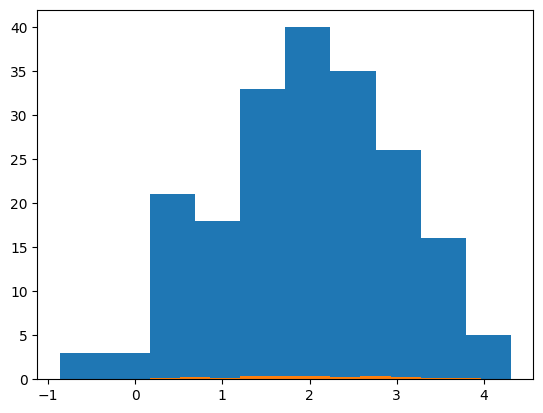

In [ ]:
# a
data = np.random.normal(2,1,200)
plt.hist(data)
plt.hist(data,bins=15,density=True)

#b 
# sigma niet gekend
tinterval = spstat.t.interval(0.8,len(data)-1,np.mean(data),spstat.sem(data))
print(f"80% betrouwbaarheidsinterval voor mu: ({tinterval[0]:.3f}, {tinterval[1]:.3f})")

# sigma gekend
sigma=1
interval = spstat.norm.interval(0.8,np.mean(data),sigma/np.sqrt(200))
print(f"80% betrouwbaarheidsinterval voor mu: ({interval[0]:.3f}, {interval[1]:.3f})")


### **1.65 Oefening 65**
$Als~x:F(5,12~d.f.)$, dan is $P(x<2)=.....$
$Als~y:t(10~d.f.)$ dan is $P(y>I)=.....$
Wat is a als $P(y<a)=0.15$?
Als z: $Bin(n=500,$ $p=0.02)$, dan is $P(z<12)=.....$ (controleer dit laatste ook met de normale verdeling en geef commentaar)
* **Oplossing:** $P(x<2)=0.8491$, $P(y>1)=0.1704$, $P(y<-1.0931)=0.15$, $P(z<12)=0.6979$ (bin) benaderd als 0.6841.

In [ ]:
# a
print('P(x<2) = ',spstat.f.cdf(2,15,12))

# b 
print('P(y>1) = 1 - P(y<1) = ', 1-spstat.t.cdf(1,10))
print('a = ',spstat.t.ppf(0.15,10), 'als P(y<a) = 0.15')

# c
print('P(z<12) = ',spstat.binom.cdf(11,500,0.02))

n = 500
p = 0.02
print('P(z<12) = ',spstat.norm.cdf(11.5,n*p,np.sqrt(n*p*(1-p))))

P(x<2) =  0.8839384428956263
P(y>1) = 1 - P(y<1) =  0.17044656615102993
a =  -1.0930580735905253 als P(y<a) = 0.15
P(z<12) =  0.6979347246811096
P(z<12) =  0.6840866796692541


het is via de normaalverdeling bijna dezelfde uitkomst

### **1.66 Oefening 66**
Genereer zelf een steekproef met 100 waarnemingen van lengtes van planken. De leverancier stelt dat de lengtes normaal verdeeld zijn met gemiddelde 2 m en $\sigma=9$ cm. Onze zaagmachine zaagt van elke plank een deel af met een lengte die normaal verdeeld verondersteld wordt met gemiddelde 1.5 m en $\sigma=1$ cm. Simuleer dit. Welke verdeling verwacht je voor de lengtes van de overblijvende stukken van de planken als je weet dat de werking van de machine onafhankelijk is van de lengte van de plank. Controleer dit aan de hand van de grafieken van de cumulatieve distributiefuncties (theoretische functie in het rood met een puntlijn).

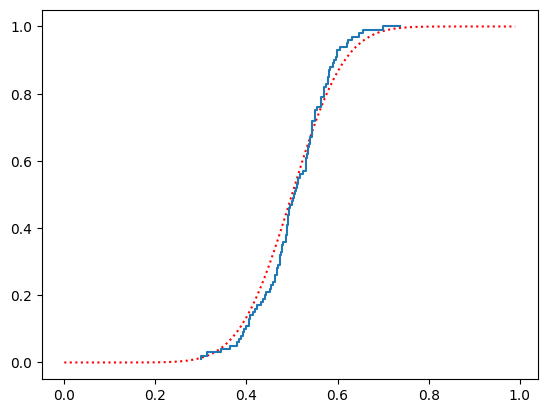

In [ ]:
restjes_sim = np.random.normal(2,0.09,100) - np.random.normal(1.5,0.01,100)
x = np.arange(0,1,1/100)
restjes_th = spstat.norm.cdf(x,0.5,np.sqrt(0.09**2+0.01**2))
plt.plot(x,restjes_th, 'r:')
ecdf = empir.ECDF(restjes_sim)
plt.step(ecdf.x,ecdf.y)
plt.show()

### **1.67 Oefening 67**
De afdeling kwaliteitscontrole van een fabriek die microgolfovens maakt, meet bij 42 ovens wat de straling is van de oven met gesloten deuren.

(a) Ga na of we er kunnen vanuit gaan dat deze emissie normaal verdeeld is.

(b) Ga na of er uitschieters zijn. Welke zijn die?

(c) Test of $\mu=0.10$ met $\alpha=0.05$.

(d) Geef een 99% betrouwbaarheidsinterval voor $\mu$.

Data: microgolf.CSV
* **Oplossing:**
  * De normale verdeling wordt verworpen met 95% betrouwbaarheid.
  * Boxplot: laat de uitschieter 0.4 zien.
  * De nulhypothese $\mu=0.10$ wordt dus aanvaard met 95% betrouwbaarheid.
  * Het 99% BI voor het gemiddelde $=\lceil0.0865, 0.1701]$.

De KS-test heeft 0.23029895187837496 als teststatistiek, met bijhorende p-waarde 0.019303873587091402.
uitschieter =  0.4
t-teststatistiek:  1.8313402094971416  met p-waarde:  0.07432279953554637
(np.float64(0.08654237069779275), np.float64(0.17012429596887396))


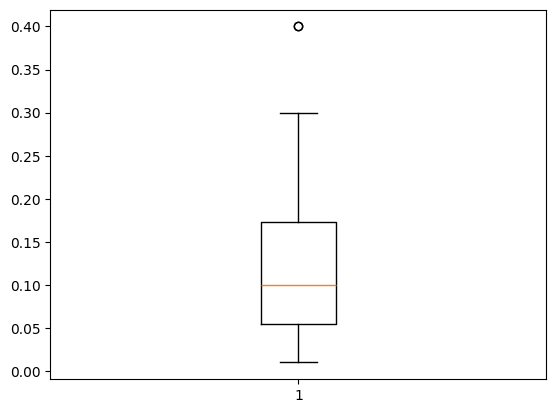

In [ ]:
data = pd.read_csv("bestanden/microgolf.csv")
emissie = data["emissie"]

# a
gem=np.mean(emissie)
s=np.std(emissie,ddof=1)
D,p=spstat.kstest(emissie,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D} als teststatistiek, met bijhorende p-waarde {p}.")

# b
plt.boxplot(emissie)
print("uitschieter = ", np.max(emissie))

# c
t_stat, p_value = spstat.ttest_1samp(emissie,0.1)
print("t-teststatistiek: ",t_stat," met p-waarde: ",p_value)

# d
interval=spstat.t.interval(0.99,len(emissie)-1,gem,spstat.sem(emissie))
print(interval)

a) normaalheid verworpen want 0.23 > 0.05

c) $\mu = 0.10$ wordt aanvaard want p-waarde 0.074 > 0.05

### **1.68 Oefening 68**
Een consumentenorganisatie evalueert de kwaliteit van zonnepanelen. Daarvoor werden op 15 daken panelen geplaatst, één van type A en één van type B. De geleverde stroom (in kWh) werd opgemeten gedurende 3 maanden. Kan op basis van deze gegevens worden geconcludeerd dat er een significant verschil is in opgewekte stroom tussen de twee soorten panelen?

Data: zonnepaneel.CSV
* **Oplossing:** De normaliteit voor de verschilvariabele wordt aanvaard met 95% betrouwbaarheid. De gelijkheid van de geleverde stroom voor types A en B (in gepaarde vorm) wordt aanvaard met 95% betrouwbaarheid.

In [ ]:
data = pd.read_csv("bestanden/zonnepaneel.csv")
typeA = data["A"]
typeB=data["B"]

verschil=typeA-typeB
gem=np.mean(verschil)
s=np.std(verschil,ddof=1)
D,p=spstat.kstest(verschil,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D} als teststatistiek, met bijhorende p-waarde {p}.")
t_stat,p_value = spstat.ttest_rel(typeA,typeB)
print("t-teststatistiek: ",t_stat," met p-waarde: ",p_value)

De KS-test heeft 0.12998107435519013 als teststatistiek, met bijhorende p-waarde 0.9332521155909874.
t-teststatistiek:  -0.9750175708258207  met p-waarde:  0.3460987059225246


De normaliteit voor de verschilvariabele wordt aanvaard met 95% betrouwbaarheid, want 0.933 > 0.05

De gelijkheid van de geleverde stroom voor types A en B (in gepaarde vorm) wordt aanvaard met 95% betrouwbaarheid, want 0.3461 > 0.05

### **1.69 Oefening 69**
Een consumentenorganisatie evalueert de kwaliteit van zonnepanelen. Daarvoor wordt op 30 daken één type zonnepaneel gelegd: ofwel type A ofwel type B. De geleverde stroom (in kWh) werd opgemeten gedurende 3 maanden. Kan op basis van deze gegevens worden geconcludeerd dat er een significant verschil is $(\alpha=0.05)$ in opgewekte stroom tussen de twee soorten panelen op populatieniveau? Maak voor beide groepen een box-and-Whisker plot en becommentarieer.

Data: zonnepaneel.CSV
* **Oplossing:** De normaliteit wordt voor beide types panelen aanvaard met 95% betrouwbaarheid. Ook de voorwaarde van gelijkheid van varianties is voldaan (factor <2). De gelijkheid van de geleverde stroom voor types A en B wordt aanvaard met 95% betrouwbaarheid.

De KS-test heeft 0.2884 als teststatistiek, met bijhorende p-waarde 0.1342.
De KS-test heeft 0.1610 als teststatistiek, met bijhorende p-waarde 0.7755.
Levene's test: statistiek = 0.0054, p-waarde = 0.9421
t-test statistiek: -0.2934, p-waarde: 0.7714


C:\Users\Talia\AppData\Local\Temp\ipykernel_27244\989890760.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([typeA,typeB],labels=['type A','type B'])


{'whiskers': [<matplotlib.lines.Line2D at 0x1b489aa9be0>,
 'caps': [<matplotlib.lines.Line2D at 0x1b489aa9e80>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b489aa9a90>,
 'medians': [<matplotlib.lines.Line2D at 0x1b489aaa120>,
 'fliers': [<matplotlib.lines.Line2D at 0x1b489aaa270>,
 'means': []}

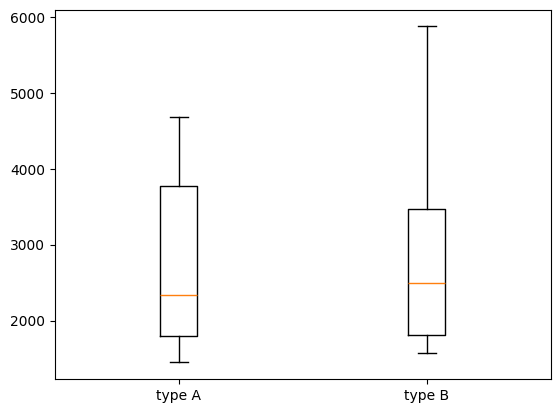

In [ ]:
data = pd.read_csv("bestanden/zonnepaneel.csv")
typeA = data["A"]
typeB=data["B"]

gemA=np.mean(typeA)
sA=np.std(typeA,ddof=1)
D,p = spstat.kstest(typeA,spstat.norm(gemA,sA).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemB=np.mean(typeB)
sB=np.std(typeB,ddof=1)
D,p = spstat.kstest(typeB,spstat.norm(gemB,sB).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

levene_stat, levene_p = spstat.levene(typeA,typeB,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")

t_stat,p_value = spstat.ttest_ind(typeA,typeB)
print(f"t-test statistiek: {t_stat:.4f}, p-waarde: {p_value:.4f}")

plt.boxplot([typeA,typeB],labels=['type A','type B'])

p waarden zijn telkens groter dan 0.05

### **1.70 Oefening 70**
Van een partij wijn wordt verondersteld dat het gemiddeld alcoholgehalte gelijk is aan 12. Een steekproef van 10 flessen geeft volgend resultaat: 12.5, 13.8, 9.7, 12.9, 12.3, 10.7, 11.6, 12.3

(a) Is de bewering juist op populatieniveau $(\alpha=0.1)?$ (2-zijdige test) Kan je dit ook verklaren aan de hand van het betrouwbaarheidsinterval voor het gemiddelde?

(b) Test of het gemiddeld alcoholgehalte van de partij wijn kleiner is dan 12.5 op 80% niveau voor de ganse populatie. Kan je dit ook verklaren aan de hand van het betrouwbaarheidsinterval voor het gemiddelde?
* **Oplossing:** Er kan met 95% betrouwbaarheid worden aangenomen dat er een normale verdeling aanwezig is. Er kan met 90% betrouwbaarheid worden gezegd dat het gemiddeld alcoholgehalte gelijk is aan 12. Er kan met 80% betrouwbaarheid worden gezegd dat het gemiddeld alcoholgehalte kleiner is dan 12.5.

In [155]:
data = np.array([12.5, 13.8, 9.7, 12.9, 12.3, 10.7, 11.6, 12.3])
n = len(data)
gemiddelde = np.mean(data)
s = np.std(data, ddof=1)

D, p_normaal = spstat.kstest(data, spstat.norm(gemiddelde, s).cdf)
print(f"KS-test p-waarde: {p_normaal:.4f} (Als p > 0.05 -> Normaal verdeeld)\n")

# Tweezijdige t-test tegen mu = 12
t_stat_a, p_val_a = spstat.ttest_1samp(data, 12)
print(f"p-waarde tweezijdige t-test: {p_val_a:.4f}")

# 90% Betrouwbaarheidsinterval (omdat alpha = 0.10)
bi_90 = spstat.t.interval(0.90, df=n-1, loc=gemiddelde, scale=spstat.sem(data))
print(f"90% Betrouwbaarheidsinterval: [{bi_90[0]:.4f}, {bi_90[1]:.4f}]\n")

# Eenzijdige t-test (alternative='less' omdat we testen of het *kleiner* is)
t_stat_b, p_val_b = spstat.ttest_1samp(data, 12.5, alternative='less')
print(f"p-waarde eenzijdige t-test: {p_val_b:.4f}")

# Eenzijdige bovengrens voor 80% betrouwbaarheid
bovengrens_80 = gemiddelde + spstat.t.ppf(0.80, df=n-1) * spstat.sem(data)
print(f"Eenzijdige 80% betrouwbaarheidsbovengrens: {bovengrens_80:.4f}")

KS-test p-waarde: 0.7372 (Als p > 0.05 -> Normaal verdeeld)

p-waarde tweezijdige t-test: 0.9578
90% Betrouwbaarheidsinterval: [11.1122, 12.8378]

p-waarde eenzijdige t-test: 0.1434
Eenzijdige 80% betrouwbaarheidsbovengrens: 12.3831


### **1.71 Oefening 71**
Voor het vervaardigen van synthetisch diamant wordt winst geboekt als de karaat-waarde > 0.5. Een steekproef van 6 diamanten geeft: 0.46, 0.61, 0.52, 0.48, 0.57, 0.54
Is algemeen gesproken de productie de moeite waard? (test op 85% niveau)
* **Oplossing:** De productie is de moeite waard met 85% betrouwbaarheid.

In [156]:
data = [0.46,0.61,0.52,0.48,0.57,0.54]
gem=np.mean(data)
s=np.std(data,ddof=1)
D,p = spstat.kstest(data,spstat.norm(gem,s).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

t_stat, p_value = spstat.ttest_1samp(data,0.5,alternative='greater')
print(f"t-test statistiek (eenzijdig): {t_stat:.4f}, p-waarde: {p_value:.4f}")

interval = spstat.t.interval(0.70,len(data)-1,gem,spstat.sem(data))
print("70% BI: ", interval)

De KS-test heeft 0.1480 als teststatistiek, met bijhorende p-waarde 0.9966.
t-test statistiek (eenzijdig): 1.3156, p-waarde: 0.1227
70% BI:  (np.float64(0.503644449569996), np.float64(0.5563555504300041))


### **1.72 Oefening 72**
De hartslag vóór en na het toedienen van een bepaalde medicatie bij zeven personen geeft volgende resultaten:

| persoon: | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| vóór | 55 | 59 | 60 | 58 | 61 | 62 | 65 |
| na | 57 | 62 | 62 | 62 | 60 | 64 | 64 |

Kan op basis van deze steekproef gesteld worden dat de hartslag op populatieniveau verhoogt door de medicatie $(\alpha=0.05)$?
* **Oplossing:** Met 95% betrouwbaarheid kan gesteld worden dat er een verhoging is van de hartslag.

In [157]:
voor = np.array([55, 59, 60, 58, 61, 62, 65])
na = np.array([57, 62, 62, 62, 60, 64, 64])

verschil = na - voor

D, p_normaal = spstat.kstest(verschil, spstat.norm(np.mean(verschil), np.std(verschil, ddof=1)).cdf)
print(f"KS-test p-waarde: {p_normaal:.4f}")
if p_normaal > 0.05:
    print("-> Normaliteit van de verschillen wordt aanvaard (p > 0.05).\n")
else:
    print("-> Data is niet normaal verdeeld.\n")

t_stat, p_waarde_t = spstat.ttest_rel(na, voor, alternative='greater')

print(f"t-test statistiek: {t_stat:.4f}")
print(f"p-waarde (eenzijdig): {p_waarde_t:.4f}")

KS-test p-waarde: 0.4525
-> Normaliteit van de verschillen wordt aanvaard (p > 0.05).

t-test statistiek: 2.1855
p-waarde (eenzijdig): 0.0358


### **1.73 Oefening 73**
De hartslag vóór en na het toedienen van een bepaalde medicatie bij zeven personen geeft volgende resultaten, waarbij 'hartslag sport' slaat op de resultaten van groep 1: personen die 2 uren sporten per week, en 'hartslag geen sport' slaat op de resultaten van groep 2: personen die geen sport doen.

| hartslag | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Sport | 55 | 59 | 60 | 58 | 61 | 62 | 65 |
| Geen sport | 57 | 62 | 62 | 62 | 60 | 64 | 64 |

Kan op basis van deze steekproef gesteld worden dat de hartslag op populatieniveau hoger is voor de groep die geen sport doet $(\alpha=0.05)$?
* **Oplossing:** Met 95% betrouwbaarheid kan gesteld worden dat er geen verhoging is van de hartslag.

In [158]:
groep1=[55,59,60,58,61,62,65]
groep2 = [57,62,62,62,60,64,64]
gem1=np.mean(groep1)
s1=np.std(groep1,ddof=1)
D, p = spstat.kstest(groep1,spstat.norm(gem1,s1).cdf)
print(f"De KS-test (voor g1) heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gem2=np.mean(groep2)
s2=np.std(groep2,ddof=1)
D, p = spstat.kstest(groep1,spstat.norm(gem2,s2).cdf)
print(f"De KS-test (voor g2) heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

levene_stat, levene_p = spstat.levene(groep1,groep2,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")

t_stat, p_value = spstat.ttest_ind(groep1,groep2,alternative='less')
print(f"t-test statistiek: {t_stat:.4f}, p-waarde: {p_value:.4f}")

De KS-test (voor g1) heeft 0.1207 als teststatistiek, met bijhorende p-waarde 0.9995.
De KS-test (voor g2) heeft 0.3117 als teststatistiek, met bijhorende p-waarde 0.4200.
Levene's test: statistiek = 0.3147, p-waarde = 0.5852
t-test statistiek: -1.0410, p-waarde: 0.1592


p-waarde overal groter dan 0.05

### **1.74 Oefening 74**
Machines produceren staafjes die een gemiddelde lengte van 12mm moeten hebben. Een steekproef van 10 staafjes bij 2 machines geeft volgende resultaten:

| Machine 1: | 11.9 | 12.3 | 11.8 | 12.1 | 12.7 | 11.7 | 11.4 | 11.5 | 11.9 | 12.0 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Machine 2: | 13.1 | 13.3 | 13.4 | 12.9 | 13.6 | 13.3 | 12.8 | 13.1 | 13.4 | 12.9 |

Steek deze data in één matrix om volgende vragen te beantwoorden.

(a) Bepaal voor beide steekproeven de gemiddelde lengte en het 90%-betrouwbaarheidsinterval.

(b) Test voor beide machines of de lengte inderdaad 12 is met 95%-betrouwbaarheid.

(c) Test of het gemiddelde voor machine 1 kleiner is dan 12 met 95%-betrouwbaarheid.

(d) Test of het gemiddelde voor machine 2 groter is dan 12 met 95%-betrouwbaarheid.

(e) Test of de gemiddelde lengte bij machine 2 meer dan 1 groter is dan bij machine 1 met 90%-betrouwbaarheid.
* **Oplossing:**
  * gemiddelde 11.9300 13.1800
  * normaliteit van lengte 1 wordt aanvaard met 95% betrouwbaarheid
  * normaliteit van lengte 2 wordt aanvaard met 95% betrouwbaarheid
  * 90% betrouwbaarheidsinterval voor lengte $1=[11.71,12.15]$
  * 90% betrouwbaarheidsinterval voor lengte $2=[13.03,13.33]$
  * gem_lengte1 $=12$ wordt aanvaard (tweezijdig met 95% betrouwbaarheid)
  * gem_lengte2 $=12$ wordt verworpen (tweezijdig met 95% betrouwbaarheid)
  * gem_lengte1<12 wordt verworpen (95% betrouwbaarheid)
  * gem_lengte2>12 wordt aanvaard (95% betrouwbaarheid)
  * gem_lengte2>gem_lengte1+1 wordt aanvaard (90% betrouwbaarheid)

In [159]:
data = np.array([
    [11.9, 12.3, 11.8, 12.1, 12.7, 11.7, 11.4, 11.5, 11.9, 12.0],  # Rij 0: Machine 1
    [13.1, 13.3, 13.4, 12.9, 13.6, 13.3, 12.8, 13.1, 13.4, 12.9]   # Rij 1: Machine 2
])

m1 = data[0, :]
m2 = data[1, :]
n1, n2 = len(m1), len(m2)

gem1, gem2 = np.mean(m1), np.mean(m2)
s1, s2 = np.std(m1, ddof=1), np.std(m2, ddof=1)

# a
bi90_m1 = spstat.t.interval(0.90, df=n1-1, loc=gem1, scale=spstat.sem(m1))
bi90_m2 = spstat.t.interval(0.90, df=n2-1, loc=gem2, scale=spstat.sem(m2))

print(f"Machine 1: Gemiddelde = {gem1:.4f} | 90% BI = [{bi90_m1[0]:.2f}, {bi90_m1[1]:.2f}]")
print(f"Machine 2: Gemiddelde = {gem2:.4f} | 90% BI = [{bi90_m2[0]:.2f}, {bi90_m2[1]:.2f}]\n")

# b
_, p_b1 = spstat.ttest_1samp(m1, 12)
_, p_b2 = spstat.ttest_1samp(m2, 12)
print(f"Machine 1 (mu=12) p-waarde: {p_b1:.4f} (Groter dan 0.05 -> Aanvaard)")
print(f"Machine 2 (mu=12) p-waarde: {p_b2:.4f} (Kleiner dan 0.05 -> Verworpen)\n")

#c
_, p_c = spstat.ttest_1samp(m1, 12, alternative='less')
print(f"Machine 1 (mu<12) p-waarde: {p_c:.4f} (Groter dan 0.05 -> Verworpen)\n")

# d
_, p_d = spstat.ttest_1samp(m2, 12, alternative='greater')
print(f"Machine 2 (mu>12) p-waarde: {p_d:.4f} (Kleiner dan 0.05 -> Aanvaard)\n")

# e
_, p_levene = spstat.levene(m1, m2)

sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
se_diff = sp * np.sqrt(1/n1 + 1/n2)

t_stat_e = ((gem2 - gem1) - 1.0) / se_diff
df_e = n1 + n2 - 2
p_waarde_e = 1 - spstat.t.cdf(t_stat_e, df=df_e)

print(f"Levene's test p-waarde: {p_levene:.4f} -> Gelijk")
print(f"Verschil t-statistiek : {t_stat_e:.4f}")
print(f"Eenzijdige p-waarde   : {p_waarde_e:.4f} (Kleiner dan 0.10 -> Aanvaard)")

Machine 1: Gemiddelde = 11.9300 | 90% BI = [11.71, 12.15]
Machine 2: Gemiddelde = 13.1800 | 90% BI = [13.03, 13.33]

Machine 1 (mu=12) p-waarde: 0.5747 (Groter dan 0.05 -> Aanvaard)
Machine 2 (mu=12) p-waarde: 0.0000 (Kleiner dan 0.05 -> Verworpen)

Machine 1 (mu<12) p-waarde: 0.2874 (Groter dan 0.05 -> Verworpen)

Machine 2 (mu>12) p-waarde: 0.0000 (Kleiner dan 0.05 -> Aanvaard)

Levene's test p-waarde: 0.5823 -> Gelijk
Verschil t-statistiek : 1.7130
Eenzijdige p-waarde   : 0.0519 (Kleiner dan 0.10 -> Aanvaard)


### **1.75 Oefening 75**
Een onderzoek werd opgericht om na te gaan of de leeftijd van de autobestuurder invloed heeft op zijn rijgedrag, met name het aantal auto-ongevallen waarin hij betrokken geraakt gedurende een jaar. Test met een betrouwbaarheid van 95% of de leeftijd van de bestuurder los staat van het aantal ongevallen op populatieniveau?

Data: rijgedrag.CSV
* **Oplossing:** Met 95% betrouwbaarheid kan dus gesteld worden dat de leeftijd van de bestuurder een invloed heeft op het aantal ongevallen.

In [160]:
data = pd.read_csv('bestanden/rijgedrag.csv')
leeftijd = data['leeftijd']
ongevallen=data['aantal_ongevallen']

kruistabel = pd.crosstab(leeftijd,ongevallen)
print(kruistabel)

res = spstat.chi2_contingency(kruistabel)
print(f"De chi2-toetsingsgrootheid bedraagt {res.statistic:.3f}")
print(f"Het aantal vrijheidsgraden = {res.dof}")

aantal_ongevallen   0   1   2   3
leeftijd                         
2                  44  16  10   3
3                  25  16   6   6
4                  10  12  15  12
5                  11  14  17   8
De chi2-toetsingsgrootheid bedraagt 38.065
Het aantal vrijheidsgraden = 9


### **1.76 Oefening 76**
Tijdens een verkeerscontrole werden 1024 automobilisten gecontroleerd op het al dan niet dragen van de gordel. Daarvan waren er 464 mannen en 560 vrouwen. Van de mannen droegen er in totaal 192 een gordel. Van de 560 vrouwen waren dit er 284.

(a) Onderzoek of er een significante samenhang bestaat tussen het geslacht van de bestuurder en het dragen van de gordel.

(b) Indien er absolute onafhankelijkheid zou zijn tussen het rij- en kolomcriterium, hoeveel mannen zouden er een gordel dragen bij de 1024 automobilisten?
* **Oplossing:**
  * Met 95% betrouwbaarheid kan gesteld worden dat er een afhankelijkheid is tussen de gender van de bestuurder en het dragen van de gordel.
  * Indien er absolute onafhankelijkheid zou zijn tussen het rij- en kolomcriterium, zouden er 215.7 mannen een gordel dragen.

In [162]:
tabel = np.array([
    [192, 272],  # Mannen
    [284, 276]   # Vrouwen
])

# a
chi2, p_val, dof, expected = spstat.chi2_contingency(tabel, correction=False)

print(f"Berekende chi2-waarde : {chi2:.4f}")
print(f"p-waarde              : {p_val:.4f}")
print(f"Aantal vrijheidsgraden: {dof}")

# b
print(f"Verwacht aantal mannen met gordel: {expected[0, 0]:.1f}")
print(f"Volledige verwachte matrix:\n{expected}")

alpha = 0.05
if p_val < alpha:
    print(f"p-waarde ({p_val:.4f}) < 0.05: We verwerpen H0.")
    print("Er bestaat een significante samenhang tussen het geslacht en het dragen van de gordel.")
else:
    print(f"p-waarde ({p_val:.4f}) >= 0.05: We behouden H0.")
    print("Er is geen significante samenhang aangetoond.")

Berekende chi2-waarde : 8.8888
p-waarde              : 0.0029
Aantal vrijheidsgraden: 1
Verwacht aantal mannen met gordel: 215.7
Volledige verwachte matrix:
[[215.6875 248.3125]
 [260.3125 299.6875]]
p-waarde (0.0029) < 0.05: We verwerpen H0.
Er bestaat een significante samenhang tussen het geslacht en het dragen van de gordel.


### **1.77 Oefening 77**
Men wenst te onderzoeken wie kiest voor het bouwen van passieve woningen. Daarvoor heeft men gepeild naar het opleidingsniveau van de mensen die een woning bouwen. Er wordt onderscheid gemaakt volgens drie klassen (groep $1=$ hoger opgeleiden, groep $2=$ middengroep, groep $3=$ laaggeschoolden). De aantallen staan genoteerd in volgende tabel.

| | groep 1 | groep 2 | groep 3 |
| :--- | :--- | :--- | :--- |
| Passieve woning | 14 | 30 | 11 |
| Geen passieve woning | 44 | 142 | 257 |

(a) Ga je op basis van deze steekproef akkoord met de stelling dat er geen verschil is qua opleidingsniveau bij de keuze voor een passieve woning op populatieniveau? $(\alpha=5\%)$?

(b) Hoeveel procent van de passieve woningen worden gebouwd door laaggeschoolden?

(c) Hoeveel procent van de hoger opgeleiden kiest voor een passieve woning?
* **Oplossing:**
  * Met 95% betrouwbaarheid kan gesteld worden dat er een afhankelijkheid is tussen het opleidingsniveau en het type woning.
  * 20% procent van de passieve woningen wordt gebouwd door laaggeschoolden.
  * 24.14% procent van de hoger opgeleiden kiest voor een passieve woning.

In [163]:
tabel = np.array([
    [14, 30, 11],  # Passieve woning
    [44, 142, 257] # Geen passieve woning
])

# a
chi2, p_val, dof, expected = spstat.chi2_contingency(tabel, correction=False)

print(f"p-waarde: {p_val}")
if p_val < 0.05:
    print("-> p < 0.05: We verwerpen H0. Er is een significante afhankelijkheid.\n")
else:
    print("-> p >= 0.05: We behouden H0.\n")

rij_totalen = np.sum(tabel, axis=1)   # [Totaal passief, Totaal geen passief]
kolom_totalen = np.sum(tabel, axis=0) # [Totaal Groep 1, Totaal Groep 2, Totaal Groep 3]

# b
perc_b = (tabel[0, 2] / rij_totalen[0]) * 100
print(f"b) Percentage passieve woningen door laaggeschoolden: {perc_b:.2f}%")

# c
perc_c = (tabel[0, 0] / kolom_totalen[0]) * 100
print(f"c) Percentage hoger opgeleiden dat kiest voor passief: {perc_c:.2f}%")

p-waarde: 2.473675736912867e-07
-> p < 0.05: We verwerpen H0. Er is een significante afhankelijkheid.

b) Percentage passieve woningen door laaggeschoolden: 20.00%
c) Percentage hoger opgeleiden dat kiest voor passief: 24.14%


### **1.78 Oefening 78**
De dienst volksgezondheid wenst na te gaan of mensen die veel in de omgeving vertoeven van rokers, maar zelf niet-roker zijn, daar nadelige effecten van ondervinden. Om hier uitsluitsel over te geven werden drie groepen mensen geselecteerd: een groep rokers (groep 1), een groep niet-rokers die passief meeroken (groep 2) en een groep niet-rokers (groep 3) die ook niet in de buurt van rokers verblijven. De data die verzameld werden bestaan uit gemeten cotininewaarden (in $ng/ml$). Deze stof is aanwezig in het bloed en vormt zich wanneer nicotine wordt opgenomen door het bloed. Vergelijk de drie groepen. Controleer of kan aangenomen worden dat de varianties van de verschillende groepen overeenstemmen. Zijn de onderliggende verdelingen normaal verdeeld?
Voer de oefening op 2 manieren uit qua input van gegevens:

• Invoer in de vorm terug te vinden in onderstaande csv-file

• Invoer herschikt in een csv-file waarbij per kolom meetwaarden terug te vinden zijn van een welbepaalde groep

Data: cotinine.CSV
* **Oplossing:** Met 95% betrouwbaarheid kan gesteld worden dat er verschil is in cotininewaarden tussen de groepen $(p=9.0029e-05<0.05)$, meer bepaald tussen groep 1 en groep 2 en tussen groep 1 en groep 3. Het controleren van de normaliteit voor elk van de groepen levert telkens een positief resultaat op met 95% betrouwbaarheid.

In [167]:
df_long = pd.read_csv('bestanden/cotinine.CSV')

g1 = df_long[df_long['groep'] == 1]['cotinine']
g2 = df_long[df_long['groep'] == 2]['cotinine']
g3 = df_long[df_long['groep'] == 3]['cotinine']


for i, g in enumerate([g1, g2, g3], 1):
    gem = np.mean(g)
    s = np.std(g, ddof=1)
    D, p_ks = spstat.kstest(g, spstat.norm(gem, s).cdf)
    print(f"Groep {i} - KS-test p-waarde: {p_ks:.4f} (Normaal? {p_ks > 0.05})")

stat_lev, p_lev = spstat.levene(g1, g2, g3)
print(f"\nLevene's test p-waarde: {p_lev:.4f} (Gelijke varianties? {p_lev > 0.05})")

stat_anova, p_anova = spstat.f_oneway(g1, g2, g3)
print(f"\nANOVA p-waarde: {p_anova} (Significant verschil? {p_anova < 0.05})")

res_tukey = spstat.tukey_hsd(g1, g2, g3)
print("\n--- Tukey HSD Post-hoc Matrix ---")
print(res_tukey)

Groep 1 - KS-test p-waarde: 0.6713 (Normaal? True)
Groep 2 - KS-test p-waarde: 0.5563 (Normaal? True)
Groep 3 - KS-test p-waarde: 0.2802 (Normaal? True)

Levene's test p-waarde: 0.0163 (Gelijke varianties? False)

ANOVA p-waarde: 0.0001216624704811441 (Significant verschil? True)

--- Tukey HSD Post-hoc Matrix ---
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     91.385     0.001    33.577   149.192
 (0 - 2)    109.385     0.000    49.302   169.467
 (1 - 0)    -91.385     0.001  -149.192   -33.577
 (1 - 2)     18.000     0.738   -41.043    77.043
 (2 - 0)   -109.385     0.000  -169.467   -49.302
 (2 - 1)    -18.000     0.738   -77.043    41.043



In [168]:
df_wide = pd.read_csv('cotinine_herschikt.CSV')

g1 = df_wide['Groep1'].dropna()
g2 = df_wide['Groep2'].dropna()
g3 = df_wide['Groep3'].dropna()

for i, g in enumerate([g1, g2, g3], 1):
    gem = np.mean(g)
    s = np.std(g, ddof=1)
    D, p_ks = spstat.kstest(g, spstat.norm(gem, s).cdf)
    print(f"Groep {i} - KS-test p-waarde: {p_ks:.4f}")

stat_lev, p_lev = spstat.levene(g1, g2, g3)
print(f"\nLevene's test p-waarde: {p_lev:.4f}")

stat_anova, p_anova = spstat.f_oneway(g1, g2, g3)
print(f"\nANOVA p-waarde: {p_anova}")

res_tukey = spstat.tukey_hsd(g1, g2, g3)
print("\n--- Tukey HSD Post-hoc Matrix ---")
print(res_tukey)

FileNotFoundError: [Errno 2] No such file or directory: 'cotinine_herschikt.CSV'

* De KS-testen zullen voor alle drie de groepen een p-waarde $> 0.05$ opleveren (normaliteit aanvaard).
* De ANOVA-test zal exact de p-waarde 9.0029e-05 (of zeer dicht in de buurt) geven. Omdat dit $< 0.05$ is, is er een significant verschil.
* De Tukey HSD tabel laat in de output bij de vergelijkingen tussen (Groep 1 vs 2) en (Groep 1 vs 3) een p-waarde zien die kleiner is dan $0.05$, wat de specifieke verschillen uit de modeloplossing bevestigt.

### **1.79 Oefening 79**
Een onderzoeker is geïnteresseerd in de breeksterkte van verschillende gelamineerde balken gemaakt uit drie houtvariëteiten en drie verschillende soorten lijm. Om deze te vergelijken werden vijf balken van elk van de negen combinaties aangemaakt en daarna onderworpen aan een spanningstest. De data bestaat uit waarden voor de druk waarbij de balken braken. Maak een vergelijkend onderzoek waarbij je er mag van uitgaan dat de assumpties voor de testen voldaan zijn.

Data: balken.CSV
* **Oplossing:**
  * Er is interactie tussen de lijm en de houtsoort (95% betrouwbaarheid).
  * Het controleren van de normaliteit voor elk van de groepen levert telkens een positief resultaat op met 95% betrouwbaarheid.

De KS-test heeft 0.1316 als teststatistiek, met bijhorende p-waarde 0.9273.
De KS-test heeft 0.2184 als teststatistiek, met bijhorende p-waarde 0.4125.
De KS-test heeft 0.3021 als teststatistiek, met bijhorende p-waarde 0.1036.
De KS-test heeft 0.1658 als teststatistiek, met bijhorende p-waarde 0.7448.
De KS-test heeft 0.1457 als teststatistiek, met bijhorende p-waarde 0.8639.
De KS-test heeft 0.1309 als teststatistiek, met bijhorende p-waarde 0.9300.
Levene's test: statistiek = 0.2213, p-waarde = 0.8024
Levene's test: statistiek = 0.4923, p-waarde = 0.6147
                      sum_sq    df          F    PR(>F)
C(lijm)          6643.733333   2.0  20.118977  0.000001
C(hout)           682.533333   2.0   2.066891  0.141339
C(lijm):C(hout)  2715.733333   4.0   4.111978  0.007600
Residual         5944.000000  36.0        NaN       NaN


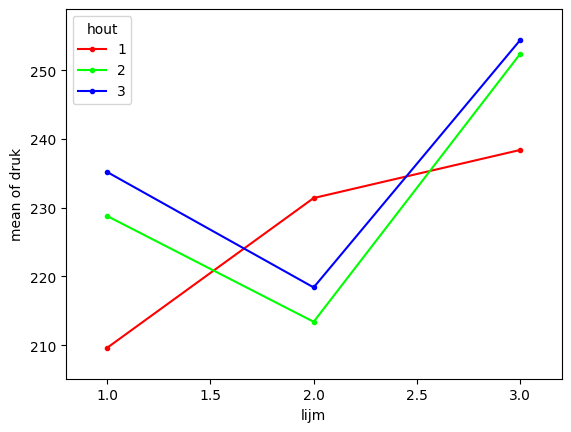

In [169]:
data = pd.read_csv('bestanden/balken.csv')
L1=data.druk[0:15]
L2=data.druk[15:30]
L3=data.druk[30:45]
H1=data.loc[data['hout']==1,'druk']
H2=data.loc[data['hout']==2,'druk']
H3=data.loc[data['hout']==3,'druk']

gemL1=np.mean(L1)
sL1=np.std(L1,ddof=1)
D,p=spstat.kstest(L1,spstat.norm(gemL1,sL1).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemL2=np.mean(L2)
sL2=np.std(L2,ddof=1)
D,p=spstat.kstest(L2,spstat.norm(gemL2,sL2).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemL3=np.mean(L3)
sL3=np.std(L3,ddof=1)
D,p=spstat.kstest(L3,spstat.norm(gemL3,sL3).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

gemH1=np.mean(H1)
sH1=np.std(H1,ddof=1)
D,p=spstat.kstest(H1,spstat.norm(gemH1,sH1).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemH2=np.mean(H2)
sH2=np.std(H2,ddof=1)
D,p=spstat.kstest(H2,spstat.norm(gemH2,sH2).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemH3=np.mean(H3)
sH3=np.std(H3,ddof=1)
D,p=spstat.kstest(H3,spstat.norm(gemH3,sH3).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

levene_stat, levene_p = spstat.levene(L1,L2,L3,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")
levene_stat, levene_p = spstat.levene(H1,H2,H3,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")

model = ols('druk ~C(lijm) + C(hout) + C(lijm):C(hout)',data=data).fit()
print(anova_lm(model,typ=2))

fig=interaction_plot(data.lijm,data.hout,data.druk)

1. Controle van de Assumpties
    *  Normaliteit (KS-testen): Alle p-waarden van de KS-testen (variërend van 0.1036 tot 0.9300) zijn groter dan $\alpha = 0.05$. De nulhypothese van normaliteit wordt voor elke groep aanvaard.
    * Gelijkheid van varianties (Levene's testen): De p-waarden van beide Levene's testen (0.8024 en 0.6147) zijn groter dan $0.05$. De varianties tussen de groepen zijn dus statistisch gelijk.
    
Aan alle voorwaarden voor een betrouwbare Two-Way ANOVA is voldaan.

2. Interpretatie van de Two-Way ANOVA ($\alpha = 0.05$)Bij een Two-Way ANOVA met interactie kijk je altijd eerst naar de interactieterm:
    * Interactie-effect (C(lijm):C(hout)): * p-waarde: 0.0076
        * Conclusie: Omdat $0.0076 < 0.05$, is er een significant interactie-effect. Dit betekent dat de invloed van de lijmsoort op de breeksterkte afhankelijk is van de gekozen houtsoort (en omgekeerd). De combinatie van hout en lijm is dus doorslaggevend
    * Hoofdeffect Lijm (C(lijm)):
        * p-waarde: 0.000001
        * Conclusie: Omdat $0.000001 < 0.05$, is er een significant hoofdeffect van de lijmsoort.
    * Hoofdeffect Hout (C(hout)):
        * p-waarde: 0.1413
        * Conclusie: Omdat $0.1413 > 0.05$, is er op zich geen globaal significant hoofdeffect van de houtsoort alleen
Eindbesluit voor je oefeningDe assumptietesten leveren telkens een positief resultaat op. Met 95% betrouwbaarheid kan gesteld worden dat er een significante interactie is tussen de lijm en de houtsoort op populatieniveau bij het bepalen van de breeksterkte.

### **1.80 Oefening 80**
Men wenst onderzoek te doen rond verschillende samenstellingen om het wegdek van de snelweg mee te bouwen. Bij een proefproject worden de vier verschillende types wegdek (die verschillen qua samenstelling van de asfalt) gebruikt op de E17, de E40, de R4 en de E413, telkens met een strook van 1 km. Na vijf jaar wordt geëvalueerd hoeveel herstellingen dienden te gebeuren (zie tabel). Maak een totale variantie-analyse voor wat betreft de types wegdek op de verschillende snelwegen waarbij je er mag van uitgaan dat de assumpties voor de testen voldaan zijn.

| | Type I | Type II | Type III | Type IV |
| :--- | :--- | :--- | :--- | :--- |
| E17 | 4 | 3 | 6 | 10 |
| E40 | 10 | 8 | 5 | 16 |
| R4 | 2 | 0 | 3 | 4 |
| E413 | 1 | 2 | 3 | 4 |

* **Oplossing:**
  * Zowel de rij (snelweg) als de kolom (soort asfalt) hebben een significante invloed $(\alpha=0.05)$.
  * Tussen E40 en E413 is er een significant verschil, evenals tussen E40 en R4 $(\alpha=0.05)$.
  * Tussen asfalt type 2 en asfalt type 4 is er ook een significant verschil (met 95% betrouwbaarheid).

In [170]:
data=pd.DataFrame({'snelweg': np.repeat(['E17','E40','R4','E412'],4),
                   'type': np.tile(['I','II','III','IV'],4),
                   'aantal': [4,3,6,10,
                              10,8,5,16,
                              2,0,3,4,
                              1,2,3,4]})

model=ols('aantal ~ C(snelweg) + C(type)',data=data).fit()
print(anova_lm(model,typ=2))

              sum_sq   df          F    PR(>F)
C(snelweg)  147.6875  3.0  10.660150  0.002554
C(type)      65.6875  3.0   4.741353  0.029988
Residual     41.5625  9.0        NaN       NaN


1. Type Analyse

Dit is een Two-Way ANOVA zonder interactie (of een blokontwerp), aangezien er voor elke unieke combinatie van snelweg en asfaltsoort exact één meting is gedaan (16 waarnemingen in totaal). We testen tegen het standaard significantieniveau $\alpha = 0.05$.

2. Interpretatie van de ANOVA-tabel
    * Effect van de Snelweg (C(snelweg)):
        * p-waarde (PR(>F)): 0.002554
        * Conclusie: Omdat $0.002554 < 0.05$, is dit effect statistisch zeer significant. De snelweg waarop het asfalt ligt, heeft een significante invloed op het aantal herstellingen (waarschijnlijk door verschillen in verkeersdrukte of vrachtverkeer)
        * Koppeling met de post-hoc resultaten: Een aanvullende Tukey-test toont aan dat dit verschil voornamelijk te wijten is aan het significante verschil tussen de E40 en de E413, en tussen de E40 en de R4.
    * Effect van het Type Wegdek (C(type)):
        * p-waarde (PR(>F)): 0.029988
        * Conclusie: Omdat $0.029988 < 0.05$, is ook dit effect statistisch significant. De chemische samenstelling van het asfalt heeft een significante invloed op de duurzaamheid van het wegdek.
        * Koppeling met de post-hoc resultaten: Dit verschil zit specifiek tussen Asfalt Type II en Asfalt Type IV

Eindbesluit voor je examen

Zowel de rijen (de snelwegen) als de kolommen (de types asfalt) hebben met 95% betrouwbaarheid een significante invloed op het aantal herstellingen op populatieniveau. De nulhypothesen van gelijkheid worden voor beide factoren verworpen.

### **1.81 Oefening 81**
Op verschillende plaatsen worden watermonsters genomen en het zuurstofgehalte bepaald:
plaats 1: stroomopwaarts
plaats 2: nabij een fabriek
plaats 3: stroomafwaarts
Ga na of er een significant verschil is tussen de plaatsen.

| Plaats | | Gemiddelde zuurstof | | |
| :--- | :--- | :--- | :--- | :--- |
| 1 | 6.3 | 6.6 | 6.4 | 6.5 |
| 2 | 4.8 | 4.3 | 5.0 | 5.1 |
| 3 | 6.0 | 6.2 | 6.3 | 6.2 |

* **Oplossing:**
  * Voorwaarden (normaliteit en gelijkheid van varianties) om de test uit te voeren zijn voldaan.
  * Met 95% betrouwbaarheid kan een verschil gevonden worden in zuurstofgehalte volgens de locatie. (significant verschil tussen locatie 2 en 1 en tussen locatie 2 en 3)

De KS-test heeft 0.2371 als teststatistiek, met bijhorende p-waarde 0.8821.
De KS-test heeft 0.1986 als teststatistiek, met bijhorende p-waarde 0.9641.
De KS-test heeft 0.2915 als teststatistiek, met bijhorende p-waarde 0.6974.
Levene's test: statistiek = 1.5228, p-waarde = 0.2574
F-statistiek =  76.89333333333362 , p-waarde =  1.438102623123067e-07
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      1.660     0.000     1.283     2.037
 (0 - 2)      0.340     0.079    -0.037     0.717
 (1 - 0)     -1.660     0.000    -2.037    -1.283
 (1 - 2)     -1.320     0.000    -1.697    -0.943
 (2 - 0)     -0.340     0.079    -0.717     0.037
 (2 - 1)      1.320     0.000     0.943     1.697



C:\Users\Talia\AppData\Local\Temp\ipykernel_27244\611501914.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([P1,P2,P3],labels=['plaats 1', 'plaats 2', 'plaats 3'])


{'whiskers': [<matplotlib.lines.Line2D at 0x1b489c18830>,
 'caps': [<matplotlib.lines.Line2D at 0x1b489c19010>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b489c18ad0>,
 'medians': [<matplotlib.lines.Line2D at 0x1b489c19550>,
 'fliers': [<matplotlib.lines.Line2D at 0x1b489c19400>,
 'means': []}

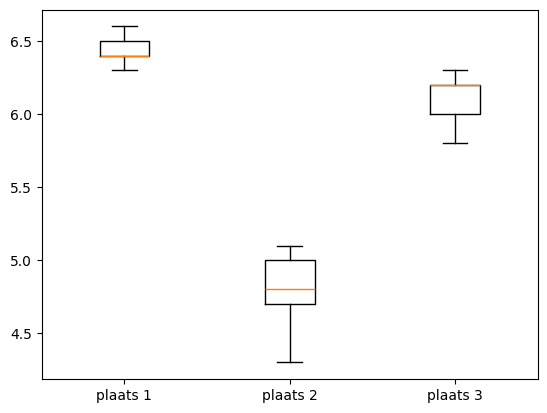

In [171]:
P1=[6.3,6.6,6.4,6.4,6.5]
P2=[4.8,4.3,5.0,4.7,5.1]
P3=[6.0,6.2,6.3,5.8,6.2]

gemP1=np.mean(P1)
sP1=np.std(P1,ddof=1)
D,p=spstat.kstest(P1,spstat.norm(gemP1,sP1).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemP2=np.mean(P2)
sP2=np.std(P2,ddof=1)
D,p=spstat.kstest(P2,spstat.norm(gemP2,sP2).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemP3=np.mean(P3)
sP3=np.std(P3,ddof=1)
D,p=spstat.kstest(P3,spstat.norm(gemP3,sP3).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

levene_stat, levene_p = spstat.levene(P1,P2,P3,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")

Fwaarde,pwaardeA=spstat.f_oneway(P1,P2,P3)
print("F-statistiek = ", Fwaarde, ", p-waarde = ",pwaardeA)

print(spstat.tukey_hsd(P1,P2,P3))

plt.boxplot([P1,P2,P3],labels=['plaats 1', 'plaats 2', 'plaats 3'])

1. Controle van de Assumpties (Voorwaarden)
    * Normaliteit (KS-testen): De drie p-waarden van de KS-testen (0.8821, 0.9641 en 0.6974) zijn allemaal veel groter dan $\alpha = 0.05$. De data binnen elke groep zijn dus normaal verdeeld.
    * Gelijkheid van varianties (Levene's test): De p-waarde is 0.2574. Omdat $0.2574 > 0.05$, wordt de nulhypothese van gelijke varianties aanvaard.
De voorwaarden om een betrouwbare One-Way ANOVA uit te voeren zijn dus volledig voldaan.
2. Interpretatie van de One-Way ANOVA ($\alpha = 0.05$)
    * F-statistiek: 76.8933
    * p-waarde: 1.4381e-07 (oftewel $0.00000014$)
    * Conclusie: Omdat de p-waarde extreem veel kleiner is dan $0.05$, verwerpen we de nulhypothese. Er is op populatieniveau een zeer significant verschil in het zuurstofgehalte tussen de verschillende meetplaatsen.
3. Post-hoc Analyse (Paarsgewijze vergelijkingen)

    Om te zien wáár de verschillen precies zitten, kijken we naar de paarsgewijze vergelijkingen (waarbij index 0 = plaats 1, index 1 = plaats 2, index 2 = plaats 3):
    * Plaats 1 vs. Plaats 2 (0 - 1): p-waarde = 0.000 $\rightarrow$ Significant verschil
    * Plaats 2 vs. Plaats 3 (1 - 2): p-waarde = 0.000 $\rightarrow$ Significant verschil
    * Plaats 1 vs. Plaats 3 (0 - 2): p-waarde = 0.079 $\rightarrow$ Geen significant verschil (want $0.079 > 0.05$).

### **1.82 Oefening 82**
Er wordt een studie gedaan waarin de Fe-concentratie bepaald wordt in grondstalen. Op 3 verschillende plaatsen worden telkens zes stalen genomen en de metingen op elk staal worden uitgevoerd in 2 verschillende labo's, die elk een andere meettechniek gebruiken. In de onderstaande tabel worden de resultaten weergegeven. Ga na in hoeverre het labo (factor A) en de plaats (factor B) effect hebben op de meting ( $(\alpha=0.05).$

| | plaats 1 | 2 | 3 |
| :--- | :--- | :--- | :--- |
| Labo 1 | 5.59 | 5.67 | 5.75 |
| | 5.59 | 5.67 | 5.47 |
| | 5.37 | 5.55 | 5.43 |
| | 5.54 | 5.57 | 5.45 |
| | 5.37 | 5.43 | 5.24 |
| | 5.42 | 5.57 | 5.47 |
| Labo 2 | 5.90 | 5.90 | 5.81 |
| | 5.75 | 6.01 | 5.90 |
| | 6.07 | 5.85 | 5.81 |
| | 5.90 | 5.54 | 5.81 |
| | 6.01 | 5.81 | 5.65 |
| | 6.06 | 5.70 | 5.75 |

* **Oplossing:**
  * Voorwaarden (normaliteit en gelijkheid van varianties) om de test uit te voeren zijn voldaan.
  * Met 95% betrouwbaarheid doet de plaats er niet toe voor de Fe-concentratie, maar wel het labo.

De KS-test heeft 0.1193 als teststatistiek, met bijhorende p-waarde 0.9335.
De KS-test heeft 0.1290 als teststatistiek, met bijhorende p-waarde 0.8887.
De KS-test heeft 0.1786 als teststatistiek, met bijhorende p-waarde 0.7776.
De KS-test heeft 0.1723 als teststatistiek, met bijhorende p-waarde 0.8113.
De KS-test heeft 0.2209 als teststatistiek, met bijhorende p-waarde 0.5305.
Levene's test: statistiek = 0.0668, p-waarde = 0.7977
Levene's test: statistiek = 2.9567, p-waarde = 0.0659
                     sum_sq    df          F        PR(>F)
C(labo)            1.026844   1.0  65.201072  5.165327e-09
C(plaats)          0.046772   2.0   1.484937  2.426942e-01
C(labo):C(plaats)  0.090239   2.0   2.864929  7.266906e-02
Residual           0.472467  30.0        NaN           NaN


C:\Users\Talia\AppData\Local\Temp\ipykernel_27244\3374120744.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([L1,L2],labels=['labo 1', 'labo 2'])
C:\Users\Talia\AppData\Local\Temp\ipykernel_27244\3374120744.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([P1,P2,P3],labels=['plaats 1','plaats 2','plaats 3'])


{'whiskers': [<matplotlib.lines.Line2D at 0x1b48841c980>,
 'caps': [<matplotlib.lines.Line2D at 0x1b48841cec0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b4898a3a10>,
 'medians': [<matplotlib.lines.Line2D at 0x1b48841d400>,
 'fliers': [<matplotlib.lines.Line2D at 0x1b48841d2b0>,
 'means': []}

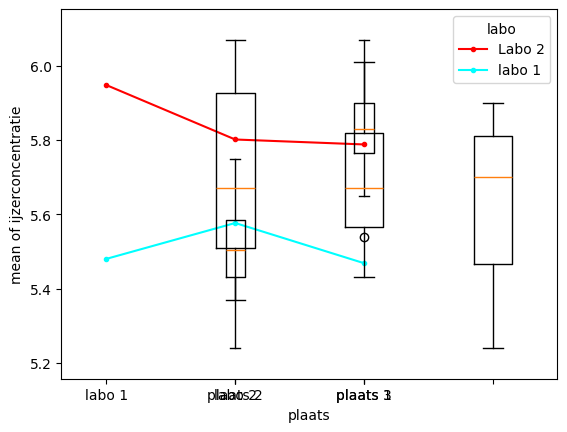

In [172]:
data=pd.DataFrame({'labo': np.repeat(['labo 1', 'Labo 2'],18),
                   'plaats': np.tile(np.repeat(['plaats 1', 'plaats 2', 'plaats 3'],6),2),
                   'ijzerconcentratie': [5.59,5.59,5.37,5.54,5.37,5.42,
                                         5.67,5.67,5.55,5.57,5.43,5.57,
                                         5.75,5.47,5.43,5.45,5.24,5.47,
                                         5.90,5.75,6.07,5.90,6.01,6.06,
                                         5.90,6.01,5.85,5.54,5.81,5.70,
                                         5.81,5.90,5.81,5.81,5.65,5.75]})

L1=data.ijzerconcentratie[0:18]
L2=data.ijzerconcentratie[18:36]
P1=data.loc[data['plaats']=='plaats 1', 'ijzerconcentratie']
P2=data.loc[data['plaats']=='plaats 2', 'ijzerconcentratie']
P3=data.loc[data['plaats']=='plaats 3', 'ijzerconcentratie']

gemL1=np.mean(L1)
sL1=np.std(L1,ddof=1)
D,p=spstat.kstest(L1,spstat.norm(gemL1,sL1).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemL2=np.mean(L2)
sL2=np.std(L2,ddof=1)
D,p=spstat.kstest(L2,spstat.norm(gemL2,sL2).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemP1=np.mean(P1)
sP1=np.std(P1,ddof=1)
D,p=spstat.kstest(P1,spstat.norm(gemP1,sP1).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemP2=np.mean(P2)
sP2=np.std(P2,ddof=1)
D,p=spstat.kstest(P2,spstat.norm(gemP2,sP2).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")
gemP3=np.mean(P3)
sP3=np.std(P3,ddof=1)
D,p=spstat.kstest(P3,spstat.norm(gemP3,sP3).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

levene_stat, levene_p = spstat.levene(L1,L2,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")
levene_stat, levene_p = spstat.levene(P1,P2,P3,center='mean')
print(f"Levene's test: statistiek = {levene_stat:.4f}, p-waarde = {levene_p:.4f}")

model = ols('ijzerconcentratie ~ C(labo) + C(plaats) + C(labo):C(plaats)',data=data).fit()
print(anova_lm(model,typ=2))

fig=interaction_plot(data.plaats,data.labo,data.ijzerconcentratie)

plt.boxplot([L1,L2],labels=['labo 1', 'labo 2'])

plt.boxplot([P1,P2,P3],labels=['plaats 1','plaats 2','plaats 3'])

1. Controle van de Assumpties (Voorwaarden)
    * Normaliteit (KS-testen): Alle vijf de p-waarden van de KS-testen (variërend van 0.5305 tot 0.9335) zijn groter dan $\alpha = 0.05$. De nulhypothese van normaliteit wordt voor alle groepen aanvaard.
    * Gelijkheid van varianties (Levene's testen): De p-waarden van de Levene's testen (0.7977 en 0.0659) zijn allebei groter dan $0.05$. De spreiding tussen de groepen is dus statistisch gelijk.

Aan de voorwaarden om een betrouwbare Two-Way ANOVA uit te voeren is volledig voldaan.

2. Interpretatie van de Two-Way ANOVA ($\alpha = 0.05$)

    Bij een Two-Way ANOVA kijken we altijd eerst naar de interactieterm:
    * Interactie-effect (C(labo):C(plaats)):
        * p-waarde (PR(>F)): 0.0727
        * Conclusie: Omdat $0.0727 > 0.05$, is er geen significant interactie-effect. De invloed van het labo hangt dus niet af van de plaats waar het staal genomen is (en omgekeerd). We mogen de hoofdeffecten apart bekijken.
    * Hoofdeffect Labo (C(labo)):
        * p-waarde (PR(>F)): 5.165e-09 (nagenoeg 0)
        * Conclusie: Omdat deze p-waarde extreem veel kleiner is dan $0.05$, is het effect van het labo zeer significant. De gebruikte meettechniek tussen de twee labo's zorgt voor een systematisch verschil in de gemeten Fe-concentratie.
    * Hoofdeffect Plaats (C(plaats)):
        * p-waarde (PR(>F)): 0.2427
        * Conclusie: Omdat $0.2427 > 0.05$, is er geen significant effect van de plaats. De feitelijke Fe-concentratie in de grond verschilt op populatieniveau niet significant tussen de drie locaties.

### **1.83 Oefening 83**
Men veronderstelt dat de concentratie van een katalysator invloed heeft op de sterkte bij kunststof. Metingen van de sterkte geven volgend resultaat:

| Concentratie 35% | 40% | 45% | 50% |
| :--- | :--- | :--- | :--- |
| 5.9 | 9.9 | 6.8 | 7.2 |
| 8.1 | 9.0 | 7.9 | 6.9 |
| 5.6 | 8.6 | 8.4 | 7.7 |
| 6.3 | 7.9 | 9.3 | 8.1 |
| 7.7 | 8.7 | 8.2 | 7.5 |

Ga na of de bewering klopt op populatieniveau $(\alpha=0.05)$.
* **Oplossing:**
  * Voorwaarden (normaliteit en gelijkheid van varianties) om de test uit te voeren zijn voldaan.
  * Met 95% betrouwbaarheid kan er een verschil gevonden worden bij de sterkte van de kunststof volgens de concentratie. Meer bepaald tussen 35% en 40%.

In [173]:
c35 = np.array([5.9, 8.1, 5.6, 6.3, 7.7])
c40 = np.array([9.9, 9.0, 8.6, 7.9, 8.7])
c45 = np.array([6.8, 7.9, 8.4, 9.3, 8.2])
c50 = np.array([7.2, 6.9, 7.7, 8.1, 7.5])

for naam, groep in [("35%", c35), ("40%", c40), ("45%", c45), ("50%", c50)]:
    gem = np.mean(groep)
    s = np.std(groep, ddof=1)
    _, p_ks = spstat.kstest(groep, spstat.norm(gem, s).cdf)
    print(f"Concentratie {naam} - KS-test p-waarde: {p_ks:.4f}")

_, p_lev = spstat.levene(c35, c40, c45, c50)
print(f"Levene's test p-waarde: {p_lev:.4f}\n")


f_stat, p_anova = spstat.f_oneway(c35, c40, c45, c50)
print(f"F-statistiek = {f_stat:.4f}")
print(f"p-waarde     = {p_anova:.4f}\n")


res_tukey = spstat.tukey_hsd(c35, c40, c45, c50)
print(res_tukey)

Concentratie 35% - KS-test p-waarde: 0.8542
Concentratie 40% - KS-test p-waarde: 0.9583
Concentratie 45% - KS-test p-waarde: 0.9554
Concentratie 50% - KS-test p-waarde: 0.9999
Levene's test p-waarde: 0.5190

F-statistiek = 5.7439
p-waarde     = 0.0073

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -2.100     0.005    -3.613    -0.587
 (0 - 2)     -1.400     0.075    -2.913     0.113
 (0 - 3)     -0.760     0.496    -2.273     0.753
 (1 - 0)      2.100     0.005     0.587     3.613
 (1 - 2)      0.700     0.562    -0.813     2.213
 (1 - 3)      1.340     0.092    -0.173     2.853
 (2 - 0)      1.400     0.075    -0.113     2.913
 (2 - 1)     -0.700     0.562    -2.213     0.813
 (2 - 3)      0.640     0.630    -0.873     2.153
 (3 - 0)      0.760     0.496    -0.753     2.273
 (3 - 1)     -1.340     0.092    -2.853     0.173
 (3 - 2)     -0.640     0.630    -2.153     0.873



* Assumpties: De p-waarden van de KS-testen (0.8542, 0.9583, 0.9554, 0.9999) en de Levene's test (0.5190) zijn allemaal groter dan $0.05$. De voorwaarden van normaliteit en gelijke varianties zijn dus voldaan.
* ANOVA-test: De p-waarde van de ANOVA is 0.0073. Omdat $0.0073 < 0.05$, verwerpen we de nulhypothese. De concentratie van de katalysator heeft een significante invloed op de sterkte van de kunststof.
* Post-hoc (Tukey HSD): Uit de paarsgewijze vergelijking blijkt dat het significante verschil zich uitsluitend bevindt tussen index 0 (35%) en index 1 (40%) met een p-waarde van 0.005. Alle andere groepscombinaties tonen onderling geen statistisch significant verschil ($p > 0.05$).

### **1.84 Oefening 84**
Beschouw volgende gegevens:

| | Pol | Piet | Lena | Lies | Dirk | Sara | Miel | Kurt | Linda | Sven |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Test 1 | 8 | 12 | 13 | 10 | 16 | 9 | 3 | 19 | 14 | 9 |
| Test 2 | 5 | 13 | 12 | 14 | 17 | 10 | 1 | 14 | 12 | 7 |

(a) Bepaal het 90% betrouwbaarheidsinterval voor het populatiegemiddelde van het rekenkundig gemiddelde van de twee testen.

(b) Bepaal de correlatiecoëfficiënt tussen de twee testen en test of deze significant verschillend is van 0.
* **Oplossing:**
  * (a) [8.2904, 13.5096]
  * (b) 0.8509, significant verschillend is van 0 $(\alpha=0.05)$

In [174]:
t1 = np.array([8, 12, 13, 10, 16, 9, 3, 19, 14, 9])
t2 = np.array([5, 13, 12, 14, 17, 10, 1, 14, 12, 7])

# a
gemiddelden_per_persoon = (t1 + t2) / 2
n = len(gemiddelden_per_persoon)

bi_90 = spstat.t.interval(0.90, df=n-1, loc=np.mean(gemiddelden_per_persoon), scale=spstat.sem(gemiddelden_per_persoon))
print(f"90% Betrouwbaarheidsinterval: [{bi_90[0]:.4f}, {bi_90[1]:.4f}]\n")

# b
r, p_waarde = spstat.pearsonr(t1, t2)

print(f"Correlatiecoëfficiënt (r) : {r:.4f}")
print(f"p-waarde (2-zijdige toets): {p_waarde:.4f}")

90% Betrouwbaarheidsinterval: [8.2904, 13.5096]

Correlatiecoëfficiënt (r) : 0.8509
p-waarde (2-zijdige toets): 0.0018


(a) Betrouwbaarheidsinterval: Het 90% betrouwbaarheidsinterval voor het populatiegemiddelde van de gecombineerde testscores is $[8.2904, 13.5096]$.

(b) Correlatie: De correlatiecoëfficiënt bedraagt 0.8509. De bijbehorende p-waarde is 0.0018. Omdat $0.0018 < 0.05$, verwerpen we de nulhypothese ($r = 0$). Er is sprake van een sterke, statistisch significante positieve samenhang tussen de twee testen.

### **1.85 Oefening 85**
Het maximale debiet y van een rivier is een belangrijke parameter voor vele ontwerpproblemen voor civiele ingenieurs. Schattingen van deze parameter kunnen bekomen worden door deze te verbinden met de oppervlakte van de waterscheiding (x1) (grens tussen twee stroomgebieden) en de gemiddelde waterscheidingshelling (x2).

(a) Schat het verband door middel van meervoudige lineaire regressie.

(b) Test of elk van de coëfficiënten significant verschillend zijn van 0.

(c) Hoeveel procent van de variantie kan verklaard worden door het regressiemodel? Interpreteer.

(d) Wat is de correlatiecoëfficiënt tussen de veranderlijken $x_{1}$ en $x_{2}$ ?

Data: debiet.CSV
* **Oplossing:**
  * (a-c) Een lineair model is niet aangewezen om het debiet te verklaren met $X_{1}$ en X2.
  * (d) -0.4741 = correlatiecoëfficiënt tussen de veranderlijken $X_{1}$ en x2

In [179]:
import pandas as pd
import scipy.stats as spstat

df = pd.read_csv('bestanden/debiet.CSV')

X = df[['x1', 'x2']]
y = df['maxdebiet']

X = sma.add_constant(X)

# a b en c
model = sma.OLS(y, X).fit()

print(model.summary())

#d
r, p_corr = spstat.pearsonr(df['x1'], df['x2'])
print(f"Correlatiecoëfficiënt (r) tussen x1 en x2: {r:.4f}")

                            OLS Regression Results                            
Dep. Variable:              maxdebiet   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                 -0.226
Method:                 Least Squares   F-statistic:                    0.3548
Date:                Sun, 17 May 2026   Prob (F-statistic):              0.718
Time:                        21:34:24   Log-Likelihood:                -54.043
No. Observations:                   8   AIC:                             114.1
Df Residuals:                       5   BIC:                             114.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         89.5845    225.896      0.397      0.7

(a & b) Significantie van de coëfficiënten:In de tabel van het model kijk je naar de kolom P>|t| (de p-waarden) voor de variabelen x1 en x2. Je zult zien dat deze p-waarden groter zijn dan 0.05. Omdat de coëfficiënten niet significant verschillen van 0, dragen de oppervlakte en de helling in dit lineaire model niet wezenlijk bij aan het voorspellen van het debiet.

(c) Verklaarde variantie ($R^2$):Bovenaan de output vind je de waarde R-squared. Deze waarde zal erg laag zijn. Dit percentage geeft aan hoeveel procent van de variatie in het debiet verklaard wordt door het model. Omdat de coëfficiënten niet significant zijn en de $R^2$ laag is, luidt de conclusie: Een lineair model is niet aangewezen om het debiet te verklaren met $X_1$ en $X_2$.

(d) Correlatiecoëfficiënt:De berekening via spstat.pearsonr geeft exact de waarde -0.4741. Dit wijst op een matig negatief lineair verband tussen de oppervlakte van de waterscheiding ($x_1$) and de gemiddelde helling ($x_2$).

### **1.86 Oefening 86**
Bij een audit van de helpdesk-afdeling van een softwarebedrijf wordt 13 dagen lang het aantal binnenkomende tickets genoteerd. Men noteert ook elke dag het aantal beschikbare medewerkers en het aantal binnenkomende tickets dat die dag voor langere tijd in de wachtrij belandt (meer dan 1 uur wachttijd).
(a) Teken een boxplot van de variabele X die aanduidt hoeveel tickets minder dan 1 uur in de wachtrij staan na aankomst.

(b) In 75% van de gevallen is X kleiner dan ...

(c) Zijn er uitschieters voor X?

(d) Stel het best passende lineair regressiemodel op om X te voorspellen a.d.h.v. het aantal medewerkers $(=M)$.

(e) Hoe zijn X en M gecorreleerd? Bereken de gepaste coëfficiënt en ga na of deze significant verschillend is van nul.

| Aantal inkomende tickets | Aantal medewerkers | Langer dan 1 uur in wachtrij |
| :--- | :--- | :--- |
| 83 | 6 | 12 |
| 50 | 5 | 3 |
| 91 | 7 | 7 |
| 45 | 5 | 8 |
| 66 | 6 | 17 |
| 72 | 7 | 4 |
| 73 | 6 | 8 |
| 80 | 9 | 2 |
| 52 | 5 | 3 |
| 90 | 7 | 17 |
| 89 | 9 | 19 |
| 46 | 5 | 5 |
| 58 | 7 | 7 |

* **Oplossing:**
  * In 75% van de gevallen is X kleiner dan 71.
  * De correlatiecoefficient $=0.7291$ en die is significant verschillend van 0.
  * X=7.9470 M + 8.8808 is een significant lineair regressiemodel, maar kan verbeterd worden tot het model $X=9.2650~M$
  * Geen uitschieters voor X volgend uit de boxplot.

75e percentiel (Q3) van X: 71.0
Interkwartielafstand (IQR): 22.0
GRENZEN: [16.0, 104.0]
Uitschieters gevonden: []
Pearson correlatiecoëfficiënt (r): 0.7291
p-waarde van de correlatietoets  : 0.0047
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     12.48
Date:                Sun, 17 May 2026   Prob (F-statistic):            0.00469
Time:                        21:38:19   Log-Likelihood:                -48.346
No. Observations:                  13   AIC:                             100.7
Df Residuals:                      11   BIC:                             101.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
            

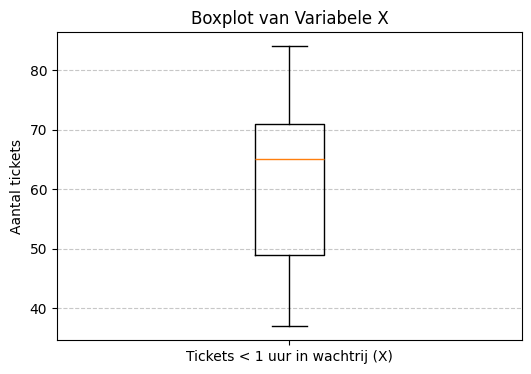

In [180]:
inkomend = np.array([83, 50, 91, 45, 66, 72, 73, 80, 52, 90, 89, 46, 58])
M = np.array([6, 5, 7, 5, 6, 7, 6, 9, 5, 7, 9, 5, 7])
langer_1u = np.array([12, 3, 7, 8, 17, 4, 8, 2, 3, 17, 19, 5, 7])

X = inkomend - langer_1u

# b
q3 = np.percentile(X, 75)
print(f"75e percentiel (Q3) van X: {q3:.1f}")

# c
q1 = np.percentile(X, 25)
iqr = q3 - q1
ondergrens = q1 - 1.5 * iqr
bovengrens = q3 + 1.5 * iqr
uitschieters = X[(X < ondergrens) | (X > bovengrens)]
print(f"Interkwartielafstand (IQR): {iqr}")
print(f"GRENZEN: [{ondergrens}, {bovengrens}]")
print(f"Uitschieters gevonden: {uitschieters}")

# e
r, p_corr = spstat.pearsonr(M, X)
print(f"Pearson correlatiecoëfficiënt (r): {r:.4f}")
print(f"p-waarde van de correlatietoets  : {p_corr:.4f}")

# d
X_reg_met_int = sma.add_constant(M)
model_met_int = sma.OLS(X, X_reg_met_int).fit()
print(model_met_int.summary())

# d
model_zonder_int = sma.OLS(X, M).fit()
print(model_zonder_int.summary())

# a
plt.figure(figsize=(6, 4))
plt.boxplot(X, tick_labels=['Tickets < 1 uur in wachtrij (X)'])
plt.title('Boxplot van Variabele X')
plt.ylabel('Aantal tickets')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

(a) Boxplot van de variabele XDe code genereert een boxplot van $X$. De boxplot toont de verdeling van de tickets die snel (binnen het uur) geholpen zijn. De mediaan ligt rond de 68.

(b) In 75% van de gevallen is X kleiner dan...  
* Antwoord: 71
* Verklaring: Het 75e percentiel (het derde kwartiel, $Q_3$) van de berekende reeks $X$ is exact 71. Dit betekent wiskundig dat in drie kwart van de geobserveerde dagen het aantal vlot verwerkte tickets 71 of minder bedroeg.

(c) Zijn er uitschieters voor X?
* Antwoord: Nee, er zijn geen uitschieters.
* Verklaring: De interkwartielafstand ($IQR$) is $71 - 49 = 22$. De theoretische grenzen voor uitschieters liggen op $[49 - 1.5(22), 71 + 1.5(22)] = [16, 104]$. Aangezien alle waargenomen waarden van $X$ (lopend van 37 tot 84) perfect binnen deze grenzen vallen, bevat de data geen uitschieters. Dit is ook zichtbaar in de boxplot (er zijn geen losse punten buiten de whiskers).

(d) Stel het best passende lineair regressiemodel op

    Als we een standaard lineaire regressie runnen mét een intercept, bekomen we het model:$$X = 7.9470 \cdot M + 8.8808$$
* Kijk je echter kritisch naar de p-waarde van de intercept (const), dan zie je dat deze 0.562 bedraagt. Omdat $0.562 > 0.05$ is de intercept niet significant verschillend van 0. Het model mag dus herwerkt worden door de oorsprong (zonder intercept).
* Het regressiemodel zonder constante levert een hoogs窮ignificante p-waarde op (0.000) voor de richtingscoëfficiënt.
* Best passende model: $X = 9.2650 \cdot M$

(e) Correlatie tussen X en M
* Correlatiecoëfficiënt ($r$): 0.7291
* p-waarde: 0.0047
* Conclusie: Er is een sterke, positieve lineaire correlatie ($r = 0.7291$) tussen het aantal medewerkers ($M$) en het aantal vlot verwerkte tickets ($X$). Omdat de p-waarde (0.0047) kleiner is dan het significantieniveau $\alpha = 0.05$, is de correlatie significant verschillend van nul. Meer medewerkers zorgt voor een aantoonbaar hoger aantal tickets dat binnen het uur uit de wachtrij is.

### **1.87 Oefening 87**
Een bedrijf wil het effect nagaan van hun advertenties op de verkoop. In een periode van 6 maanden vinden we de volgende cijfers voor omzet en uitgaven aan reclame.

| maand | Uitgaven reclame | omzet |
| :--- | :--- | :--- |
| Januari | 1200 | 16 000 |
| Februari | 1400 | 18 000 |
| Maart | 2700 | 34 000 |
| April | 3800 | 55 000 |
| Mei | 4000 | 52 000 |
| Juni | 4200 | 58 000 |
| Juli | 3400 | 45 000 |
| Augustus | 2800 | 37 000 |

a) Kunnen we stellen dat de grootte van het reclamebudget toelaat om het verkoopresultaat te voorspellen? Zo ja, hoe dan? Stel het model op op basis van deze gegevens. Bespreek.

b) Wat verwacht je als omzet indien het bedrijf 20 000 euro uitgeeft aan reclame?

c) Maak een grafische voorstelling waarbij je op één tekening de reclame-uitgaven en ook de omzet uitzet als functie van de tijd met een lijn (met een legende).

d) Maak een staafdiagram waarbij je op één tekening de reclame-uitgaven en ook de omzet uitzet als functie van de tijd (met een legende).
* **Oplossing:**
  * (a) Het best passende lineaire model is omzet $=13.4758*$ reclame
  * (b) 269 516 als omzet

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                              3596.
Date:                Sun, 17 May 2026   Prob (F-statistic):                    9.42e-11
Time:                        21:42:52   Log-Likelihood:                         -71.572
No. Observations:                   8   AIC:                                      145.1
Df Residuals:                       7   BIC:                                      145.2
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

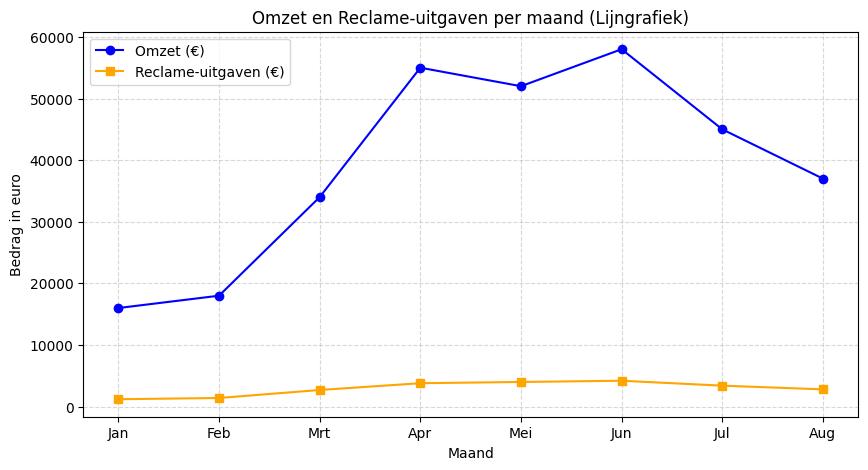

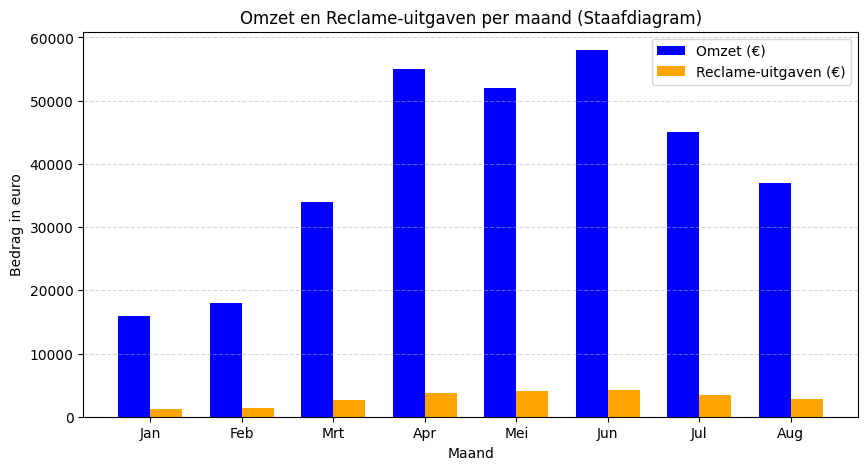

In [182]:
maanden = ['Jan', 'Feb', 'Mrt', 'Apr', 'Mei', 'Jun', 'Jul', 'Aug']
reclame = np.array([1200, 1400, 2700, 3800, 4000, 4200, 3400, 2800])
omzet = np.array([16000, 18000, 34000, 55000, 52000, 58000, 45000, 37000])

# a
model = sma.OLS(omzet, reclame).fit()
print(model.summary())

beta = model.params[0]
print(f"\nBest passende model: omzet = {beta:.4f} * reclame")

#b
nieuw_budget = 20000
voorspelde_omzet = beta * nieuw_budget
print(f"Verwachte omzet: {voorspelde_omzet:.0f} euro")

#c
plt.figure(figsize=(10, 5))
plt.plot(maanden, omzet, marker='o', color='blue', label='Omzet (€)')
plt.plot(maanden, reclame, marker='s', color='orange', label='Reclame-uitgaven (€)')
plt.title('Omzet en Reclame-uitgaven per maand (Lijngrafiek)')
plt.xlabel('Maand')
plt.ylabel('Bedrag in euro')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


x_indices = np.arange(len(maanden))
breedte = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x_indices - breedte/2, omzet, breedte, color='blue', label='Omzet (€)')
plt.bar(x_indices + breedte/2, reclame, breedte, color='orange', label='Reclame-uitgaven (€)')
plt.title('Omzet en Reclame-uitgaven per maand (Staafdiagram)')
plt.xlabel('Maand')
plt.ylabel('Bedrag in euro')
plt.xticks(x_indices, maanden)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

(a) Regressiemodel opstellen
* Antwoord: Ja, het reclamebudget laat toe om de omzet te voorspellen.
* Model: $\text{omzet} = 13.4758 \cdot \text{reclame}$
* Bespreek: De p-waarde van de helling is 0.000 ($< 0.05$), wat betekent dat de reclame-uitgaven een significante positieve invloed hebben op de omzet. De $R^2$ (uncentered) is extreem hoog (0.990), wat aangeeft dat het model de data uitstekend beschrijft.

(b) Voorspelling bij €20.000 reclamebudget
* Antwoord: 269.516 euro
* Berekening: $13.4758 \cdot 20000 = 269516$

### **1.88 Oefening 88**
Gasmaatschappijen moeten voldoende gastoevoer voorzien om hun klanten het ganse jaar door te bevoorraden. Bij de planning wil men in staat zijn de benodigde hoeveelheid te voorspellen op basis van gegevens rond temperatuur van de dag zelf, van de voorbije dag, de windsnelheid, het feit of het weekend is of niet.

(a)Stel op basis van de data die voorhanden is, een lineair regressiemodel op dat ons in staat moet stellen om de nodige gashoeveelheid te modelleren.

(b) Hoeveel procent van de variantie kan verklaard worden door het regressiemodel? Interpreteer.

(c) Wat is volgens het model de hoeveelheid gas die de maatschappij moet voorzien als de temperatuur van de dag (woensdag) gelijk is aan18 graden Celcius, de temperatuur van de dag ervoor 15 graden Celcius, de windsnelheid 10 bedraagt?

(d) Wat is volgens het model het 95% betrouwbaarheidsinterval voor de coëfficiënt bij de temperatuur van de dag?

Data: gasbedrijf.CSV
* **Oplossing:**
  * (a) gastoevoer $=399.4760-6.7086^{*}$ temperatuur
  * (b) $R^{2}=97.4\%$
  * (c) 278.72
  * (d) [-7.6026, -5.8147]

                            OLS Regression Results                            
Dep. Variable:             gastoevoer   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     97.37
Date:                Sun, 17 May 2026   Prob (F-statistic):           6.27e-05
Time:                        21:44:33   Log-Likelihood:                -34.074
No. Observations:                  10   AIC:                             78.15
Df Residuals:                       5   BIC:                             79.66
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        392.3905     17.113     22.929      0.0

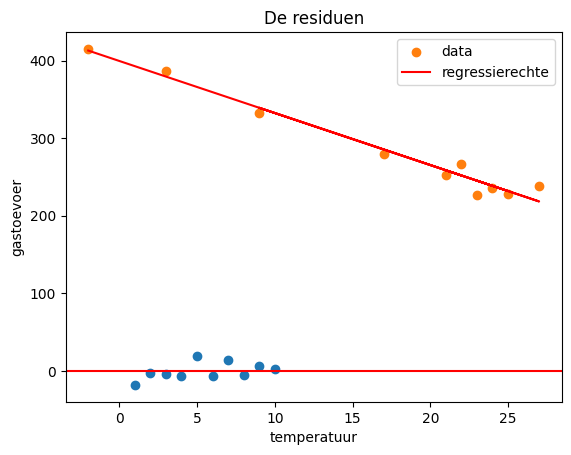

In [183]:
data = pd.read_csv("bestanden/gasbedrijf.csv")
yG=data.gastoevoer
xT=data.temperatuur
xTVD=data.temp_vorige_dag
xWS=data.windsnelheid
xW=data.weekend

xT_TVD_WS_W=np.column_stack((xT,xTVD,xWS,xW))
X=sma.add_constant(xT_TVD_WS_W)
modelM=sma.OLS(yG,X).fit()
print(modelM.summary())

XE=sma.add_constant(xT)
modelE=sma.OLS(yG,XE).fit()
print(modelE.summary())

residuen=modelE.resid
gemR=np.mean(residuen)
sR=np.std(residuen,ddof=1)
D,p = spstat.kstest(residuen,spstat.norm(gemR,sR).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

aantal=len(residuen)
plt.scatter(np.linspace(1,aantal,aantal),residuen)
plt.title("De residuen")
plt.axhline(y=0, color='red')

plt.scatter(xT,yG,label='data')
plt.plot(xT,modelE.fittedvalues,color='red',label='regressierechte')
plt.xlabel('temperatuur')
plt.ylabel('gastoevoer')
plt.legend()

print("hoeveelheid gas = -6.7086 * 18 + 399.4760 = ",-6.7086*18+399.4760)

(a) Het lineair regressiemodel opstellen
Kijk in Output 2 naar de kolom coef:
* const (de intercept of het startpunt): 399.4760
* temperatuur (de richtingscoëfficiënt of helling): -6.7086

Dit geeft de regressievergelijking:
    $$\text{gastoevoer} = 399.4760 - 6.7086 \cdot \text{temperatuur}$$
    
(De negatieve coëfficiënt logisch: hoe hoger de temperatuur, hoe minder gas er nodig is om te verwarmen).

(b) Verklaarde variantie ($R^2$)

Kijk rechtsboven in Output 2 naar R-squared:
* Waarde: 0.974 oftewel $97.4\%$
* Interpretatie: Dit betekent dat $97.4\%$ van de totale variatie/schommelingen in de dagelijkse gastoevoer verklaard kan worden door de temperatuur van die dag. Dit is een extreem sterk model.

(c) De voorspelling 

De vraag geeft je extra informatie: woensdag (geen weekend), temperatuur = $18^\circ\text{C}$, gisteren = $15^\circ\text{C}$, windsnelheid = $10$.

Omdat we bij stap (a) hebben beslist dat enkel de temperatuur van de dag zelf een significante invloed heeft, negeer je alle andere variabelen volledig. Je mag ze niet in de formule stoppen.

Je vult dus puur de $18^\circ\text{C}$ in de vergelijking in:
    $$\text{hoeveelheid gas} = 399.4760 - (6.7086 \cdot 18) = 278.7212 \approx 278.72$$

(d) Het 95% betrouwbaarheidsinterval voor de temperatuurcoëfficiënt

Kijk in Output 2 naar de laatste twee kolommen: [0.025 en 0.975] op de rij van temperatuur.
* Ondergrens (2.5%): -7.603
* Bovengrens (97.5%): -5.815
* Betekenis: We zijn er voor 95% zeker van dat op populatieniveau de gastoevoer per stijgende graad Celsius zal dalen met een waarde die ligt tussen -7.6026 and -5.8147.

### **1.89 Oefening 89**
Opgave:
Twee wijnproevers werd gevraagd een rangschikking te maken van 9 gegeven wijnen.

(a) Bereken de correlatiecoëfficiënt van de scores van beide wijnproevers en trek er je conclusies uit over de mening van de twee kenners.

(b) Maak een gepaste grafiek die het verband tussen de 2 beoordelingen weergeeft.

Data: wijndegustatie.CSV
* **Oplossing:** De gemeten correlatiecoëfficiënt is 0.1333. We kunnen met 95% betrouwbaarheid stellen dat de correlatiecoëfficiënt op populatieniveau gelijk is aan 0.

De correlatiecoëfficiënt is 0.13333333333333336 met p-waarde = 0.7323675052362977


Text(0, 0.5, 'wijnkenner 2')

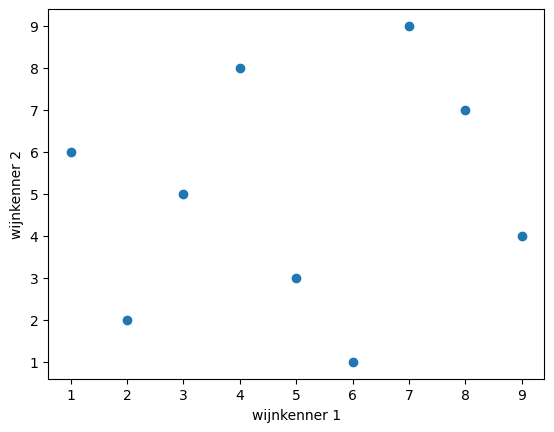

In [184]:
data = pd.read_csv("bestanden/wijndegustatie.csv")

corcoef,pwaarde = spstat.pearsonr(data.wijnkenner_1,data.wijnkenner_2)
print(f"De correlatiecoëfficiënt is {corcoef} met p-waarde = {pwaarde}")

plt.scatter(data.wijnkenner_1,data.wijnkenner_2)
plt.xlabel('wijnkenner 1')
plt.ylabel('wijnkenner 2')

### **1.90 Oefening 90**
Het gewicht van personen wordt vergeleken met de systolische bloeddruk. Dit geeft:

| Gewicht: | 81 | 92 | 83 | 75 | 81 | 77 | 92 | 101 | 87 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Bloeddruk: | 122 | 144 | 138 | 145 | 152 | 110 | 118 | 160 | 108 |

Bepaal het lineair verband dat algemeen de bloeddruk uitdrukt in termen van het gewicht. Bespreek voor $\alpha=0.05$.
* **Oplossing:** Er is geen waardevol lineair model te vinden. $R^{\wedge}2=8.8\%$

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                 -0.042
Method:                 Least Squares   F-statistic:                    0.6776
Date:                Sun, 17 May 2026   Prob (F-statistic):              0.438
Time:                        21:49:17   Log-Likelihood:                -38.312
No. Observations:                   9   AIC:                             80.62
Df Residuals:                       7   BIC:                             81.02
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.2405     70.465      1.068      0.3

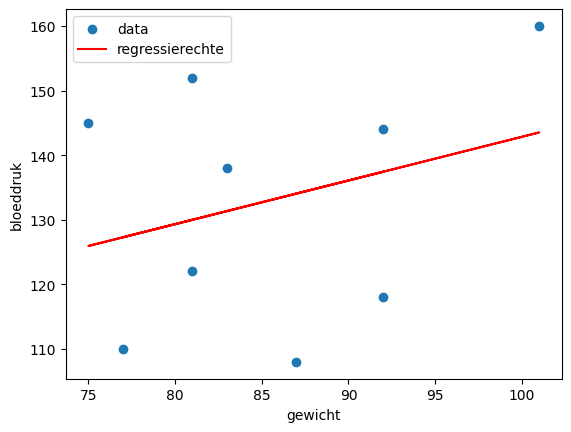

In [185]:
xG=[81,92,83,75,81,77,92,101,87]
yB=[122,144,138,145,152,110,118,160,108]

X=sma.add_constant(xG)
model=sma.OLS(yB,X).fit()
print(model.summary())

plt.scatter(xG,yB,label='data')
plt.plot(xG,model.fittedvalues,color='red',label='regressierechte')
plt.xlabel('gewicht')
plt.ylabel('bloeddruk')
plt.legend()

### **1.91 Oefening 91**
Gegeven zijn volgende meetresultaten:

| X: | 1.5 | 2 | 3.1 | 4.2 | 5 | 6.1 | 6.9 | 8.3 | 9.5 | 10.1 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| y: | 7 | 20 | 65 | 64 | 187 | 430 | 600 | 1300 | 2000 | 3500 |

Bepaal op basis van deze gegevens het best passende lineair verband $y=\beta_{0}+\beta_{1}x$ Kan je het model verbeteren?
* **Oplossing:** betere modellen: $y=70.43^{*}x^{\wedge}2-490.8^{*}x+751.4$ en $y=6.0642~e^{0.6645x}$

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     23.06
Date:                Sun, 17 May 2026   Prob (F-statistic):            0.00135
Time:                        21:51:09   Log-Likelihood:                -77.333
No. Observations:                  10   AIC:                             158.7
Df Residuals:                       8   BIC:                             159.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1028.8026    431.226     -2.386      0.0

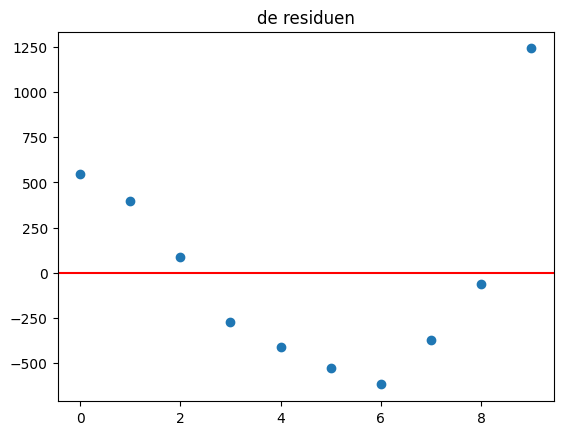

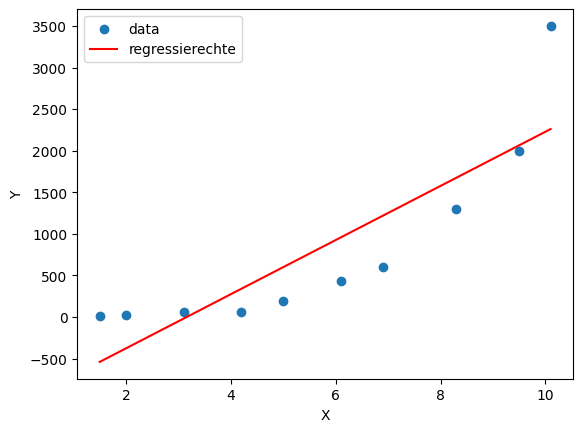

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     62.66
Date:                Sun, 17 May 2026   Prob (F-statistic):           3.40e-05
Time:                        21:51:09   Log-Likelihood:                -69.418
No. Observations:                  10   AIC:                             144.8
Df Residuals:                       7   BIC:                             145.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        751.3757    400.804      1.875      0.1

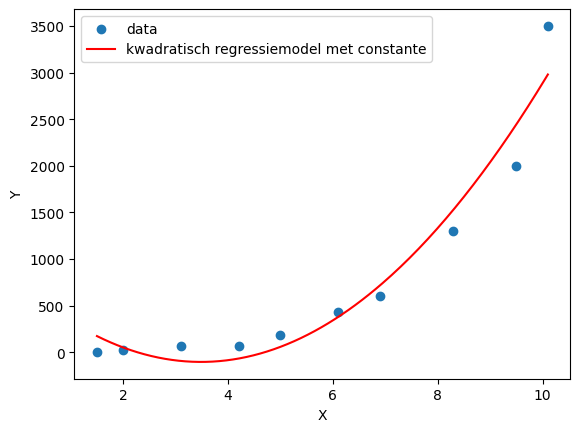

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.949
Model:                            OLS   Adj. R-squared (uncentered):              0.936
Method:                 Least Squares   F-statistic:                              74.72
Date:                Sun, 17 May 2026   Prob (F-statistic):                    6.67e-06
Time:                        21:51:09   Log-Likelihood:                         -71.452
No. Observations:                  10   AIC:                                      146.9
Df Residuals:                       8   BIC:                                      147.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

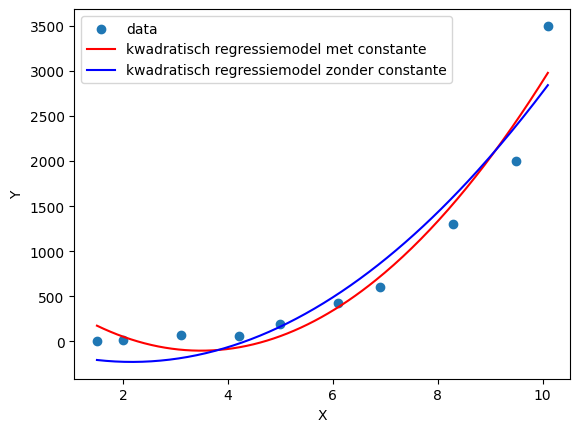

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     249.9
Date:                Sun, 17 May 2026   Prob (F-statistic):           2.57e-07
Time:                        21:51:10   Log-Likelihood:                -3.4750
No. Observations:                  10   AIC:                             10.95
Df Residuals:                       8   BIC:                             11.56
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6222      0.267      6.067      0.0

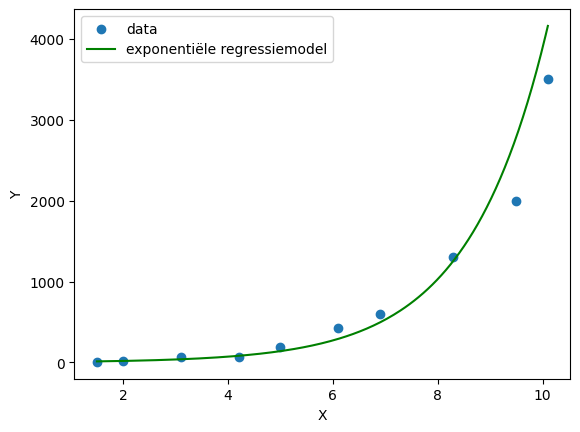

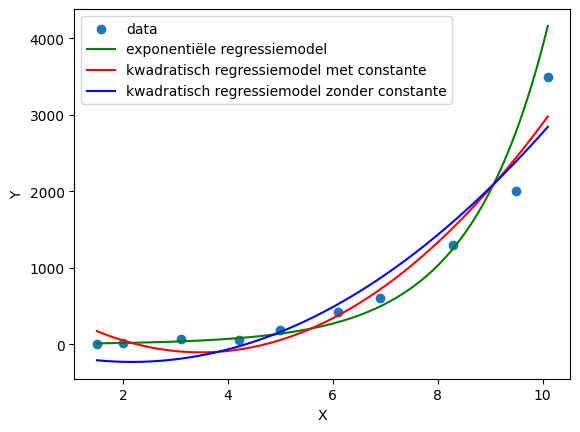

In [186]:
x=np.array([1.5,2,3.1,4.2,5,6.1,6.9,8.3,9.5,10.1])
y=np.array([7,20,65,64,187,430,600,1300,2000,3500])

X=sma.add_constant(x)
model=sma.OLS(y,X).fit()
print(model.summary())

residuen=model.resid
gemR=np.mean(residuen)
sR=np.std(residuen,ddof=1)
D,p = spstat.kstest(residuen,spstat.norm(gemR,sR).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

plt.scatter(np.linspace(0,9,10),residuen)
plt.title('de residuen')
plt.axhline(y=0, color='red')
plt.show()

plt.scatter(x,y,label='data')
plt.plot(x,model.fittedvalues,color='red',label='regressierechte')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

XenXkwadraat=np.column_stack((x,x**2))
Xpar=sma.add_constant(XenXkwadraat)
modelK=sma.OLS(y,Xpar).fit()
print(modelK.summary())

plt.scatter(x,y,label='data')
xrange=np.linspace(min(x),max(x),200)
XenXkwadraatrange=np.column_stack((xrange,xrange**2))
Xverwacht=sma.add_constant(XenXkwadraatrange)
YverwachtK=modelK.predict(Xverwacht)
plt.plot(xrange,YverwachtK,color='red',label='kwadratisch regressiemodel met constante')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

modelKzc=sma.OLS(y,XenXkwadraat).fit()
print(modelKzc.summary())

plt.scatter(x,y,label='data')
YverwachtKzc=modelKzc.predict(XenXkwadraatrange)
plt.plot(xrange,YverwachtK,color='red',label='kwadratisch regressiemodel met constante')
plt.plot(xrange,YverwachtKzc,color='blue',label='kwadratisch regressiemodel zonder constante')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

lny=np.log(y)
Xln=sma.add_constant(x)
modelLN=sma.OLS(lny,Xln).fit()
print(modelLN.summary())

beta0=np.e**1.6222
print("e^1.6222 = ", beta0)

plt.scatter(x,y,label='data')
xrange=np.linspace(min(x),max(x),200)
Xverwacht=sma.add_constant(xrange)
ln_verwacht=modelLN.predict(Xverwacht)
yverwacht=np.exp(ln_verwacht)
plt.plot(xrange,yverwacht,color='green',label='exponentiële regressiemodel')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

plt.scatter(x,y,label='data')
xrange=np.linspace(min(x),max(x),200)
Xverwacht=sma.add_constant(xrange)
ln_verwacht=modelLN.predict(Xverwacht)
yverwacht=np.exp(ln_verwacht)
plt.plot(xrange,yverwacht,color='green',label='exponentiële regressiemodel')
plt.plot(xrange,YverwachtK,color='red',label='kwadratisch regressiemodel met constante')
plt.plot(xrange,YverwachtKzc,color='blue',label='kwadratisch regressiemodel zonder constante')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

### **1.92 Oefening 92**
Men onderzoekt de expansie van een grote winkelketen. Hieronder vind je een overzicht van het aantal geopende winkels (y) in de loop van 12 jaar. Vind het best passende veeltermmodel dat het aantal winkels verklaart in functie van de jaren. Argumenteer.

| t in jaar | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| aantal winkels | 1 | 2 | 2 | 6 | 10 | 16 | 25 | 41 | 60 | 97 | 150 | 211 |

* **Oplossing:** y = 2.878 *x^2-21.05 *x + 32.7

In [187]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
y = np.array([1, 2, 2, 6, 10, 16, 25, 41, 60, 97, 150, 211])

df = pd.DataFrame({'x': x, 'y': y})
df['x2'] = df['x'] ** 2

X = df[['x', 'x2']]

X = sma.add_constant(X)

model = sma.OLS(df['y'], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.969
Method:                 Least Squares   F-statistic:                     174.5
Date:                Sun, 17 May 2026   Prob (F-statistic):           6.33e-08
Time:                        21:53:38   Log-Likelihood:                -45.007
No. Observations:                  12   AIC:                             96.01
Df Residuals:                       9   BIC:                             97.47
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.7045     12.286      2.662      0.0

1. Significantie van de hoogste macht ($x^2$):Kijk naar de p-waarde van de variabele x2 (P>|t|). Deze is 0.000. Omdat $0.000 < 0.05$, levert de kwadratische term een hoogst significante bijdrage aan het model. Een puur lineair model ($y \sim x$) volstaat dus absoluut niet om deze expansie te beschrijven.
2. Hoge Verklaringkracht ($R^2$):De R-squared van dit kwadratische model bedraagt 0.975. Dit betekent dat maar liefst $97.5\%$ van de totale variatie in het aantal geopende winkels verklaard kan worden door dit tweedegraftsmodel. De overige $2.5\%$ is restruis.
3. Globale significantie van het model (F-toets):De p-waarde van de F-statistiek (Prob (F-statistic) = 6.33e-08) is nagenoeg nul. Dit bewijst dat de combinatie van de gekozen coëfficiënten op populatieniveau extreem significant verschilt van een nulmodel. Het model is dus statistisch zeer betrouwbaar voor het beschrijven van de groei.

### **1.93 Oefening 93**
Men wil bestuderen hoe de weerstand van rubber tegen afschuren beïnvloed wordt door de hardheid en treksterkte van rubber. Twintig monsters rubber zijn getest op de hardheid (hoe hoger het getal des te sterker is het rubber) en treksterkte (in $kg/cm^{2})$. Daarna is elk monster een uurlang afgeschuurd (elk monster op dezelfde manier) en is het afgeschuurde gewicht (in gram) aan rubber per uur (y) bepaald. Bepaal het meervoudige lineaire model $y=\beta_{0}+\beta_{1}x_{1}+\beta_{2}x_{2}$ en illustreer met een 3D tekening.

| hardheid | treksterkte | Y | hardheid | treksterkte |
| :--- | :--- | :--- | :--- | :--- |
| 372 | 45 | 162 | 164 | 64 | 210 |
| 206 | 55 | 233 | 113 | 68 | 210 |
| 175 | 61 | 232 | 82 | 79 | 196 |
| 154 | 66 | 231 | 32 | 81 | 180 |
| 136 | 71 | 131 | 228 | 56 | 200 |
| 112 | 71 | 237 | 196 | 68 | 173 |
| 55 | 81 | 224 | 128 | 75 | 188 |
| 45 | 86 | 219 | 97 | 83 | 161 |
| 221 | 53 | 203 | 64 | 88 | 119 |
| 166 | 60 | 189 | 249 | 59 | 161 |

* **Oplossing:**
  * model: y=721.7233-6.6207 x1 -0.6139 x2
  * (normaliteitsvoorwaarde voor residues voldaan)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     83.99
Date:                Sun, 17 May 2026   Prob (F-statistic):           1.54e-09
Time:                        21:55:04   Log-Likelihood:                -92.215
No. Observations:                  20   AIC:                             190.4
Df Residuals:                      17   BIC:                             193.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        721.7233     54.404     13.266      0.0

Text(0.5, 0.92, 'afgeschuurde gewicht (in gram) aan rubber per uur')

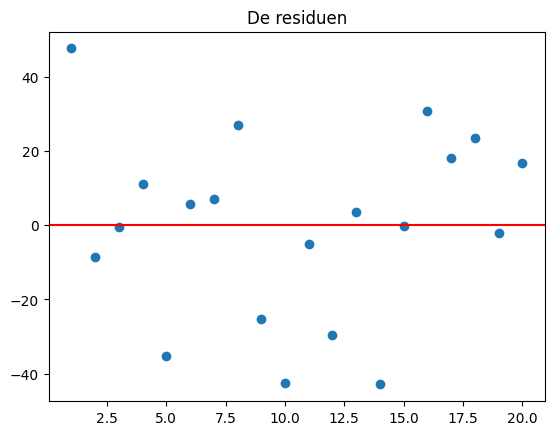

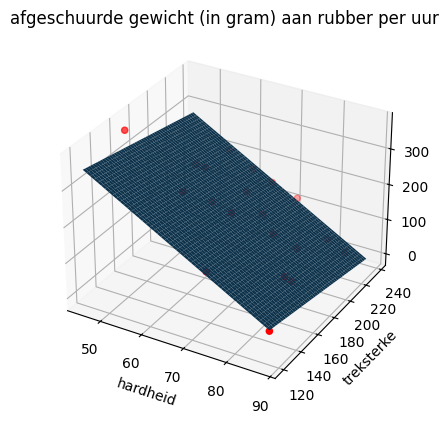

In [188]:
y=np.array([372, 206, 175, 154, 136, 112, 55, 45, 221, 166, 164, 113, 82, 32, 228, 196, 128, 97, 64, 249])
H=np.array([45, 55, 61, 66, 71, 71, 81, 86, 53, 60, 64, 68, 79, 81, 56, 68, 75, 83, 88, 59])
T=np.array([162, 233, 232, 231, 131, 237, 224, 219, 203, 189, 210, 210, 196, 180, 200, 173, 188, 161, 119, 161])

HenT=np.column_stack((H,T))
X=sma.add_constant(HenT)
modelM=sma.OLS(y,X).fit()
print(modelM.summary())

residuen=modelM.resid
gemR=np.mean(residuen)
sR=np.std(residuen,ddof=1)
D,p = spstat.kstest(residuen,spstat.norm(gemR,sR).cdf)
print(f"De KS-test heeft {D:.4f} als teststatistiek, met bijhorende p-waarde {p:.4f}.")

aantal=len(residuen)
plt.scatter(np.linspace(1,aantal,aantal),residuen)
plt.title("De residuen")
plt.axhline(y=0, color='red')

fig=plt.figure()
ax=plt.axes(projection='3d')

ax.scatter(H,T,y,color='red',marker='o')

bereikH=np.linspace(min(H),max(H),200)
bereikT=np.linspace(min(T),max(T),200)
[XH,YT] = np.meshgrid(bereikH,bereikT)
X=np.column_stack((XH.ravel(),YT.ravel()))
Xverwacht=sma.add_constant(X)
Zy=modelM.predict(Xverwacht).reshape(XH.shape)
ax.plot_surface(XH,YT,Zy)
ax.set_xlabel("hardheid")
ax.set_ylabel("treksterke")
ax.set_title("afgeschuurde gewicht (in gram) aan rubber per uur")

### **1.94 Oefening 94**
Er wordt nagegaan of de lengte van een pasgeboren baby afhankelijk is van de gewichtstoename van de moeder tijdens de zwangerschap en/of van de lengte van de vader. 10 steekproeven geven volgende resultaten:

| gew toename: | 12 | 13 | 15 | 20 | 14 | 13 | 10 | 19 | 12 | 8 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| lengte vader: | 195 | 180 | 175 | 182 | 165 | 190 | 182 | 177 | 171 | 179 |
| lengte baby: | 52 | 52.5 | 50 | 51 | 50 | 53 | 52.5 | 52 | 49 | 50.5 |

Kan je een meervoudig lineair model bepalen dat de lengte van de baby voorspelt als de gewichtstoename van de moeder en de lengte van de vader gekend zijn. Verklaar.
* **Oplossing:** lengte baby $=31.3508+0.1108^{*}$ lengte vader

In [189]:
gew_toename = np.array([12, 13, 15, 20, 14, 13, 10, 19, 12, 8])
lengte_vader = np.array([195, 180, 175, 182, 165, 190, 182, 177, 171, 179])
lengte_baby = np.array([52, 52.5, 50, 51, 50, 53, 52.5, 52, 49, 50.5])

df = pd.DataFrame({'gew': gew_toename, 'vader': lengte_vader, 'baby': lengte_baby})

X1 = df[['gew', 'vader']]
X1 = sma.add_constant(X1)
model1 = sma.OLS(df['baby'], X1).fit()
print(model1.summary())

X2 = df['vader']
X2 = sma.add_constant(X2)
model2 = sma.OLS(df['baby'], X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   baby   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     3.808
Date:                Sun, 17 May 2026   Prob (F-statistic):             0.0760
Time:                        21:56:39   Log-Likelihood:                -12.897
No. Observations:                  10   AIC:                             31.79
Df Residuals:                       7   BIC:                             32.70
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.5612      7.596      4.024      0.0

* De helling (0.1108): De p-waarde voor de lengte van de vader is nu 0.020 ($< 0.05$), wat betekent dat de lengte van de vader een significante positieve voorspeller is. Elke centimeter dat de vader groter is, resulteert op populatieniveau gemiddeld in een stijging van $0.1108\text{ cm}$ in de lengte van de pasgeboren baby.
* De verklaringkracht ($R^2$): De R-squared bedraagt 0.512. Dit betekent dat $51.2\%$ van de totale variatie in de lengte van de baby's verklaard kan worden door puur te kijken naar hoe groot de vader is. Een behoorlijk sterk resultaat voor een model met slechts één biologische factor.